# Objetivo Analítico del TP2

El objetivo de esta etapa es transformar una base de datos inmobiliaria cruda en una matriz analítica confiable y enriquecida, capaz de responder preguntas de negocio vinculadas al mercado inmobiliario.

A través de técnicas de limpieza, feature engineering, análisis exploratorio e inferencia estadística, se busca identificar patrones relevantes sobre:
- comportamiento de precios,
- diferencias entre modalidades de alquiler,
- impacto de amenities y ubicación,
- rentabilidad potencial,
- segmentación del mercado.

Los resultados obtenidos permitirán validar nuestras hipótesis iniciales y sentar las bases para modelos más complejos en las siguientes etapas del proyecto.

# 1. Importamos las librerías
Corremos esta celda si no tenemos las librerías instaladas.

In [215]:
# pip install requests geopandas matplotlib scipy

In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import requests
import re
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Cargamos el DataFrame

In [217]:
df_maestro = pd.read_csv('https://media.githubusercontent.com/media/clararodriguezacevedo/descriptiva-real-estate/refs/heads/main/data/raw/dataframe_maestro.tsv', sep='\t')
# df_maestro = pd.read_csv('../data/raw/dataframe_maestro.tsv', sep='\t')

Revisamos si se cargó bien.

In [218]:
df_maestro.head()

,Fecha_Scraping,Posting_ID,Sito,Operación,Precio,Expensas,Calle,Altura,Piso,Barrio,Detalles,Descripción,Link,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
0,2026-04-12,58757240,zonaprop,alquiler,$ 750.000,$ 300.000,Mansilla,"2,936",NaN,Barrio Norte,60 m² tot. 2 amb. 1 dorm. 1 baño,Amplio departamento de dos ambientes en el exc...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,0,0,1,0
1,2026-04-12,58818211,zonaprop,alquiler,$ 1.700.000,$ 400.000,Cespedes,"2,300",NaN,Belgrano,114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,"3 ambientes con balcón, y terraza con parrilla...",https://www.zonaprop.com.ar/propiedades/clasif...,1,0,0,0,1,0,0,0
2,2026-04-12,58564550,zonaprop,alquiler,USD 2.500,$ 1.150.000,Riobamba,"1,200",NaN,Recoleta,121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.,Departamento en alquiler de 4 ambientes con co...,https://www.zonaprop.com.ar/propiedades/clasif...,4,0,0,0,1,1,1,0
3,2026-04-12,58314210,zonaprop,alquiler,USD 1.300,NaN,Pereyra Lucena,"2,500",NaN,Palermo,66 m² tot. 2 amb. 1 dorm. 1 baño,Amoblado y Equipado. Ubicado a metros de Av. L...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,1,0,1,1
4,2026-04-12,58810878,zonaprop,alquiler,USD 3.800,NaN,Lola Mora,400,NaN,Puerto Madero,117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,Alquiler temporario de 3 ambientes amueblado e...,https://www.zonaprop.com.ar/propiedades/clasif...,3,0,0,0,1,1,0,0


In [219]:
df_maestro.shape

(66180, 21)

Hacemos una copia para no modificar el DataFrame original.

In [220]:
df = df_maestro.copy()

# 3. Análisis Inicial

## Variables Categóricas y Numéricas

In [221]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66180 entries, 0 to 66179
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha_Scraping     66180 non-null  str    
 1   Posting_ID         66180 non-null  int64  
 2   Sito               66180 non-null  str    
 3   Operación          66180 non-null  str    
 4   Precio             66180 non-null  str    
 5   Expensas           45549 non-null  str    
 6   Calle              60722 non-null  str    
 7   Altura             60722 non-null  float64
 8   Piso               15167 non-null  str    
 9   Barrio             66180 non-null  str    
 10  Detalles           65957 non-null  str    
 11  Descripción        65868 non-null  str    
 12  Link               66180 non-null  str    
 13  Amenities          66180 non-null  int64  
 14  Losa_Central       66180 non-null  int64  
 15  Aire_Acond         66180 non-null  int64  
 16  Apto_Credito       66180 non-null

Identificamos qué variables son numéricas y cuáles son categóricas, ya que cada grupo requiere un tratamiento distinto durante el análisis.

In [222]:
df.columns

Index(['Fecha_Scraping', 'Posting_ID', 'Sito', 'Operación', 'Precio',
       'Expensas', 'Calle', 'Altura', 'Piso', 'Barrio', 'Detalles',
       'Descripción', 'Link', 'Amenities', 'Losa_Central', 'Aire_Acond',
       'Apto_Credito', 'Cochera', 'Seguridad', 'Luminoso',
       'Balcon_Aterrazado'],
      dtype='str')

In [223]:
df.describe()

,Posting_ID,Altura,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
count,"66,180","60,722","66,180","66,180","66,180","66,180","66,180","66,180","66,180","66,180"
mean,"36,921,801","2,256",1,0,0,0,0,0,1,0
std,"20,086,954","1,714",2,0,0,0,0,0,0,0
min,"1,527,159",20,0,0,0,0,0,0,0,0
25%,"18,633,952",950,0,0,0,0,0,0,0,0
50%,"19,387,787","1,900",0,0,0,0,0,0,1,0
75%,"58,429,925","3,100",2,0,1,0,1,0,1,0
max,"58,828,376","54,300",8,1,1,1,1,1,1,1


## Normalizamos

Normalizamos los nombres de las columnas.

In [224]:
df = df.rename(columns={"Sito": "sitio","Operación": "operacion"})

In [225]:
df.columns = (df.columns.str.lower())

Normalizamos los nombres de los barrios para facilitar los análisis posteriores.

In [226]:
mapeo = {
    "Palermo Nuevo": "Palermo",
    "Palermo Viejo": "Palermo",
    "Palermo Hollywood": "Palermo",
    "Palermo Soho": "Palermo",
    "Palermo Chico": "Palermo",
    "Las Cañitas": "Palermo",
    "Botanico": "Palermo",
    "Botánico": "Palermo",

    "Belgrano R": "Belgrano",
    "Belgrano C": "Belgrano",
    "Belgrano Chico": "Belgrano",
    "Belgrano Barrancas": "Belgrano",
    "Barrio Chino": "Belgrano",

    "Almagro Norte": "Almagro",
    "Almagro Sur": "Almagro",
    "Abasto": "Almagro",

    "Caballito Norte": "Caballito",
    "Caballito Sur": "Caballito",
    "Parque Rivadavia": "Caballito",
    "Primera Junta": "Caballito",
    "Cid Campeador": "Caballito",

    "Flores Norte": "Flores",
    "Flores Sur": "Flores",

    "Floresta Norte": "Floresta",
    "Floresta Sur": "Floresta",

    "Centro": "San Nicolas",
    "Microcentro": "San Nicolas",
    "Centro / Microcentro": "San Nicolas",
    "San Nicolás": "San Nicolas",
    "Tribunales": "San Nicolas",
    "Congreso": "San Nicolas",

    "Núñez": "Nuñez",
    "Lomas De Núñez": "Nuñez",
    "Lomas De Nuñez": "Nuñez",
    "River": "Nuñez",

    "Constitución": "Constitucion",
    "Concepción": "San Cristobal",
    "Once": "Balvanera",
    "Pompeya": "Nueva Pompeya",

    "Barrio Norte": "Recoleta",
    "Plaza San Martín": "Retiro",
    "Catalinas": "Retiro",
    "Puerto Retiro": "Retiro",

    "Parque Centenario": "Caballito",
    "Parque Las Heras": "Palermo",

    "Urquiza R": "Villa Urquiza",

    "Villa Pueyrredón": "Villa Pueyrredon",
    "Villa General Mitre": 'Villa Gral. Mitre',
    "La Paternal": "La Paternal",
    "Paternal": "La Paternal",
    "Los Perales": "Mataderos",
    "Agronomía": "Agronomia",

    "Boca": "La Boca",

    "Barrio Norte": "Recoleta",
    "Barrio Parque Saavedra": "Saavedra",
    "Barrio Parque General Belgrano": "Belgrano",
    "Barrio San Pedro": "Saavedra",
    "Barrio Justo Suarez": "Villa Urquiza",
    "Barrio Naón": "Agronomia",
    "Naón": "Agronomia",
    "Barrio Parque": "Palermo",
    "Distrito Quartier": "Puerto Madero",

    "Otro": None, 
}

df["barrio_norm"] = df["barrio"].str.strip().str.title()
df["barrio_oficial"] = df["barrio_norm"].replace(mapeo)

## Revisamos duplicados

Identificamos las filas duplicadas y eliminamos los registros idénticos.

In [227]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 3243


In [228]:
df = df.drop_duplicates(keep = 'first').reset_index(drop=True)

In [229]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


# 4. Tratamos las columnas precio y expensas

### Precio

Vemos cuáles son los indicadores de moneda que acompañan al precio.

In [230]:
df_prueba = df.copy()
# Aseguramos que sea string y quitamos espacios extremos
df_prueba['columna_precio'] = df_prueba['precio'].astype(str).str.strip()

# Para el precio quitamos todo lo que no sea número, coma o punto
df_prueba['precio_num'] = df_prueba['columna_precio'].str.replace(r'[^0-9,\.]', '', regex=True)

# Para la moneda quitamos números, puntos, comas y espacios

df_prueba['simbolo_detectado'] = df_prueba['columna_precio'].str.replace(r'[0-9,\.\s]', '', regex=True)

# Verificamos qué quedó
print(df_prueba['simbolo_detectado'].unique())

<StringArray>
['$', 'USD', 'Consultar']
Length: 3, dtype: str


Los únicos valores detectados son '$', 'USD' y 'Consultar'. Consideramos que los precios marcados como 'USD' están en dólares y los demás en pesos. Los que dicen 'Consultar' quedan como NaN para tratarlos más adelante.

In [231]:
import re

# Detectamos la moneda a partir del texto del precio, incluyendo variaciones comunes
patron_usd = r'usd|u\$s|u\$d|us\$|dolar(es)?|dollar(s)?'

df['moneda'] = df['precio'].apply(
    lambda x: 'usd' if re.search(patron_usd, str(x).lower()) else 'ars'
)

print("Distribución de monedas detectadas:")
print(df['moneda'].value_counts())

Distribución de monedas detectadas:
moneda
usd    46128
ars    16809
Name: count, dtype: int64


Limpiamos el texto del precio eliminando todos los indicadores de moneda y símbolos

In [232]:
df['precio'] = (
    df['precio']
    .astype(str)
    .str.lower()
    .str.replace(r'u\$s|u\$d|us\$', '', regex=True)
    .str.replace('usd', '', regex=False)
    .str.replace('ars', '', regex=False)
    .str.replace('dolares', '', regex=False)
    .str.replace('dolar', '', regex=False)
    .str.replace('dollars', '', regex=False)
    .str.replace('dollar', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)
df['precio'] = df['precio'].apply(lambda x: float(x) if x != 'consultar' and x != '' else np.nan)

### Expensas

Vemos cuáles son los indicadores de moneda que acompañan a las expensas.

In [233]:
# 1. Aseguramos que la columna de expensas sea string
df_prueba['expensas_raw'] = df_prueba['expensas'].astype(str).str.strip().str.lower()

# 2. Extraemos solo los números
df_prueba['expensas_num_sucio'] = df_prueba['expensas_raw'].str.replace(r'[^0-9,\.]', '', regex=True)

# 3. Detectamos si había texto útil 
df_prueba['expensas_texto'] = df_prueba['expensas_raw'].str.replace(r'[0-9,\.\s]', '', regex=True)

print("\nValores de texto encontrados en expensas:")
print(df_prueba['expensas_texto'].unique())


Valores de texto encontrados en expensas:
<StringArray>
['$', nan]
Length: 2, dtype: str


Vemos que las expensas siempre están expresadas en pesos, por lo que podemos extraerlas directamente.

In [234]:
df['expensas'] = (df['expensas'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['expensas'] = df["expensas"].apply(lambda x: float(x) if x != '' else np.nan)

### Analizamos

In [235]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count      mean  median        std    min  \
moneda operacion                                                      
ars    alquiler           14458   828,275 700,000    996,585      1   
       alquiler_temporal    810   712,281 750,000    384,927      1   
       venta                 47 6,357,208 200,000 24,148,477 50,000   
usd    alquiler            6879     5,347   1,200     53,699      1   
       alquiler_temporal   6065     5,744     850    224,734      5   
       venta              33184   242,897 148,000    364,745      1   

                                 max  
moneda operacion                      
ars    alquiler          111,111,111  
       alquiler_temporal   2,800,000  
       venta             150,000,000  
usd    alquiler            1,850,000  
       alquiler_temporal  12,322,222  
       venta              12,000,000

### Observación sobre valores mínimos y máximos ficticios

Prácticamente todos los segmentos (moneda × operación) presentan un mínimo de 1 o valores extremadamente bajos. Estos no son precios reales, sino publicaciones donde el vendedor no quiso revelar el precio y usó un valor simbólico como marcador de posición (por ejemplo, "1 peso").

Del mismo modo, los valores máximos extremos como 111.111.111 ARS o 12.322.222 USD pueden ser artificiales. Una práctica habitual en portales inmobiliarios es ingresar valores como "111111111" o "999999999" para indicar que el precio está a consultar, en lugar de dejar el campo vacío.

Estos valores ficticios distorsionan cualquier análisis estadístico (medias, desvíos, visualizaciones), por lo que los removemos mediante un proceso de detección de outliers.

### Visualización de precios por segmento

Graficar todos los segmentos en un mismo eje sería engañoso porque los precios en ARS y en USD difieren en órdenes de magnitud, y los alquileres y las ventas tampoco son comparables entre sí. Por eso usamos subplots independientes con escala libre en cada eje, de modo que cada combinación (moneda × operación) sea legible por separado.

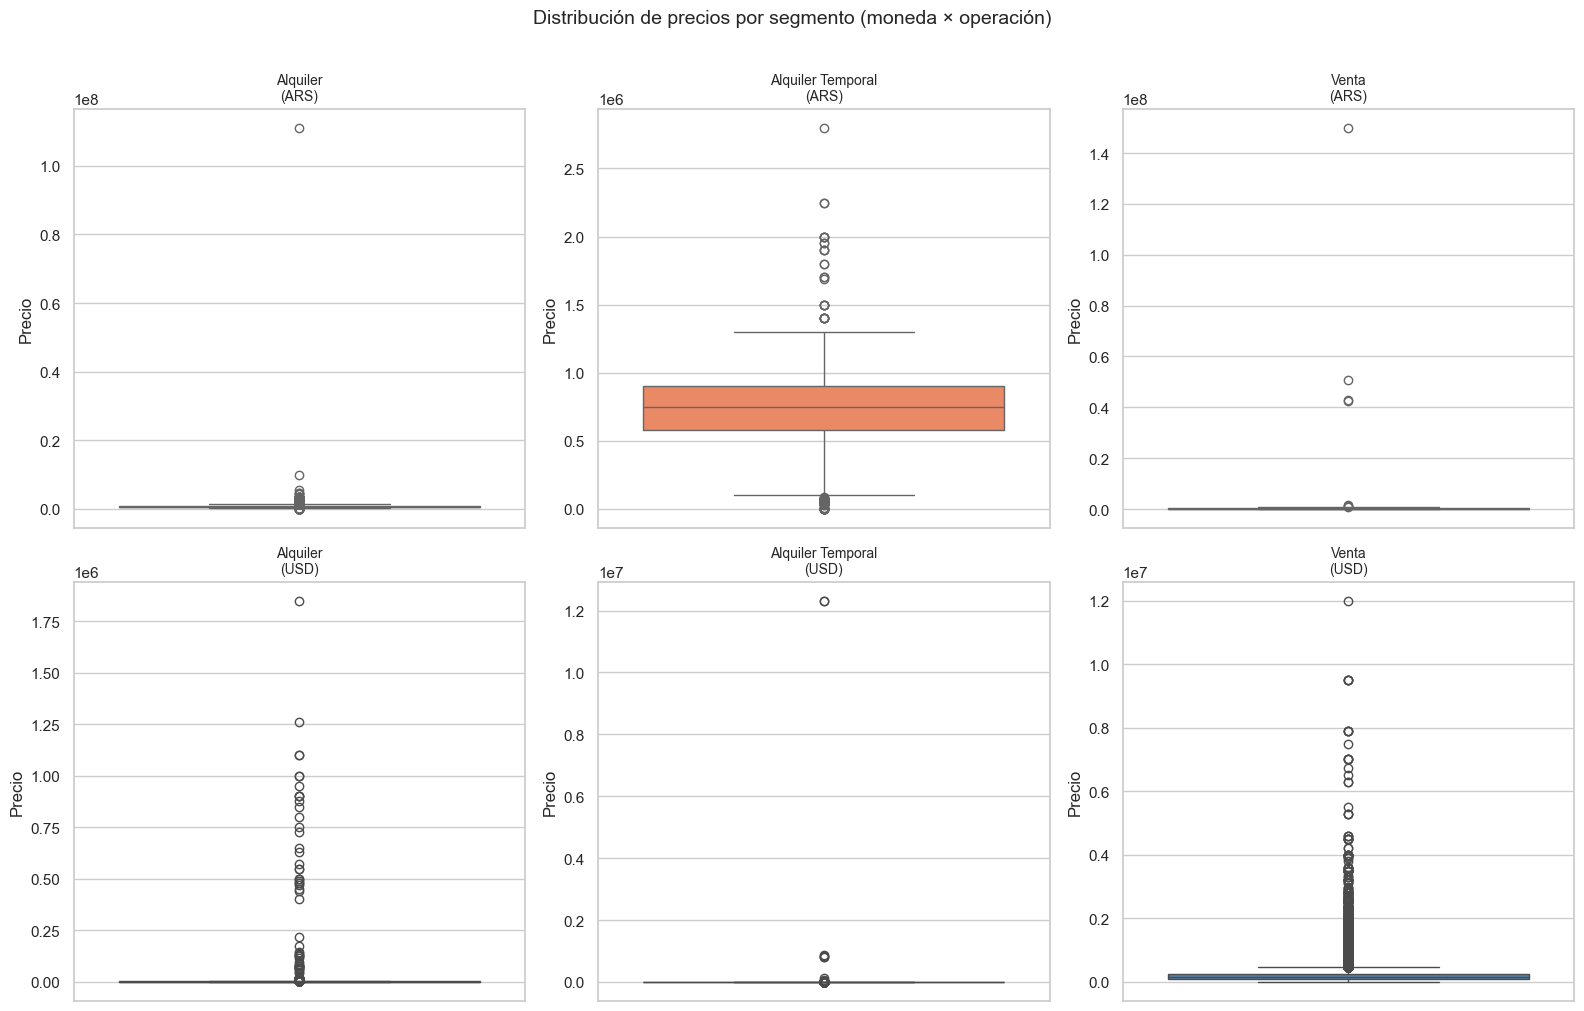

In [236]:
df_plot = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# Definimos los segmentos a graficar
monedas = ['ars', 'usd']
operaciones = ['alquiler', 'alquiler_temporal', 'venta']

fig, axes = plt.subplots(
    nrows=len(monedas),
    ncols=len(operaciones),
    figsize=(16, 10),
    sharex=False,
    sharey=False
)

for i, moneda in enumerate(monedas):
    for j, operacion in enumerate(operaciones):
        ax = axes[i][j]
        subset = df_plot[(df_plot['moneda'] == moneda) & (df_plot['operacion'] == operacion)]['precio'].dropna()

        if len(subset) > 0:
            sns.boxplot(y=subset, ax=ax, color='steelblue' if moneda == 'usd' else 'coral')
            ax.set_title(f"{operacion.replace('_', ' ').title()}\n({moneda.upper()})", fontsize=10)
        else:
            ax.set_visible(False)

        ax.set_xlabel("")
        ax.set_ylabel("Precio")

fig.suptitle("Distribución de precios por segmento (moneda × operación)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Podemos ver una clara presencia de outliers, que no nos permiten interpretar la información del boxplot. Pero sí podemos determinar que claramente necesitamos un tratar estos outliers. 

Ahora bien, para poder entender estas distribuciones, vamos a realizar un histograma, con un rango reducido:

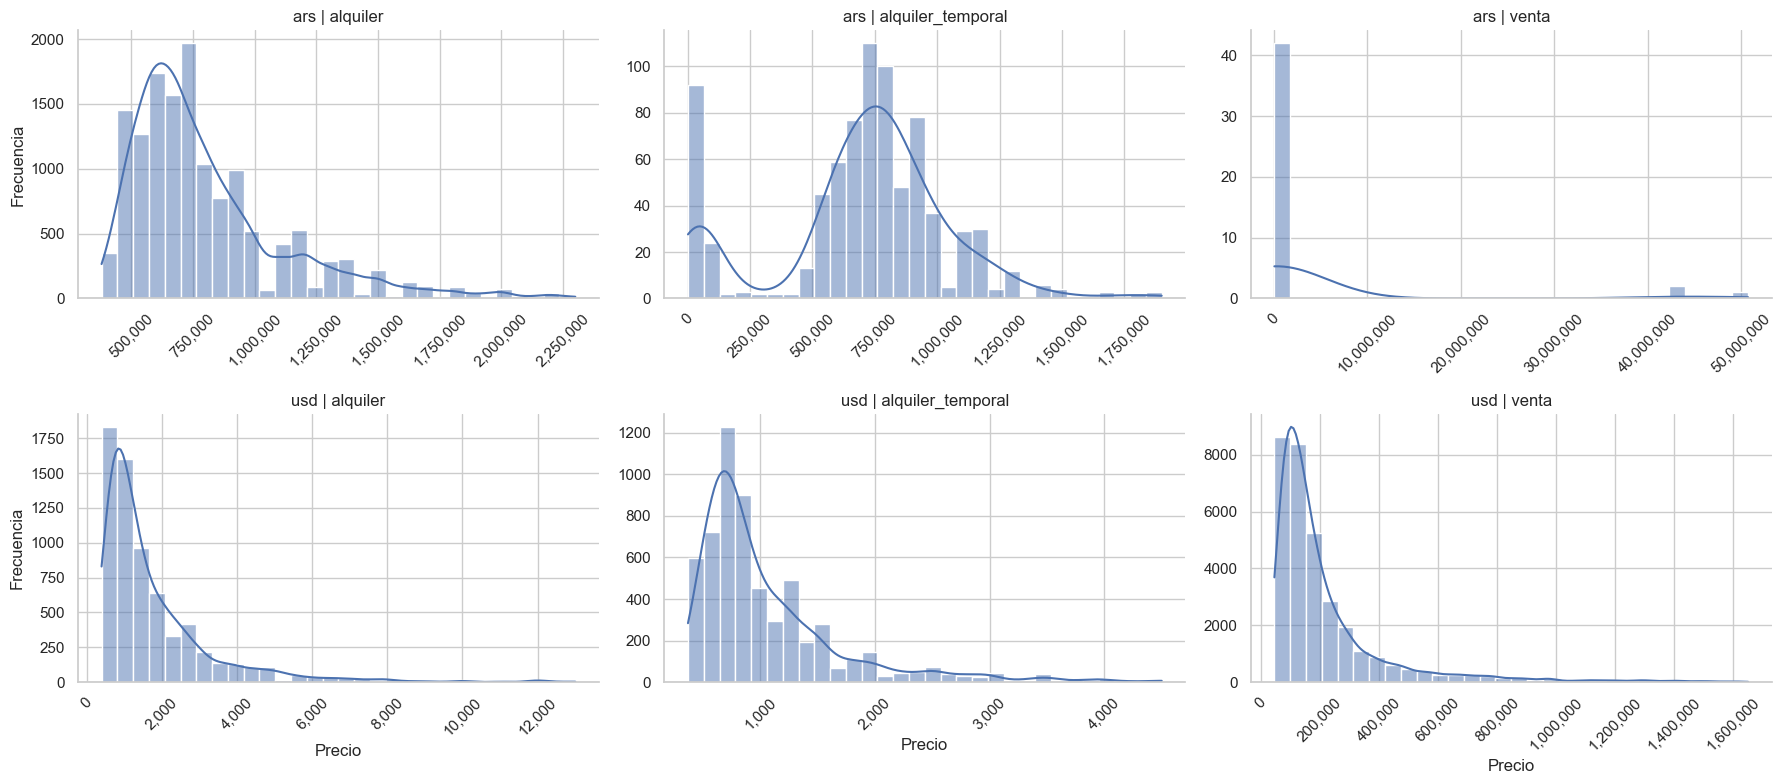

In [237]:
import matplotlib.ticker as ticker

df_precio = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# Recortamos al rango P1-P99 por segmento para la visualización.
# Los outliers extremos distorsionan el eje x y comprimen la distribución
# real en una franja muy pequeña, haciendo ilegible el gráfico.

pieces = []
for _, grupo in df_precio.groupby(['moneda', 'operacion']):
    p1  = grupo['precio'].quantile(0.01)
    p99 = grupo['precio'].quantile(0.99)
    pieces.append(grupo[(grupo['precio'] >= p1) & (grupo['precio'] <= p99)])
df_precio_clip = pd.concat(pieces).reset_index(drop=True)

g = sns.FacetGrid(df_precio_clip, row="moneda", col="operacion",
                  sharex=False, sharey=False, height=4, aspect=1.5)

g.map_dataframe(sns.histplot, x="precio", bins=30, kde=True)

for ax in g.axes.flat:
    ax.ticklabel_format(style='plain', axis='x')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.tick_params(axis='x', rotation=45)

g.set_axis_labels("Precio", "Frecuencia")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

Entonces, para mejorar la legibilidad, recortamos los precios al rango entre el percentil 1 y el percentil 99 dentro de cada segmento (moneda y tipo de operación) para esta visualización.

Podemos ver, que en casi todos los casos, los precios tienden a concentrarse a la izquierda, por lo que podemos identificar una asimetria positiva. Por la naturaleza del sistema inmobiliario, es normal que igualmente existan departamentos con valores mas altos, por ser departamentos mas lujosos, o en zonas mas premium. Esto lo tendremos en cuenta para realizar nuestro analisis.

# 5. Feature Engineering - Parseo de texto

Extraemos variables estructuradas a partir de las columnas de texto libre 'detalles' y 'descripción' mediante expresiones regulares. Luego calculamos los KPIs definidos en la entrega anterior.

In [238]:
detalles = df['detalles'].unique()
print(detalles)

<StringArray>
[          '60 m² tot. 2 amb. 1 dorm. 1 baño',
 '114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.',
 '121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.',
           '66 m² tot. 2 amb. 1 dorm. 1 baño',
 '117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.',
           '30 m² tot. 1 amb. 1 dorm. 1 baño',
           '40 m² tot. 2 amb. 1 dorm. 1 baño',
 '148 m² tot. 4 amb. 3 dorm. 2 baños 1 coch.',
           '67 m² tot. 2 amb. 1 dorm. 1 baño',
           '43 m² tot. 1 amb. 1 dorm. 1 baño',
 ...
             '3 m² cubie. 1 dorm. A Estrenar',
              '111 m² cubie. 3 dorm. 70 años',
                 '20 m² cubie. 4 años 1 baño',
              '103 m² cubie. 2 dorm. 2 baños',
               '54 m² cubie. 1 dorm. 80 años',
            '84,81 m² cubie. 3 dorm. 2 baños',
               '71 m² cubie. 2 dorm. 35 años',
              '111 m² cubie. 2 dorm. 2 baños',
               '90 m² cubie. 3 dorm. 27 años',
               '99 m² cubie. 2 dorm. 95 años']
Length: 14129, dtype: str


Los detalles pueden incluir distintos datos, pero extraemos únicamente m², ambientes, dormitorios, baños y antigüedad, que son las variables numéricas que necesitamos.

Las demás las obtenemos de descripción, como variables binarias o categóricas (si la descripción menciona cada uno de los valores).

## Funciones

In [239]:
import pandas as pd
import re

def parse_detalles(s):
    """Parsea la columna 'detalles' de ZonaProp/ArgEnProp en columnas individuales."""
    if pd.isna(s):
        return {}
    result = {}

    # Superficie total (ej: "60 m² tot." o "60 m² cubie.")
    m_tot = re.search(r'([\d,\.]+)\s*m²\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²\s*cubie\.?', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # Ambientes (ej: "3 amb." o "3 ambientes")
    amb = re.search(r'(\d+)\s*amb\.', s)
    ambientes = re.search(r'(\d+)\s*ambientes', s)
    if amb:
        result['ambientes'] = int(amb.group(1))
    elif ambientes:
        result['ambientes'] = int(ambientes.group(1))

    # Dormitorios (ej: "2 dorm.")
    dorm = re.search(r'(\d+)\s*dorm\.', s)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # Baños (ej: "1 baño" o "2 baños")
    ban = re.search(r'(\d+)\s*baños?', s)
    if ban:
        result['baños'] = int(ban.group(1))
        
    # Antigüedad: 0 si "A estrenar", número si "X años" o año de construcción
    match_antiguedad = re.search(r'(\d+)\s*(?:años|año)', s, re.IGNORECASE)
    
    a_estrenar = re.search(r'A\s*[Ee]strenar', s)

    if a_estrenar:
        result['antiguedad_años'] = 0
    elif match_antiguedad:
        valor = int(match_antiguedad.group(1))
        if valor >= 1800:
            # Si puso 1980, calculamos la edad al 2026
            antiguedad = 2026 - valor
            result['antiguedad_años'] = max(0, antiguedad)
        elif valor >= 150:
            # probablemente sea un error, ponemos nan y lo tratamos despues
            result['antiguedad_años'] = np.nan
        else:
            # Si puso 27, son 27 años
            result['antiguedad_años'] = valor
    else:
        # Si no encuentra ninguna mención a años, lo dejamos como NaN
        result['antiguedad_años'] = np.nan

    return result

In [240]:
def parse_descripcion(s):
    if pd.isna(s):
        return {}

    s_low = s.lower()
    result = {}

    # --- Orientación ---
    if re.search(r'contra\s*frente|contrafrente', s_low):
        result['orientacion'] = 'Contra Frente'
    elif re.search(r'\bfrente\b', s_low):
        result['orientacion'] = 'Frente'
    elif re.search(r'\blateral\b', s_low):
        result['orientacion'] = 'Lateral'

    # --- Vista ---
    if re.search(r'vista\s*al?\s*r[íi]o', s_low):
        result['vista_rio'] = True
    if re.search(r'vista\s*al?\s*park|vista\s*verde|vista\s*jard[íi]n', s_low):
        result['vista_verde'] = True

    # --- Balcón ---
    if re.search(r'balc[oó]n', s_low):
        result['balcon'] = True

    # --- Terraza ---
    if re.search(r'terraza', s_low):
        result['terraza'] = True

    # --- Pileta ---
    if re.search(r'pileta|piscina', s_low):
        result['pileta'] = True

    # --- Parrilla ---
    if re.search(r'parrill[ao]', s_low):
        result['parrilla'] = True

    # --- SUM ---
    if re.search(r'\bsum\b|sal[oó]n\s*de\s*usos\s*m[uú]ltiples', s_low):
        result['sum'] = True

    # --- Laundry / Lavadero ---
    if re.search(r'laundry|lavadero', s_low):
        result['lavadero'] = True

    # --- Gimnasio ---
    if re.search(r'gimnasio|gym\b', s_low):
        result['gimnasio'] = True

    # --- Baulera ---
    if re.search(r'baulera', s_low):
        result['baulera'] = True

    # --- Calefacción ---
    if re.search(r'piso\s*radiante', s_low):
        result['calefaccion'] = 'Piso radiante'
    elif re.search(r'radiadores?', s_low):
        result['calefaccion'] = 'Radiadores'
    elif re.search(r'calefacci[oó]n\s*central', s_low):
        result['calefaccion'] = 'Central'
    elif re.search(r'calefacci[oó]n', s_low):
        result['calefaccion'] = 'Sí'

    # --- Agua caliente central ---
    if re.search(r'agua\s*caliente\s*central', s_low):
        result['agua_caliente_central'] = True

    # --- Ascensor ---
    if re.search(r'sin\s*ascensor|no\s*tiene\s*ascensor', s_low):
        result['ascensor'] = False
    elif re.search(r'ascensor', s_low):
        result['ascensor'] = True

    # --- Portero ---
    if re.search(r'portero\s*(?:el[eé]ctrico|visor|virtual)', s_low):
        result['portero'] = True

    # --- Apto profesional ---
    if re.search(r'no\s*apto\s*prof', s_low):
        result['apto_profesional'] = False
    elif re.search(r'apto\s*prof|apto\s*para\s*prof', s_low):
        result['apto_profesional'] = True

    # --- Mascotas ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:mascotas?|animales?)|no\s*mascotas?', s_low):
        result['permite_mascotas'] = 0
    elif re.search(r'acept[ao]\s*mascotas?|permite?\s*mascotas?|mascotas?\s*(?:ok|permitidas?)|apto\s*mascota', s_low):
        result['permite_mascotas'] = 1

    # --- Garantías ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = False
    elif re.search(r'(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = True
    if re.search(r'finaer', s_low):
        result['acepta_finaer'] = True

    # --- Financiación ---
    if re.search(r'financiaci[oó]n|financia\b', s_low):
        result['ofrece_financiacion'] = True

    # --- Accesibilidad ---
    if re.search(r'movilidad\s*reducida|accesible\s*para\s*personas', s_low):
        result['accesible_movilidad_reducida'] = True

    # --- Dependencia de servicio ---
    if re.search(r'dependencia\s*(?:de\s*)?servicio', s_low):
        result['dependencia_servicio'] = True

    # --- Cocina tipo ---
    if re.search(r'cocina\s*american[ao]|cocina\s*integrada|cocina\s*abierta', s_low):
        result['cocina_tipo'] = 'Americana/Integrada'
    elif re.search(r'cocina\s*independiente|cocina\s*separada', s_low):
        result['cocina_tipo'] = 'Independiente'

    # --- Expensas (responsabilidad de pago) ---
    # Caso especial: el precio publicado ya incluye las expensas en el monto
    if re.search(r'expensas?\s*incluidas?|incluye\s*expensas?', s_low):
        result['tiene_expensas'] = 0
        result['expensas_incluidas_en_precio'] = True
    elif re.search(r'sin\s*expensas?|expensas?\s*a\s*cargo\s*del\s*(propietario|due[\xf1n]o)', s_low):
        result['tiene_expensas'] = 0
    # Sin mención explícita: el default por operación se aplica más adelante

    return result


## Implementamos las funciones

In [241]:
df_det = pd.DataFrame(df['detalles'].apply(parse_detalles).tolist())

In [242]:
df_desc = pd.DataFrame(df['descripción'].apply(parse_descripcion).tolist())

In [243]:
# Detalles tiene prioridad sobre descripción por ser más confiable
combined = df_det.combine_first(df_desc)

In [244]:
bool_cols = [
    'balcon', 'terraza', 'pileta', 'parrilla', 'sum', 'lavadero', 'gimnasio',
    'baulera', 'aire_acondicionado', 'agua_caliente_central', 'ascensor',
    'portero', 'seguridad_24hs', 'apto_profesional', 'permite_mascotas',
    'acepta_caucion', 'acepta_finaer', 'ofrece_financiacion',
    'accesible_movilidad_reducida', 'dependencia_servicio',
    'vista_rio', 'vista_verde', 'monoambiente',
    'expensas_incluidas_en_precio',
]

for col in bool_cols:
    if col in combined.columns:
        combined[col] = combined[col].map({True: 1, False: 0}).fillna(0).astype(int)


In [245]:
combined.head(10)

,m2_total,ambientes,dormitorios,baños,antiguedad_años,balcon,terraza,lavadero,calefaccion,permite_mascotas,orientacion,parrilla,acepta_caucion,pileta,gimnasio,cocina_tipo,apto_profesional,agua_caliente_central,dependencia_servicio,sum,ofrece_financiacion,baulera,ascensor,accesible_movilidad_reducida,acepta_finaer,tiene_expensas,expensas_incluidas_en_precio,vista_rio,vista_verde,portero
0,60,2,1,1,NaN,1,1,1,Sí,0,NaN,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
1,114,3,2,2,NaN,1,1,1,NaN,0,Contra Frente,1,1,0,0,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
2,121,4,2,2,NaN,1,0,1,NaN,0,NaN,1,0,1,1,Independiente,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
3,66,2,1,1,NaN,1,1,0,NaN,0,Frente,0,0,0,0,Americana/Integrada,1,0,0,0,0,0,0,0,0,NaN,0,0,0,0
4,117,3,2,2,NaN,0,0,0,NaN,0,NaN,0,0,1,1,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
5,30,1,1,1,NaN,0,0,1,NaN,0,NaN,1,0,0,0,NaN,0,1,0,0,0,0,0,0,0,NaN,0,0,0,0
6,40,2,1,1,NaN,0,0,0,NaN,0,NaN,0,0,0,0,Independiente,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
7,148,4,3,2,NaN,0,0,0,NaN,0,Frente,0,0,0,0,NaN,0,0,1,0,0,0,0,0,0,NaN,0,0,0,0
8,67,2,1,1,NaN,1,0,1,NaN,0,Frente,1,0,1,1,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
9,43,1,1,1,NaN,1,0,0,NaN,0,Frente,0,0,0,0,NaN,1,1,0,0,0,0,0,0,0,NaN,0,0,0,0


Agregamos las nuevas variables al DataFrame.

In [246]:
df_final = pd.concat([df, combined], axis=1)
df_final.head()

,fecha_scraping,posting_id,sitio,operacion,precio,expensas,calle,altura,piso,barrio,detalles,descripción,link,amenities,losa_central,aire_acond,apto_credito,cochera,seguridad,luminoso,balcon_aterrazado,barrio_norm,barrio_oficial,moneda,m2_total,...,balcon,terraza,lavadero,calefaccion,permite_mascotas,orientacion,parrilla,acepta_caucion,pileta,gimnasio,cocina_tipo,apto_profesional,agua_caliente_central,dependencia_servicio,sum,ofrece_financiacion,baulera,ascensor,accesible_movilidad_reducida,acepta_finaer,tiene_expensas,expensas_incluidas_en_precio,vista_rio,vista_verde,portero
0,2026-04-12,58757240,zonaprop,alquiler,"750,000","300,000",Mansilla,"2,936",NaN,Barrio Norte,60 m² tot. 2 amb. 1 dorm. 1 baño,Amplio departamento de dos ambientes en el exc...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,0,0,1,0,Barrio Norte,Recoleta,ars,60,...,1,1,1,Sí,0,NaN,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
1,2026-04-12,58818211,zonaprop,alquiler,"1,700,000","400,000",Cespedes,"2,300",NaN,Belgrano,114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,"3 ambientes con balcón, y terraza con parrilla...",https://www.zonaprop.com.ar/propiedades/clasif...,1,0,0,0,1,0,0,0,Belgrano,Belgrano,ars,114,...,1,1,1,NaN,0,Contra Frente,1,1,0,0,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
2,2026-04-12,58564550,zonaprop,alquiler,"2,500","1,150,000",Riobamba,"1,200",NaN,Recoleta,121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.,Departamento en alquiler de 4 ambientes con co...,https://www.zonaprop.com.ar/propiedades/clasif...,4,0,0,0,1,1,1,0,Recoleta,Recoleta,usd,121,...,1,0,1,NaN,0,NaN,1,0,1,1,Independiente,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0
3,2026-04-12,58314210,zonaprop,alquiler,"1,300",NaN,Pereyra Lucena,"2,500",NaN,Palermo,66 m² tot. 2 amb. 1 dorm. 1 baño,Amoblado y Equipado. Ubicado a metros de Av. L...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,1,0,1,1,Palermo,Palermo,usd,66,...,1,1,0,NaN,0,Frente,0,0,0,0,Americana/Integrada,1,0,0,0,0,0,0,0,0,NaN,0,0,0,0
4,2026-04-12,58810878,zonaprop,alquiler,"3,800",NaN,Lola Mora,400,NaN,Puerto Madero,117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,Alquiler temporario de 3 ambientes amueblado e...,https://www.zonaprop.com.ar/propiedades/clasif...,3,0,0,0,1,1,0,0,Puerto Madero,Puerto Madero,usd,117,...,0,0,0,NaN,0,NaN,0,0,1,1,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0


In [247]:
# Defaults de tiene_expensas por tipo de operación (sólo donde no se detectó nada en el texto)
default_por_op = {'alquiler': 1, 'alquiler_temporal': 0}  # venta queda NaN
df_final['tiene_expensas'] = (
    df_final['tiene_expensas']
    .fillna(df_final['operacion'].map(default_por_op))
)

# Garantizar que la columna exista aunque ningún aviso haya mencionado 'expensas incluidas'
if 'expensas_incluidas_en_precio' not in df_final.columns:
    df_final['expensas_incluidas_en_precio'] = False
df_final['expensas_incluidas_en_precio'] = df_final['expensas_incluidas_en_precio'].fillna(False).astype(bool)


# 6. Tratamiento de expensas

Las expensas deberían estar expresadas en pesos argentinos. Aun así, es posible que algunos valores estén en dólares o sean inusualmente bajos para el mercado de 2026 en Buenos Aires. El siguiente análisis busca detectar valores sospechosos que podrían indicar errores de carga o valores en otra moneda.

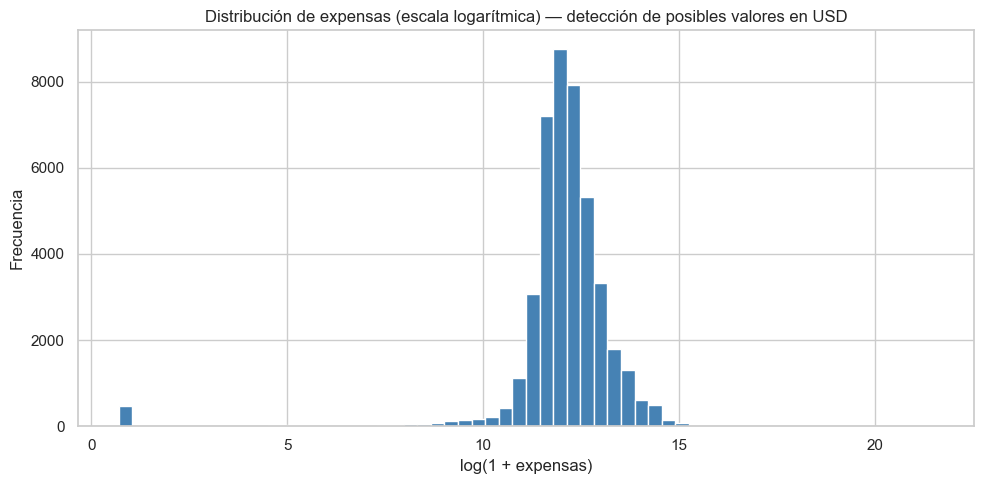

In [248]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_final['expensas'].dropna()
ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")
plt.tight_layout()
plt.show()

Vemos que hay un grupo de valores con expensas muy bajas. Para determinar dónde está el corte, usamos el gráfico de codo.

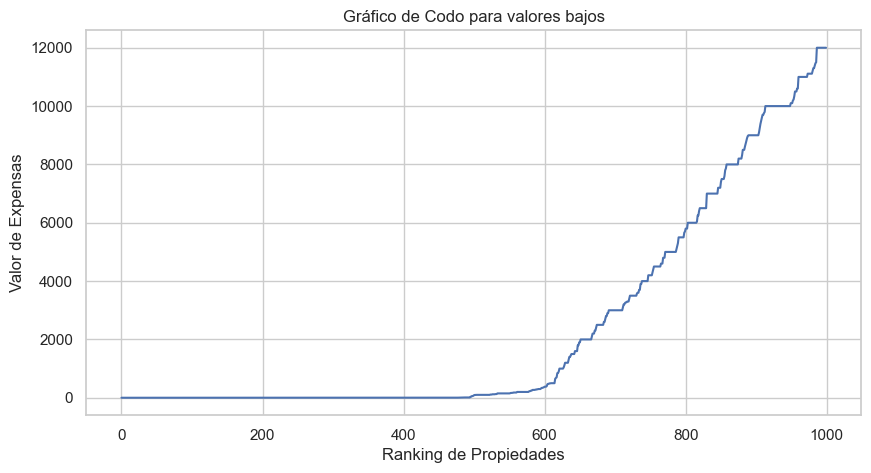

In [249]:
# Ordenamos los valores de menor a mayor
expensas_ordenadas = df_final['expensas'].dropna().sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(expensas_ordenadas[:1000]) # Miramos los primeros 500 registros más bajos
plt.ylabel("Valor de Expensas")
plt.xlabel("Ranking de Propiedades")
plt.title("Gráfico de Codo para valores bajos")
plt.show()

En este gráfico vemos que hasta la propiedad número 500 aproximadamente el valor es 0, que corresponde a departamentos sin expensas. Entre la propiedad 500 y la 600 la línea empieza a despegarse muy lentamente, con valores insignificantes (1, 10, 100 pesos), que representan casos donde la persona ingresó un número simbólico en lugar de dejar el campo vacío.

El verdadero salto de mercado, donde la pendiente se vuelve empinada y constante, empieza alrededor de la propiedad 600, que coincide con valores superiores a los $2.000 - $3.000. Ahí fijamos nuestro umbral.

In [250]:
import numpy as np

# Definimos el umbral a partir del gráfico de codo
umbral_basura = 100
umbral_minimo_mercado = 4000 

# Creamos una columna nueva para no modificar la original
df_final['expensas_ok'] = df_final['expensas']

# Aplicamos la lógica deducida del gráfico
df_final.loc[df_final['expensas'] < umbral_basura, 'expensas_ok'] = 0
mask_error = (df_final['expensas'] >= umbral_basura) & (df_final['expensas'] < umbral_minimo_mercado)
df_final.loc[mask_error, 'expensas_ok'] = np.nan

# Calculamos estadisticas sobre la columna limpia
resumen_expensas_ok = df_final.groupby('operacion')['expensas_ok'].agg(
    count='count',         
    media='mean',          # La media debería subir
    mediana='median',      # La mediana va a ser más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("Resumen de expensas LIMPIAS:")
print(resumen_expensas_ok)

# y sobre la columna original
resumen_expensas_og = df_final.groupby('operacion')['expensas'].agg(
    count='count',         
    media='mean',          # La media debería subir
    mediana='median',      # La mediana va a ser más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("\nResumen de expensas ORIGINALES:")
print(resumen_expensas_og)

# Verificamos si quedan valores sospechosos
sospechosos_nuevos = df_final[
    (df_final['expensas_ok'] > 0) & 
    (df_final['expensas_ok'] < umbral_minimo_mercado)
]['expensas_ok']

print(f"\nSospechosos en columna limpia: {len(sospechosos_nuevos)}")

# 1. Cuántos eran menores a 100 (convertidos a 0)
cant_a_cero = len(df_final[(df_final['expensas'] < 100)])

# 2. Cuántos eran "ruido" (convertidos a NaN)
cant_a_nan = len(df_final[(df_final['expensas'] >= 100) & (df_final['expensas'] < 4000)])

# 3. Resumen total
total_registros = len(df_final)

print(f"\n--- Auditoría de Limpieza de Expensas ---")
print(f"Total de registros analizados: {total_registros}")
print(f"Registros llevados a 0 (sin expensas): {cant_a_cero}")
print(f"Registros anulados (ruido/errores): {cant_a_nan}")
print(f"Total de datos modificados: {cant_a_cero + cant_a_nan}")
print(f"Porcentaje de datos 'sucios' eliminados: {((cant_a_nan / total_registros) * 100):.2f}%")

# Reemplazamos los valores de expensas por expensas_ok
df_final = df_final.drop(columns=['expensas']).rename(columns={'expensas_ok': 'expensas'})

Resumen de expensas LIMPIAS:
                   count   media  mediana     p5
operacion                                       
alquiler           17902 525,461  180,000 75,000
alquiler_temporal   2972 205,321  154,124 15,000
venta              21990 300,591  190,000 45,500

Resumen de expensas ORIGINALES:
                   count   media  mediana     p5
operacion                                       
alquiler           17977 523,271  180,000 74,000
alquiler_temporal   3009 202,799  150,000    540
venta              22113 298,931  187,200 40,000

Sospechosos en columna limpia: 0

--- Auditoría de Limpieza de Expensas ---
Total de registros analizados: 62937
Registros llevados a 0 (sin expensas): 503
Registros anulados (ruido/errores): 235
Total de datos modificados: 738
Porcentaje de datos 'sucios' eliminados: 0.37%


Revisamos cómo quedó:

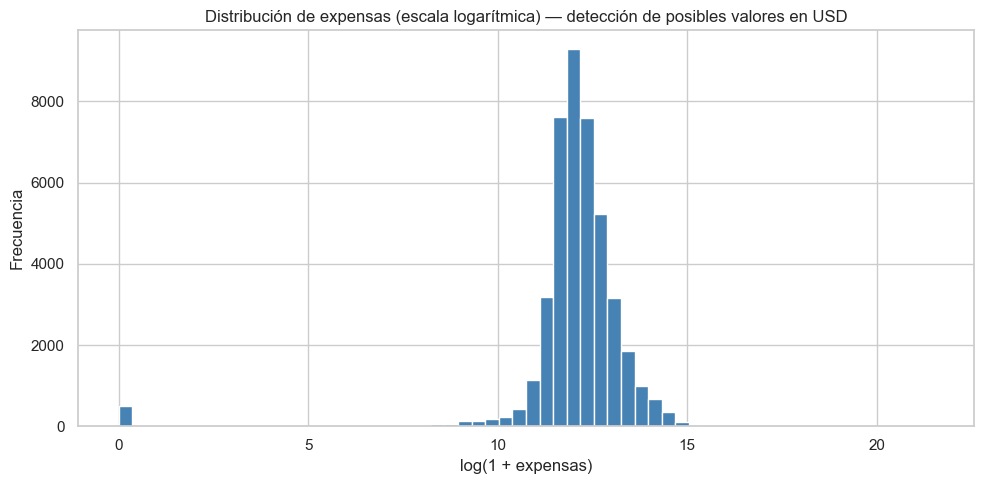

In [251]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_final['expensas'].dropna()

ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")

plt.tight_layout()
plt.show()

Ahora, el unico salto que se ve es por aquellos que determinamos que tienen expensas=0.

# 7. Valores faltantes

## Inspeccionamos

Vemos cómo se estructuran los valores faltantes.

In [252]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
       Variable  Datos_Faltantes  Porcentaje
         precio             1494           2
          calle             5370           9
         altura             5370           9
           piso            49314          78
       detalles              220           0
    descripción              293           0
 barrio_oficial                3           0
       m2_total             2436           4
      ambientes            30464          48
    dormitorios            13624          22
          baños            21414          34
antiguedad_años            36952          59
    calefaccion            50844          81
    orientacion            30324          48
    cocina_tipo            42540          68
 tiene_expensas            33247          53
       expensas            20073          32


Muchos valores faltantes provienen de las columnas que agregamos en el parseo, tanto de detalles como de descripción. Separamos por sitio para ver si ZonaProp y ArgenProp presentan diferencias en la cobertura de cada campo.

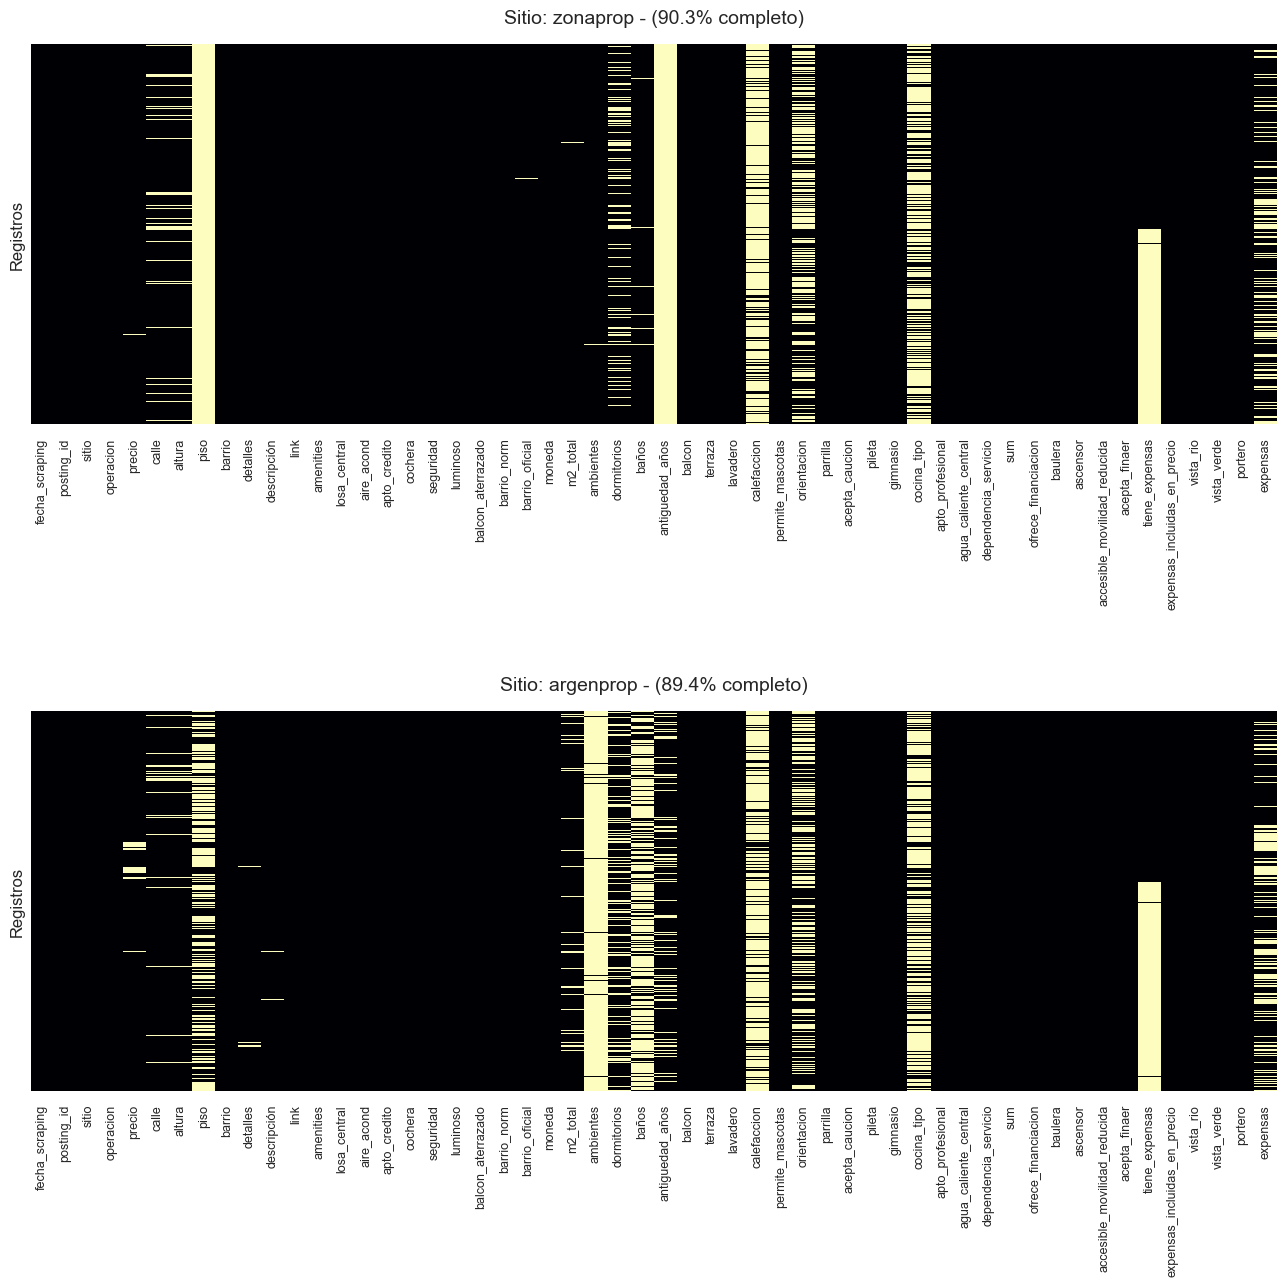

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

# Aumentamos un poco el ancho (14) para que las columnas respiren
fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    # cmap='magma' suele resaltar mejor los nulos (amarillo sobre negro/morado)
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    # Forzamos que se muestren TODAS las etiquetas
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Vemos que variables como ambientes y baños están prácticamente completas en ZonaProp y prácticamente vacías en ArgenProp, mientras que antigüedad_años ocurre al revés. A continuación revisamos cómo se compone la columna detalles en cada sitio.

In [254]:
df_final[df_final['sitio']=='zonaprop']['detalles']

0                  60 m² tot. 2 amb. 1 dorm. 1 baño
1        114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
2        121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.
3                  66 m² tot. 2 amb. 1 dorm. 1 baño
4        117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
                            ...                    
31745           150 m² tot. 2 dorm. 2 baños 1 coch.
31746              51 m² tot. 2 amb. 1 dorm. 1 baño
31747              77 m² tot. 3 amb. 2 dorm. 1 baño
31748    169 m² tot. 4 amb. 3 dorm. 2 baños 2 coch.
31749             80 m² tot. 3 amb. 2 dorm. 2 baños
Name: detalles, Length: 31750, dtype: str

In [255]:
df_final[df_final['sitio']=='argenprop']['detalles']

31750         47 m² cubie. Monoam. Bueno
31751       80 m² cubie. 2 dorm. 15 años
31752      100 m² cubie. 2 dorm. 40 años
31753        27 m² cubie. 1 baño Monoam.
31754       34 m² cubie. 1 dorm. 80 años
                      ...               
62932       63 m² cubie. 2 dorm. 30 años
62933        25 m² cubie. 40 años 1 baño
62934    60 m² cubie. 1 dorm. A Estrenar
62935       65 m² cubie. 2 dorm. 15 años
62936       62 m² cubie. 3 dorm. 50 años
Name: detalles, Length: 31187, dtype: str

Vemos reflejadas esas diferencias en la composición de la columna.

Para confirmar formalmente lo que vemos en los gráficos, realizamos un test de independencia chi-cuadrado entre el indicador de dato faltante y el sitio de origen (ArgenProp vs ZonaProp). La hipótesis nula plantea que la ausencia de un valor es independiente del sitio. Rechazarla indica que el mecanismo de faltantes depende de una variable observada (el sitio de scraping), lo que encuadra el patrón como MAR (Missing At Random condicionado al sitio) y justifica una estrategia de imputación diferenciada por sitio.

In [256]:
from scipy.stats import chi2_contingency

vars_test = ['ambientes', 'baños', 'dormitorios', 'antiguedad_años',
             'calle', 'altura', 'calefaccion', 'cocina_tipo', 'orientacion']
vars_test = [v for v in vars_test if v in df_final.columns]

resultados = []
for var in vars_test:
    indicador = df_final[var].isna().astype(int)
    if indicador.sum() == 0:
        continue
    tabla = pd.crosstab(df_final['sitio'], indicador)
    if tabla.shape[1] < 2:
        continue
    chi2_stat, p, dof, _ = chi2_contingency(tabla)
    pct = df_final.groupby('sitio')[var].apply(lambda x: x.isna().mean() * 100).round(1)
    resultados.append({
        'variable': var,
        'faltantes ArgenProp (%)': pct.get('argenprop', 0),
        'faltantes ZonaProp (%)': pct.get('zonaprop', 0),
        'chi2': round(chi2_stat, 2),
        'p-valor': round(p, 4),
        'MAR respecto a sitio': 'Sí (p < 0.05)' if p < 0.05 else 'No se rechaza H₀'
    })

df_mar = pd.DataFrame(resultados)
display(df_mar)

,variable,faltantes ArgenProp (%),faltantes ZonaProp (%),chi2,p-valor,MAR respecto a sitio
0,ambientes,97,1,"58,050",0,Sí (p < 0.05)
1,baños,67,2,"29,559",0,Sí (p < 0.05)
2,dormitorios,23,21,35,0,Sí (p < 0.05)
3,antiguedad_años,17,100,"45,053",0,Sí (p < 0.05)
4,calle,6,11,441,0,Sí (p < 0.05)
5,altura,6,11,441,0,Sí (p < 0.05)
6,calefaccion,81,80,13,0,Sí (p < 0.05)
7,cocina_tipo,69,67,30,0,Sí (p < 0.05)
8,orientacion,47,49,33,0,Sí (p < 0.05)


También hay variables con muchos valores faltantes en ambos sitios, ya sea porque no estaban disponibles en el scraper (como calle, altura y piso) o porque el parseo de descripción no las capturó bien (como calefacción, cocina_tipo y orientación).

Teniendo esto en cuenta, usamos distintas técnicas para tratar los valores faltantes según el caso.

## Tratamos los valores faltantes

### Expensas

Para tratar las expensas usamos la variable tiene_expensas, que construimos a partir del parseo de descripción. Si el valor es faltante y tiene_expensas es 0, imputamos un 0. Si tiene_expensas es 1, usamos el precio y el barrio para imputar el valor.

In [257]:
# Imputación de expensas
# Todos los registros deben terminar con un valor, independientemente de quién las paga (tiene_expensas). 
# Si tiene_expensas == 0 y expensas_incluidas_en_precio == 0, las paga el propietario
# Si tiene_expensas == 0 y expensas_incluidas_en_precio == 1, las paga el inquilino indirectamente
# Si tiene expensas == 1, las paga el inquilino directamente 
# El monto existe siempre.

df_final['segmento_precio'] = pd.qcut(df_final['precio'], q=10, labels=False, duplicates='drop')

# Imputación en cascada: barrio_oficial × segmento → segmento → mediana global
df_final['expensas'] = df_final.groupby(['barrio_oficial', 'segmento_precio'])['expensas'].transform(
    lambda x: x.fillna(x.median())
)
df_final['expensas'] = df_final.groupby('segmento_precio')['expensas'].transform(
    lambda x: x.fillna(x.median())
)
df_final['expensas'] = df_final['expensas'].fillna(df_final['expensas'].median())

df_final.drop(columns=['segmento_precio'], inplace=True)

# Caso especial: avisos que publicaron precio + expensas como un solo número.
# Ahora que tenemos las expensas imputadas, las restamos del precio para limpiarlo.
# También marcamos tiene_expensas = 1 porque el inquilino sí las paga (incluidas en el alquiler).

mask_incluidas = df_final['expensas_incluidas_en_precio']
n_ajuste = mask_incluidas.sum()
df_final.loc[mask_incluidas, 'precio'] = (
    df_final.loc[mask_incluidas, 'precio'] - df_final.loc[mask_incluidas, 'expensas']
)
df_final.loc[mask_incluidas, 'tiene_expensas'] = 1
print(f"Filas con precio ajustado por 'expensas incluidas': {n_ajuste}")


# Tiene expensas aplica a las publicaciones de alquileres, no a las ventas
# Para las ventas, queda nulo porque no aplica al analisis


Filas con precio ajustado por 'expensas incluidas': 1357


### Ambientes, baños, dormitorios y antigüedad

Dado que estas variables aparecen principalmente en uno de los sitios, usamos los datos del otro como base e imputamos los valores según los m² del departamento.

In [258]:
# 1. Creamos rangos de m² para que la imputación sea coherente
df_final['m2_bin'] = pd.qcut(df_final['m2_total'], q=10, duplicates='drop')

# 2. Lista de variables estructurales a imputar
vars_estructurales = ['ambientes', 'baños', 'dormitorios', 'antiguedad_años']

for col in vars_estructurales:
    # Imputamos por la mediana de barrio y rango de m2
    df_final[col] = df_final.groupby(['barrio_oficial', 'm2_bin'])[col].transform(lambda x: x.fillna(x.median()))
    
    # Si quedan nulos (bin sin datos en ese barrio), usamos solo el bin
    df_final[col] = df_final.groupby('m2_bin')[col].transform(lambda x: x.fillna(x.median()))
    
    # Si todavia quedan nulos, usamos la mediana general
    df_final[col].fillna(df_final[col].median(), inplace=True)


# 4. Eliminamos columnas auxiliares
df_final.drop(columns='m2_bin', inplace=True, errors='ignore')

### Otras

Identificamos si la calle es una avenida, que puede ser un dato relevante.

In [259]:
avenidas_conocidas = ['avenida', 'av.', 'av ', 'diagonal']
df_final['sobre_avenida'] = df_final['calle'].str.lower().str.contains(
    '|'.join(avenidas_conocidas), na=False
).astype(int)


Finalmente, eliminamos las variables con un número muy alto de valores faltantes que no son relevantes para el análisis.

In [260]:
cols_descarte = ['piso', 'calefaccion', 'cocina_tipo', 'orientacion']
df_final.drop(columns=cols_descarte, inplace=True, errors='ignore')

## Revisamos cómo quedó

In [261]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
       Variable  Datos_Faltantes  Porcentaje
         precio             1494           2
          calle             5370           9
         altura             5370           9
       detalles              220           0
    descripción              293           0
 barrio_oficial                3           0
       m2_total             2436           4
      ambientes             2436           4
    dormitorios             2436           4
          baños             2436           4
antiguedad_años             2436           4
 tiene_expensas            33247          53


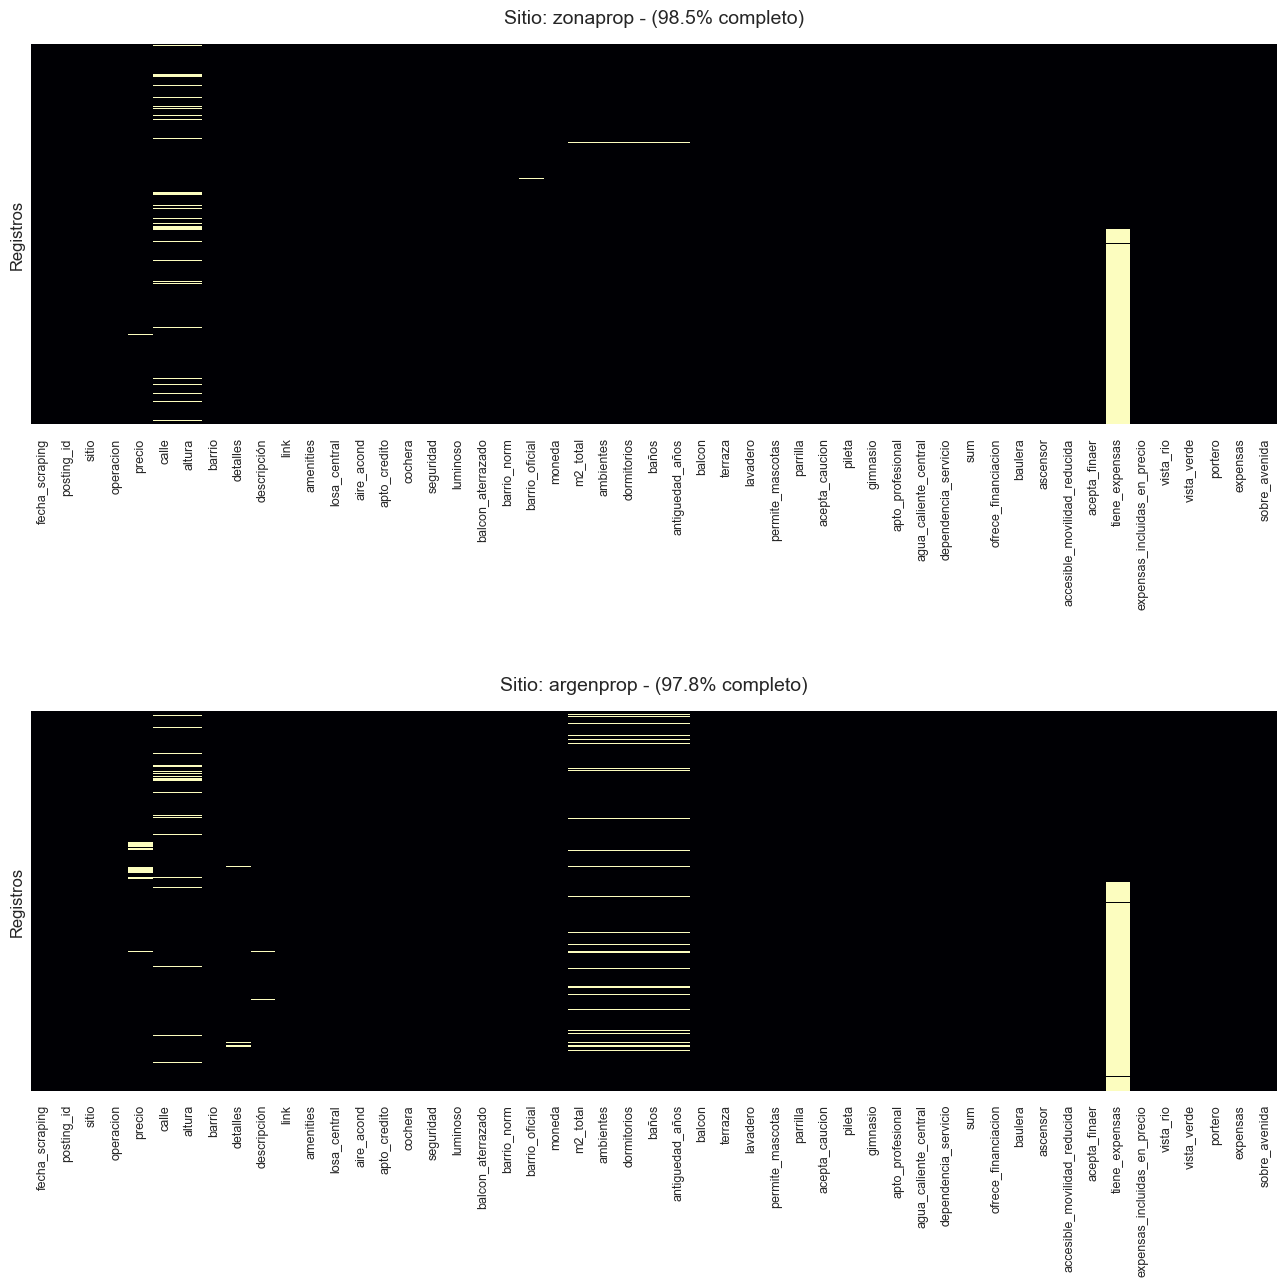

In [262]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Finalmente, eliminamos los pocos registros con datos faltantes que quedan, ya que son muy pocos y no vale la pena imputarlos. El precio y los metros cuadrados es importante que sean valores reales; y la descripción y los detalles son imposibles de completar de forma confiable.

Las columnas calle y altura las conservamos porque pueden ser útiles para un análisis geoespacial posterior, por ejemplo vinculando las propiedades con estaciones de subte. Como van a ser utilizadas exclusivamente para esos análisis, no decidimos imputar esas dos columnas. Como son ubicaciones específicas, preferimos mantener los valores que ya tenemos y no inventar ubicaciones. Además, el número de faltantes no es significativo (8.5%) para su propósito. 

La columna tiene_expensas la conservamos porque es puramente para los registros de alquileres y alquileres temporarios, no ventas

In [263]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

# 1. Eliminamos registros sin las variables fundamentales (precio y metros)
df_final.dropna(subset=['precio', 'm2_total', 'barrio_oficial'], inplace=True)

# 2. Eliminamos registros sin descripción o detalles
df_final.dropna(subset=['descripción', 'detalles'], inplace=True)

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados por nulos en variables clave: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados por nulos en variables clave: 4,114
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     14497    13658         839
                  usd      6879     6673         206
alquiler_temporal ars      2069      784        1285
                  usd      6065     5826         239
venta             ars       243       44         199
                  usd     33184    31838        1346


# 8. Tratamiento de Outliers (con precio_por_m²)

## Paso 1 - Imports

In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 50)

## Paso 2 - Calcular precio_por_m²

La variable 'precio_por_m2' constituye uno de los principales indicadores comparativos del mercado inmobiliario, ya que permite homogeneizar propiedades de distintas dimensiones y tipologías.

A diferencia del precio absoluto, esta métrica facilita detectar:
- zonas sobrevaluadas o subvaluadas,
- diferencias estructurales entre barrios,
- oportunidades de inversión,
- efectos de amenities o ubicación sobre la valuación relativa.

Entonces, usamos precio_por_m2 como KPI central. Sin esta normalización, un PH de 200 m² siempre va a parecer un outlier por precio total aunque sea perfectamente normal por m².

Filtramos antes de calcular para no propagar NaN ni divisiones inválidas.

Revisamos los valores muy bajos de m² que podrían ser errores de carga, para determinar dónde está el corte.

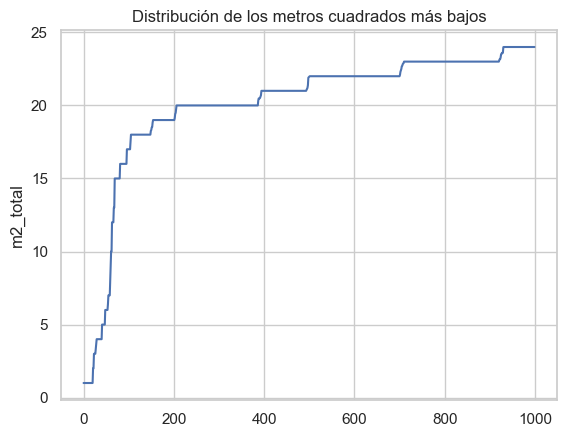

In [265]:
df_prueba = df_final.copy()

# Graficamos el "codo" de los metros cuadrados
plt.plot(df_prueba['m2_total'].sort_values().reset_index(drop=True)[:1000])
plt.title("Distribución de los metros cuadrados más bajos")
plt.ylabel("m2_total")
plt.show()

Por debajo de 15 m² hay algunos registros que no tienen sentido lógico para una unidad habitable. A partir de 15 m², la cantidad de departamentos crece claramente, lo que sugiere que los valores inferiores son errores de carga. Por eso los filtramos antes de calcular precio_por_m2.

In [266]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

mask_m2 = (
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 15) &
    df_final['precio'].notna() &
    (df_final['precio'] > 0)
)

df_final['precio_por_m2'] = float('nan')
df_final.loc[mask_m2, 'precio_por_m2'] = (
    df_final.loc[mask_m2, 'precio'] / df_final.loc[mask_m2, 'm2_total']
)

df_final = df_final[df_final['precio_por_m2'].notna()].copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados por m2 menor a 15 o precio inv??lido: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados por m2 menor a 15 o precio inv??lido: 943
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     13658    13614          44
                  usd      6673     6375         298
alquiler_temporal ars       784      781           3
                  usd      5826     5267         559
venta             ars        44       43           1
                  usd     31838    31800          38


Nos quedamos con los registros para los que se puede calcular precio_por_m2, ya que es una métrica central del análisis.

## Paso 3 - Deduplicar scraping

Al scrapear, el mismo aviso podría aparecer más de una vez. Deduplicamos usando posting_id y sitio como clave. Usar barrio, precio o m² como criterio sería incorrecto porque dos inmuebles distintos pueden coincidir en esas columnas.

In [267]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

df_final = df_final.drop_duplicates(subset=['posting_id', 'sitio'], keep='first').copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Duplicados de scraping eliminados: {log_df["eliminados"].sum():,}')
print(log_df)

assert df_final.duplicated(subset=['posting_id', 'sitio']).sum() == 0, "Todav??a hay duplicados!"

Duplicados de scraping eliminados: 4,953
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     13614    12900         714
                  usd      6375     5962         413
alquiler_temporal ars       781      677         104
                  usd      5267     4734         533
venta             ars        43       43           0
                  usd     31800    28611        3189


Revisamos qué porcentaje de registros duplicados eliminamos.

## Paso 4 - Corrección de errores de moneda

Existe una dependencia circular entre la detección de moneda y el análisis de outliers. Si un precio en USD fue clasificado como ARS por error, va a aparecer como un valor extremadamente bajo dentro del segmento ARS. Si no lo corregimos antes, puede sobrevivir los filtros de outliers cuando en realidad es un error de clasificación.

Primero graficamos la distribución de precios ARS para elegir los umbrales con criterio visual, luego reclasificamos.

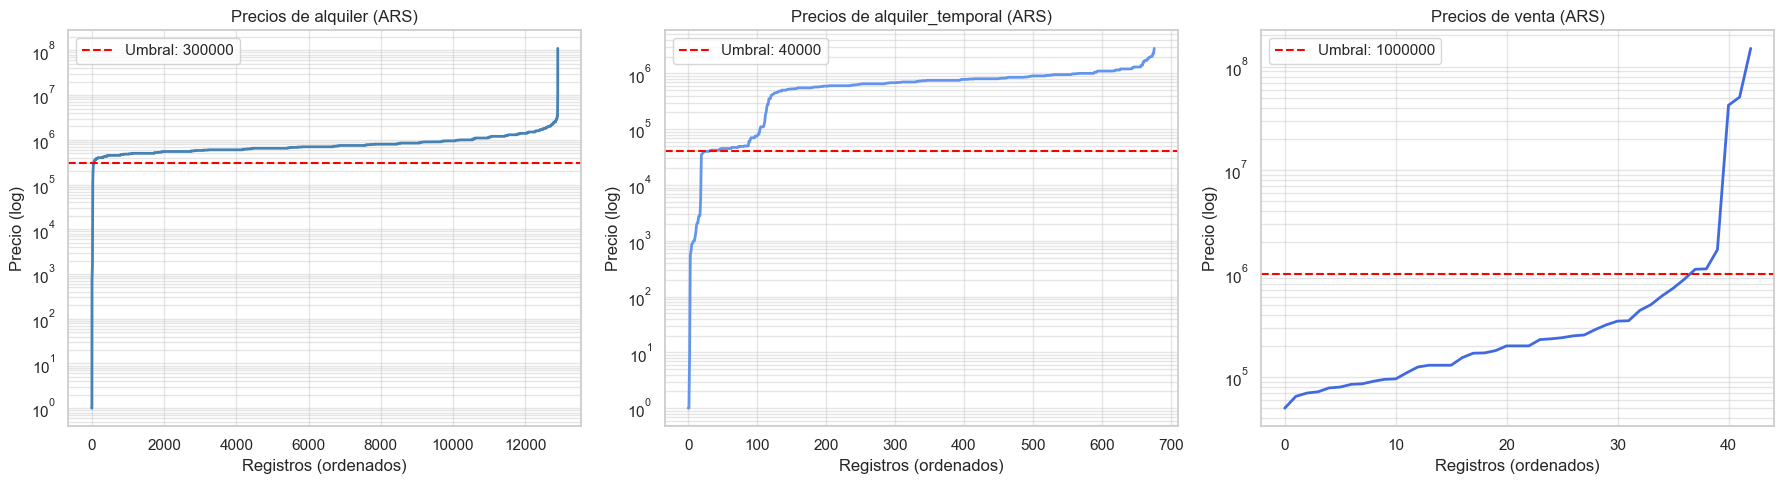

In [268]:
import matplotlib.pyplot as plt

ops = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 300000, 'alquiler_temporal': 40000, 'venta': 1000000}
colores = ['steelblue', 'cornflowerblue', 'royalblue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, op, color in zip(axes, ops, colores):
    subset = df_final[
        (df_final['moneda'] == 'ars') & (df_final['operacion'] == op)
    ]['precio'].dropna().sort_values().reset_index(drop=True)
    
    if not subset.empty:
        ax.plot(subset.values, color=color, linewidth=2)
        umb = umbrales[op]
        ax.axhline(y=umb, color='red', linestyle='--', label=f'Umbral: {umb}')
        
        ax.set_title(f'Precios de {op} (ARS)')
        ax.set_yscale('log')
        ax.set_ylabel('Precio (log)')
        ax.set_xlabel('Registros (ordenados)')
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

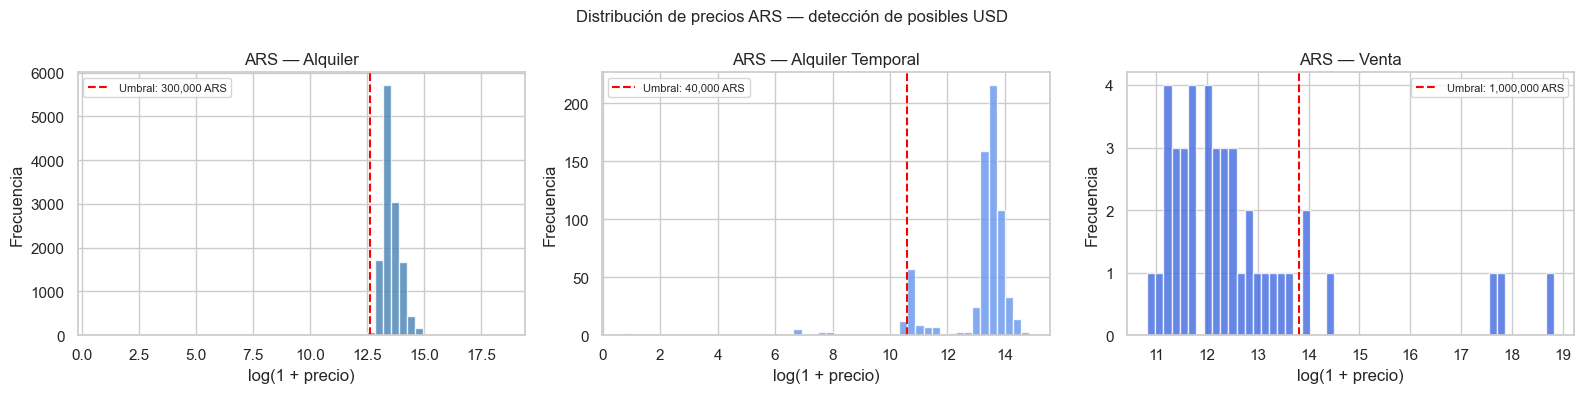

Registros ARS por debajo del umbral (candidatos a reclasificar):
  alquiler: 44 registros con precio < 300,000 ARS
  alquiler_temporal: 23 registros con precio < 40,000 ARS
  venta: 37 registros con precio < 1,000,000 ARS


In [269]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de precios ARS — detección de posibles USD', fontsize=12)

ops      = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 300_000, 'alquiler_temporal': 40_000, 'venta': 1_000_000}
#umbrales = {'alquiler': 120_000, 'alquiler_temporal': 100_000, 'venta': 100_000}
colores  = ['steelblue', 'cornflowerblue', 'royalblue']

for ax, op, color in zip(axes, ops, colores):
    subset = df_final[
        (df_final['moneda'] == 'ars') & (df_final['operacion'] == op)
    ]['precio'].dropna()

    ax.hist(np.log1p(subset), bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(
        np.log1p(umbrales[op]),
        color='red', linestyle='--',
        label=f'Umbral: {umbrales[op]:,} ARS'
    )
    ax.set_title(f"ARS — {op.replace('_', ' ').title()}")
    ax.set_xlabel('log(1 + precio)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Registros ARS por debajo del umbral (candidatos a reclasificar):")
for op, umbral in umbrales.items():
    n = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    ).sum()
    print(f"  {op}: {n} registros con precio < {umbral:,} ARS")

Un alquiler ARS menor a 300.000 pesos en 2026 es imposible para el mercado de CABA; probablemente esté expresado en dólares.

Un alquiler temporal ARS menor a 40.000 pesos en 2026 también está fuera del rango de mercado; probablemente esté en dólares.

Una venta ARS menor a 1.000.000 pesos en 2026 está igualmente fuera del rango de mercado; probablemente esté en dólares.

Por eso reclasificamos estos registros.

In [270]:
UMBRALES_IMPOSIBLES_ARS = {
    'alquiler':           300_000,
    'alquiler_temporal':  40_000,
    'venta':             1_000_000,
}

n_reclasificados = 0
for op, umbral in UMBRALES_IMPOSIBLES_ARS.items():
    mask = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    )
    n_reclasificados += mask.sum()
    df_final.loc[mask, 'moneda'] = 'usd'
    print(f"  Reclasificados '{op}': {mask.sum()} registros")

print(f"\nTotal reclasificados ARS → USD: {n_reclasificados}")

  Reclasificados 'alquiler': 44 registros
  Reclasificados 'alquiler_temporal': 23 registros
  Reclasificados 'venta': 37 registros

Total reclasificados ARS → USD: 104


Probamos algo similar para registros en dólares con valores demasiado altos, que probablemente están expresados en pesos.

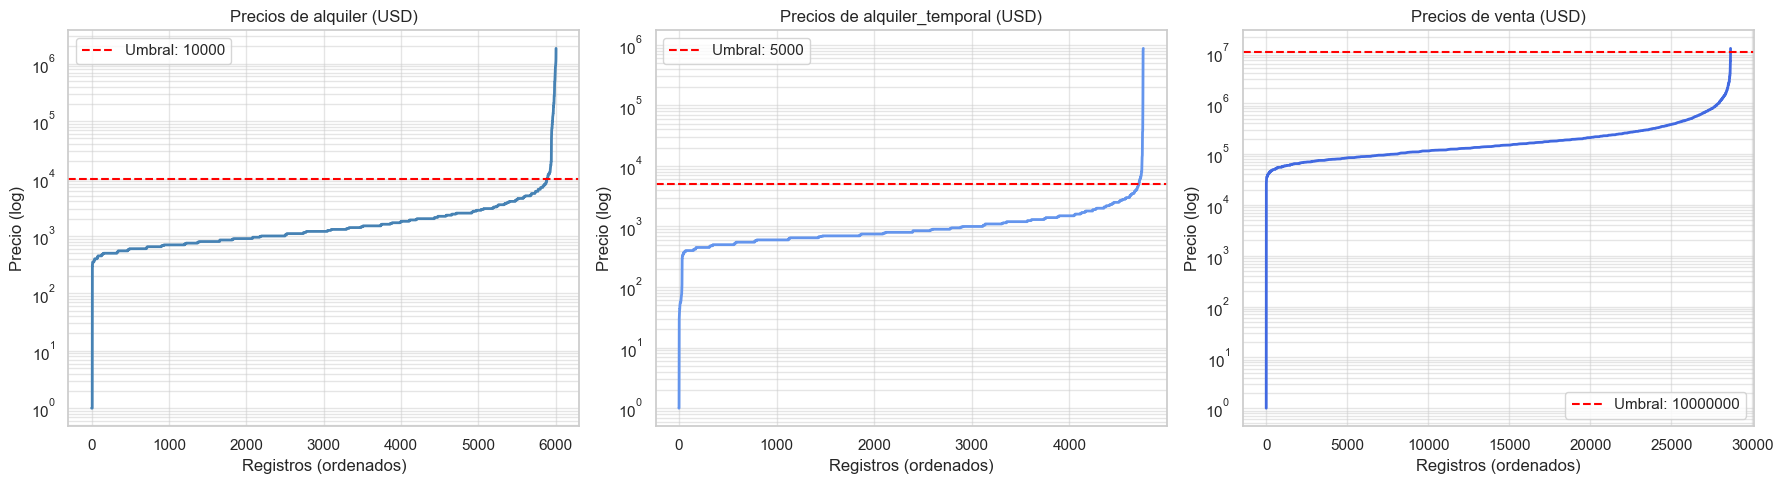

Registros USD por arriba del umbral (candidatos a reclasificar):
  alquiler: 108 registros con precio > 10,000 USD
  alquiler_temporal: 44 registros con precio > 5,000 USD
  venta: 1 registros con precio > 10,000,000 USD


In [271]:
import matplotlib.pyplot as plt

ops = ['alquiler', 'alquiler_temporal', 'venta']
# Definimos los umbrales en un diccionario
umbrales = {'alquiler': 10000, 'alquiler_temporal': 5000, 'venta': 10000000}
colores = ['steelblue', 'cornflowerblue', 'royalblue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, op, color in zip(axes, ops, colores):
    # .sort_values() para ver el codo
    subset = df_final[
        (df_final['moneda'] == 'usd') & (df_final['operacion'] == op)
    ]['precio'].dropna().sort_values().reset_index(drop=True)
    
    if not subset.empty:
        ax.plot(subset.values, color=color, linewidth=2)
        umb = umbrales[op]
        ax.axhline(y=umb, color='red', linestyle='--', label=f'Umbral: {umb}')
        
        ax.set_title(f'Precios de {op} (USD)')
        ax.set_yscale('log')
        ax.set_ylabel('Precio (log)')
        ax.set_xlabel('Registros (ordenados)')
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

print("Registros USD por arriba del umbral (candidatos a reclasificar):")
for op, umbral in umbrales.items():
    n = (
        (df_final['moneda'] == 'usd') &
        (df_final['operacion'] == op) &
        (df_final['precio'] > umbral)
    ).sum()
    print(f"  {op}: {n} registros con precio > {umbral:,} USD")

Definimos estos niveles como umbral de corte.

In [272]:
UMBRALES_IMPOSIBLES_USD = {
    'alquiler':           10_000,
    'alquiler_temporal':  5_000,
    'venta':             10_000_000,
}

n_reclasificados = 0
for op, umbral in UMBRALES_IMPOSIBLES_USD.items():
    mask = (
        (df_final['moneda'] == 'usd') &
        (df_final['operacion'] == op) &
        (df_final['precio'] > umbral)
    )
    n_reclasificados += mask.sum()
    df_final.loc[mask, 'moneda'] = 'ars'
    print(f"  Reclasificados '{op}': {mask.sum()} registros")

print(f"\nTotal reclasificados USD → ARS: {n_reclasificados}")

  Reclasificados 'alquiler': 108 registros
  Reclasificados 'alquiler_temporal': 44 registros
  Reclasificados 'venta': 1 registros

Total reclasificados USD → ARS: 153


## Paso 5 - Filtros absolutos

Eliminamos valores que son imposibles en cualquier contexto del mercado. Estos errores contaminarían el cálculo de percentiles si los dejamos adentro, por eso se aplican antes del paso de Winsorización.

En el paso anterior corregíamos la moneda asignada; en este paso eliminamos directamente los registros que no tienen sentido en ningún segmento.

In [273]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

PISO_USD_ALQUILER = 5        # USD/m2  imposible en cualquier barrio de CABA
PISO_USD_VENTA    = 400      # USD/m2  por debajo casi seguro error de moneda
PISO_ARS_ALQUILER = 3_000    # ARS/m2  mínimo razonable post-corrección
TECHO_USD_M2      = 25_000   # USD/m2  por encima error de tipeo

mask_error = (
    ((df_final['operacion'] == 'venta') &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_VENTA))
    |
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_ALQUILER))
    |
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'ars') &
     (df_final['precio_por_m2'] < PISO_ARS_ALQUILER))
    |
    (df_final['precio_por_m2'] > TECHO_USD_M2)
)

df_final = df_final[~mask_error].copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados por filtros absolutos de precio/m2: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados por filtros absolutos de precio/m2: 931
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     12964    12339         625
                  usd      5898     5881          17
alquiler_temporal ars       698      459         239
                  usd      4713     4674          39
venta             ars         7        4           3
                  usd     28647    28639           8


## Paso 6 - Percentiles adaptativos y Winsorización

Para los valores extremos que sí existen en el mercado (propiedades de lujo, PHs grandes), winsorizamos en lugar de eliminar. Reemplazamos el valor extremo por el límite del percentil, conservando el registro con todas sus variables para el modelo.

El percentil es adaptativo por segmento. Calculamos P1-P99 por operacion + moneda + barrio. Si el barrio tiene menos de 30 registros, usamos operacion + moneda como fallback para que el percentil sea estadísticamente válido.

Esto es importante porque Villa Lugano y Puerto Madero tienen rangos de precios completamente distintos. Un percentil global trataría como outlier propiedades perfectamente normales en cada uno.

In [274]:
N_MIN         = 30     # mínimo de registros para usar percentil por barrio
SEG_FINO      = ['operacion', 'moneda', 'barrio_oficial']
SEG_GRUESO    = ['operacion', 'moneda']
Q_LOW, Q_HIGH = 0.01, 0.99


def calcular_percentiles_adaptativos(df, col, seg_fino, seg_grueso, q_low, q_high, n_min):
    """Calcula percentiles por segmento fino; usa segmento grueso si n < n_min."""
    df = df.copy()

    stats_fino = (
        df.groupby(seg_fino)[col]
        .agg(
            n      = 'count',
            p_low  = lambda x: x.quantile(q_low),
            p_high = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )
    stats_grueso = (
        df.groupby(seg_grueso)[col]
        .agg(
            p_low_fb  = lambda x: x.quantile(q_low),
            p_high_fb = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )

    df = df.merge(stats_fino,   on=seg_fino,   how='left')
    df = df.merge(stats_grueso, on=seg_grueso, how='left')

    df['p_low']  = np.where(df['n'] >= n_min, df['p_low'],  df['p_low_fb'])
    df['p_high'] = np.where(df['n'] >= n_min, df['p_high'], df['p_high_fb'])

    return df.drop(columns=['n', 'p_low_fb', 'p_high_fb'])


df_final = calcular_percentiles_adaptativos(
    df_final, 'precio_por_m2',
    SEG_FINO, SEG_GRUESO,
    Q_LOW, Q_HIGH, N_MIN
)

# Guardamos el valor original para referencia y para el paso siguiente
df_final['precio_por_m2_original'] = df_final['precio_por_m2'].copy()

# Winsorizamos: reemplazamos por el límite en lugar de eliminar
mask_sup = df_final['precio_por_m2'] > df_final['p_high']
mask_inf = df_final['precio_por_m2'] < df_final['p_low']

df_final.loc[mask_sup, 'precio_por_m2'] = df_final.loc[mask_sup, 'p_high']
df_final.loc[mask_inf, 'precio_por_m2'] = df_final.loc[mask_inf, 'p_low']

print(f"Winsorizados por encima del P{Q_HIGH*100:.0f}: {mask_sup.sum():,}")
print(f"Winsorizados por debajo del P{Q_LOW*100:.0f}:  {mask_inf.sum():,}")
print(f"Total winsorizados: {(mask_sup | mask_inf).sum():,} ({(mask_sup | mask_inf).mean()*100:.1f}%)")

df_final = df_final.drop(columns=['p_low', 'p_high'])

Winsorizados por encima del P99: 507
Winsorizados por debajo del P1:  574
Total winsorizados: 1,081 (2.1%)


Dado que son pocos registros, podemos imputarles los valores del límite del percentil sin modificar notablemente la distribución de las variables.

## Paso 7 - Alquiler temporal ARS: precios por noche

El alquiler temporal en ARS mezcla precios por noche con precios por mes. Un departamento de 35 m² a 600 ARS corresponde a un precio por noche, equivalente a aproximadamente 18.000 ARS/m² mensual, que es perfectamente razonable.

Estos registros se eliminan directamente porque la razón es una unidad de tiempo incompatible con el resto del segmento. Sin saber si el precio es por noche, por semana o por mes, no hay forma de convertirlos de manera confiable.

In [275]:
conteo_antes = df_final.groupby(['operacion', 'moneda']).size().rename('antes')

UMBRAL_NOCHE_ARS = 2_000   # ARS/m2 implícito; por debajo precio por noche

mask_at_ars    = (
    (df_final['operacion'] == 'alquiler_temporal') &
    (df_final['moneda'] == 'ars')
)
mask_por_noche = mask_at_ars & (df_final['precio_por_m2_original'] < UMBRAL_NOCHE_ARS)

df_final = df_final[~mask_por_noche].copy()

conteo_despues = df_final.groupby(['operacion', 'moneda']).size().rename('despues')
log_df = pd.concat([conteo_antes, conteo_despues], axis=1).fillna(0).astype(int)
log_df['eliminados'] = log_df['antes'] - log_df['despues']
print(f'Eliminados alquiler temporal ARS por noche: {log_df["eliminados"].sum():,}')
print(log_df)

Eliminados alquiler temporal ARS por noche: 0
                          antes  despues  eliminados
operacion         moneda                            
alquiler          ars     12339    12339           0
                  usd      5881     5881           0
alquiler_temporal ars       459      459           0
                  usd      4674     4674           0
venta             ars         4        4           0
                  usd     28639    28639           0


## Paso 8 - Features de zona

Segmentamos los barrios en tres categorías que el modelo puede usar como variable. Puerto Madero funciona como un mercado aparte (con precios 2 a 3 veces la media), y los barrios populares tienen un piso de precios sistemáticamente más bajo.

En lugar de eliminar estos registros, los marcamos para tener en cuenta el efecto de zona de forma explícita.

In [276]:
BARRIOS_PREMIUM   = ['Puerto Madero']
BARRIOS_POPULARES = [
    'Villa Lugano', 'Villa Riachuelo', 'Villa Soldati',
    'Mataderos', 'Liniers', 'Parque Patricios'
]

df_final['segmento_zona'] = np.where(
    df_final['barrio_oficial'].isin(BARRIOS_PREMIUM),    'premium',
    np.where(
        df_final['barrio_oficial'].isin(BARRIOS_POPULARES), 'popular',
        'estandar'
    )
)

print("Distribución por segmento de zona:")
print(df_final['segmento_zona'].value_counts())

print("\nMediana precio/m² por zona (venta USD):")
print(
    df_final[df_final['operacion'] == 'venta']
    .groupby('segmento_zona')['precio_por_m2']
    .agg(['count', 'median', 'min', 'max'])
    .round(0)
)

Distribución por segmento de zona:
segmento_zona
estandar    48932
premium      1765
popular      1299
Name: count, dtype: int64

Mediana precio/m² por zona (venta USD):
               count  median   min    max
segmento_zona                            
estandar       27106   2,551   560  8,511
popular          962   1,851   645  3,731
premium          575   5,667 3,366 16,471


## Paso 9 - Consolidar segmentos con poco volumen

Algunos combos operacion + moneda + segmento_zona quedaron con muy pocos registros (por ejemplo, alquiler USD popular con n=4). 

Llevamos los segmentos pequeños a estandar para tratarlos junto con el grupo mayoritario.

In [277]:
N_MIN_SEG = 30

conteo = df_final.groupby(
    ['operacion', 'moneda', 'segmento_zona']
)['precio_por_m2'].transform('count')

df_final['segmento_zona_modelo'] = np.where(
    conteo < N_MIN_SEG,
    'estandar',
    df_final['segmento_zona']
)

print("Distribución final segmento_zona_modelo:")
print(
    df_final.groupby(['operacion', 'moneda', 'segmento_zona_modelo'])
    .size()
    .to_frame('n')
)

Distribución final segmento_zona_modelo:
                                                   n
operacion         moneda segmento_zona_modelo       
alquiler          ars    estandar              12013
                         popular                 326
                  usd    estandar               4949
                         premium                 932
alquiler_temporal ars    estandar                459
                  usd    estandar               4425
                         premium                 249
venta             ars    estandar                  4
                  usd    estandar              27103
                         popular                 962
                         premium                 574


## Paso 10 - Transformación logarítmica

Los precios inmobiliarios tienen distribución log-normal. La diferencia relativa entre 50.000 y 100.000 USD es equivalente a la diferencia entre 200.000 y 400.000 USD. El logaritmo captura esta relación y estabiliza la varianza.

Usamos log1p(x) = log(1 + x) en lugar de log(x) porque es numéricamente estable para valores cercanos a 0 y es invertible con expm1() para recuperar la escala original.

In [278]:
df_final['log_precio']    = np.log1p(df_final['precio'])
df_final['log_m2']        = np.log1p(df_final['m2_total'])
df_final['log_precio_m2'] = np.log1p(df_final['precio_por_m2'])

print("Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2")

Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2


## Paso 11 - Reporte y validación final

Verificamos que no hayan quedado NaN ni infinitos en las variables clave, y revisamos que los rangos por segmento sean coherentes con el mercado.

Sobre el gráfico: los puntos fuera de los bigotes del boxplot son normales. Seaborn marca como outlier cualquier punto más allá de 1.5×IQR, que es un criterio más estricto que nuestro P1-P99. Son los extremos reales del mercado dentro del rango que definimos como válido.

DATASET FINAL: 51,996 registros
OK — sin NaN ni infinitos en variables clave

Distribución por segmento:
                              n     p5  mediana    p95
operacion         moneda                              
alquiler          ars     12339 11,333   16,731 23,118
                  usd      5881     11       19     35
alquiler_temporal ars       459 11,458   18,750 24,643
                  usd      4674     10       18     33
venta             ars         4  3,632    4,271  5,708
                  usd     28639  1,378    2,551  4,979


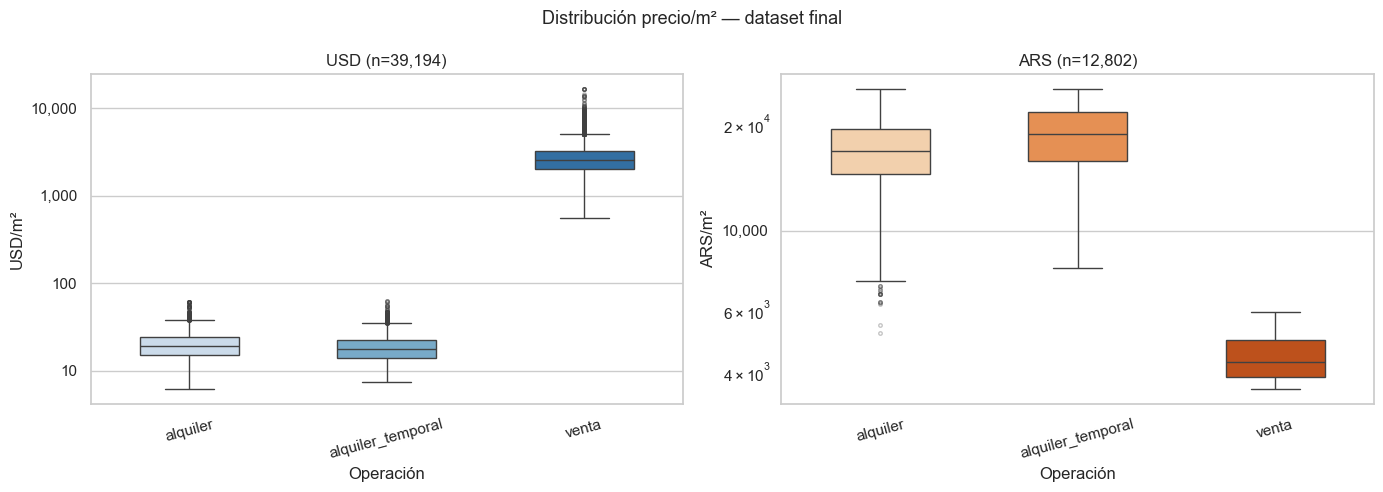

In [279]:
print("=" * 55)
print(f"DATASET FINAL: {len(df_final):,} registros")
print("=" * 55)

# Verificamos que no queden NaN ni infinitos en variables clave
vars_clave = ['precio', 'm2_total', 'precio_por_m2',
              'log_precio', 'log_m2', 'log_precio_m2']
nans = df_final[vars_clave].isna().sum()
infs = (df_final[vars_clave] == np.inf).sum()
assert nans.sum() == 0, f"Hay NaN:\n{nans[nans > 0]}"
assert infs.sum() == 0, f"Hay infinitos:\n{infs[infs > 0]}"
print("OK — sin NaN ni infinitos en variables clave")

# Distribución por segmento
print("\nDistribución por segmento:")
resumen = (
    df_final
    .groupby(['operacion', 'moneda'])['precio_por_m2']
    .agg(
        n       = 'count',
        p5      = lambda x: x.quantile(0.05),
        mediana = 'median',
        p95     = lambda x: x.quantile(0.95)
    )
    .round(0)
)
print(resumen)

# Graficamos con escala logarítmica en el eje Y para legibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución precio/m² — dataset final', fontsize=13)

for ax, (moneda, palette) in zip(axes, [('usd', 'Blues'), ('ars', 'Oranges')]):
    datos = df_final[df_final['moneda'] == moneda]
    sns.boxplot(
        x='operacion', y='precio_por_m2',
        data=datos, ax=ax,
        palette=palette, width=0.5,
        flierprops=dict(marker='.', markersize=5, alpha=0.3)
    )
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_title(f'{moneda.upper()} (n={len(datos):,})')
    ax.set_xlabel('Operación')
    ax.set_ylabel(f'{moneda.upper()}/m²')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

El valor bajo de los departamentos en venta en ARS sospechamos que se debe a la poca cantidad de registros (40) y al tipo de inmueble que se oferta en pesos, que suelen ser propiedades deterioradas en remate.

## Interpretación de outliers

Finalmente, podemos decir que la presencia de valores extremos resulta esperable dentro del mercado inmobiliario, especialmente en segmentos de lujo o propiedades corporativas.

Sin embargo, también se detectaron inconsistencias atribuibles a errores de carga, diferencias monetarias o publicaciones incompletas. Por ello, se aplicaron técnicas de filtrado y winsorización buscando preservar propiedades genuinamente exclusivas sin distorsionar las métricas generales del mercado.

Este enfoque permite mantener representatividad estadística sin eliminar segmentos relevantes del negocio inmobiliario.

# 9. EDA - Análisis Univariado

Estadísticos de resumen robustos para las variables numéricas clave.

In [280]:
from scipy.stats import skew, kurtosis

variables_num = ['precio', 'm2_total', 'ambientes', 'dormitorios', 'baños', 'antiguedad_años']
variables_presentes = [v for v in variables_num if v in df_final.columns]

resumen = []
for var in variables_presentes:
    serie = df_final[var].dropna()
    resumen.append({
        'variable': var,
        'n': len(serie),
        'media': serie.mean(),
        'mediana': serie.median(),
        'desvio': serie.std(),
        'asimetria': skew(serie),
        'curtosis': kurtosis(serie),
        'p5': serie.quantile(0.05),
        'p25': serie.quantile(0.25),
        'p75': serie.quantile(0.75),
        'p95': serie.quantile(0.95),
    })

pd.DataFrame(resumen).set_index('variable').round(2)

,n,media,mediana,desvio,asimetria,curtosis,p5,p25,p75,p95
variable,,,,,,,,,,
precio,51996,"328,892","155,000","426,453",4,44,700,"69,000","550,000","1,100,000"
m2_total,51996,70,52,57,7,233,28,38,80,175
ambientes,51996,2,2,1,2,14,1,1,3,4
dormitorios,51996,2,1,1,2,14,1,1,2,3
baños,51996,1,1,1,3,12,1,1,1,3
antiguedad_años,51996,26,20,19,1,0,0,10,40,60


El inmueble mediano tiene aproximadamente 52 m², 2 ambientes, 1 dormitorio, 1 baño y 25 años de antigüedad. La media de superficie total es mayor, cercana a 70 m², lo que sugiere la presencia de propiedades grandes que empujan el promedio hacia arriba.

In [281]:
# Prevalencia de atributos en el dataset
bool_features = ['cochera', 'aire_acond', 'luminoso', 'balcon_aterrazado',
                  'losa_central', 'seguridad', 'apto_credito']
bool_en_df = [c for c in bool_features if c in df_final.columns]

prevalencia = pd.DataFrame({
    'con_atributo': df_final[bool_en_df].sum(),
    'porcentaje (%)': (df_final[bool_en_df].mean() * 100).round(1)
}).sort_values('porcentaje (%)', ascending=False)
print("Prevalencia de atributos en el dataset:")
print(prevalencia)

Prevalencia de atributos en el dataset:
                   con_atributo  porcentaje (%)
luminoso                  31231              60
aire_acond                16025              31
cochera                   15127              29
seguridad                 11285              22
losa_central               5182              10
balcon_aterrazado          4842               9
apto_credito               3842               7


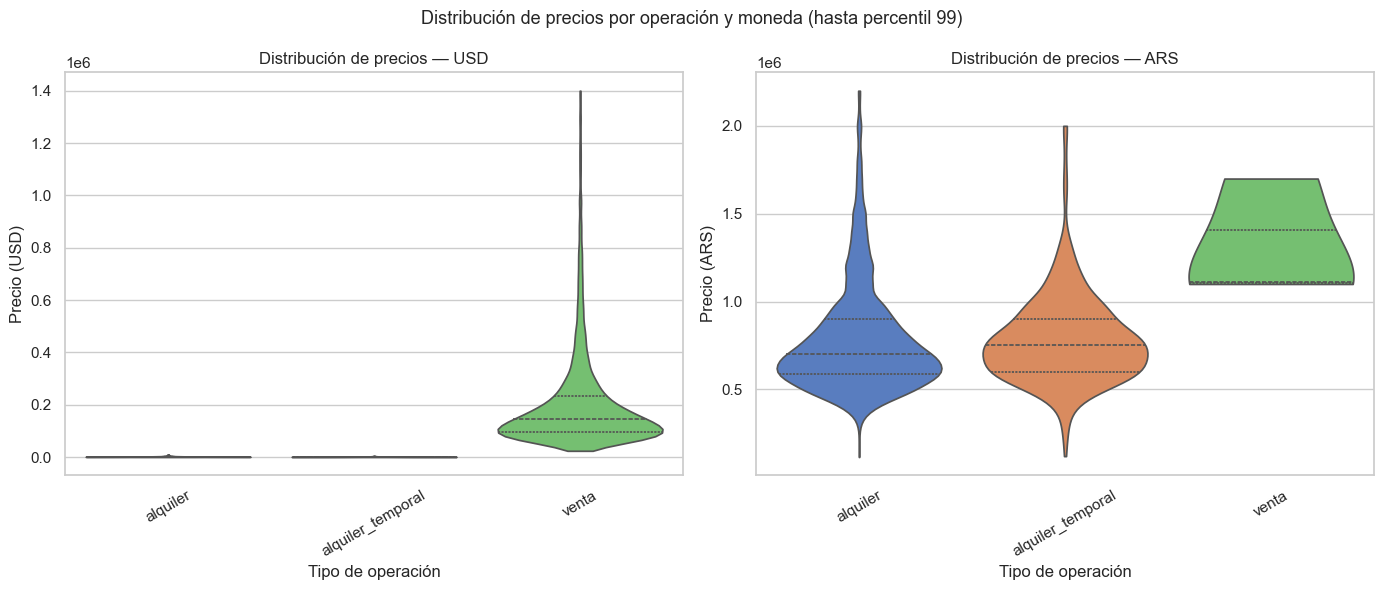

In [282]:
# Violin plot de precio por operación (separado por moneda)
# Usamos el percentil 99 para limitar el eje y y que los outliers no distorsionen la visibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, moneda in zip(axes, ['usd', 'ars']):
    subset = df_final[
        df_final['moneda'] == moneda
    ][['operacion', 'precio']].dropna()
    
    # L?mite por percentil 99 para cada segmento
    p99 = subset['precio'].quantile(0.99)
    subset = subset[subset['precio'] <= p99]
    
    sns.violinplot(data=subset, x='operacion', y='precio', ax=ax,
                   palette='muted', inner='quartile', cut=0)
    ax.set_title(f'Distribución de precios — {moneda.upper()}', fontsize=12)
    ax.set_xlabel('Tipo de operación')
    ax.set_ylabel(f'Precio ({moneda.upper()})')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Distribución de precios por operación y moneda (hasta percentil 99)', fontsize=13)
plt.tight_layout()
plt.show()

In [283]:
# Frecuencias de variables categóricas clave
categoricas = ['operacion', 'moneda', 'barrio_oficial', 'segmento_zona', 'sitio']

for col in categoricas:
    if col not in df_final.columns:
        continue

    freq = df_final[col].value_counts().reset_index()
    freq.columns = [col, 'cantidad']
    freq['porcentaje (%)'] = (freq['cantidad'] / len(df_final) * 100).round(1)

    print(f"\n{'='*50}")
    print(f"Variable: {col} — {df_final[col].nunique()} categorías únicas")
    print(freq.to_string(index=False))


Variable: operacion — 3 categorías únicas
        operacion  cantidad  porcentaje (%)
            venta     28643              55
         alquiler     18220              35
alquiler_temporal      5133              10

Variable: moneda — 2 categorías únicas
moneda  cantidad  porcentaje (%)
   usd     39194              75
   ars     12802              25

Variable: barrio_oficial — 48 categorías únicas
   barrio_oficial  cantidad  porcentaje (%)
          Palermo      9459              18
         Recoleta      5774              11
         Belgrano      4737               9
        Caballito      3662               7
          Almagro      2183               4
    Villa Urquiza      2126               4
      San Nicolas      1900               4
            Nuñez      1881               4
    Puerto Madero      1765               3
        Balvanera      1655               3
     Villa Crespo      1557               3
           Flores      1527               3
        San Telmo    

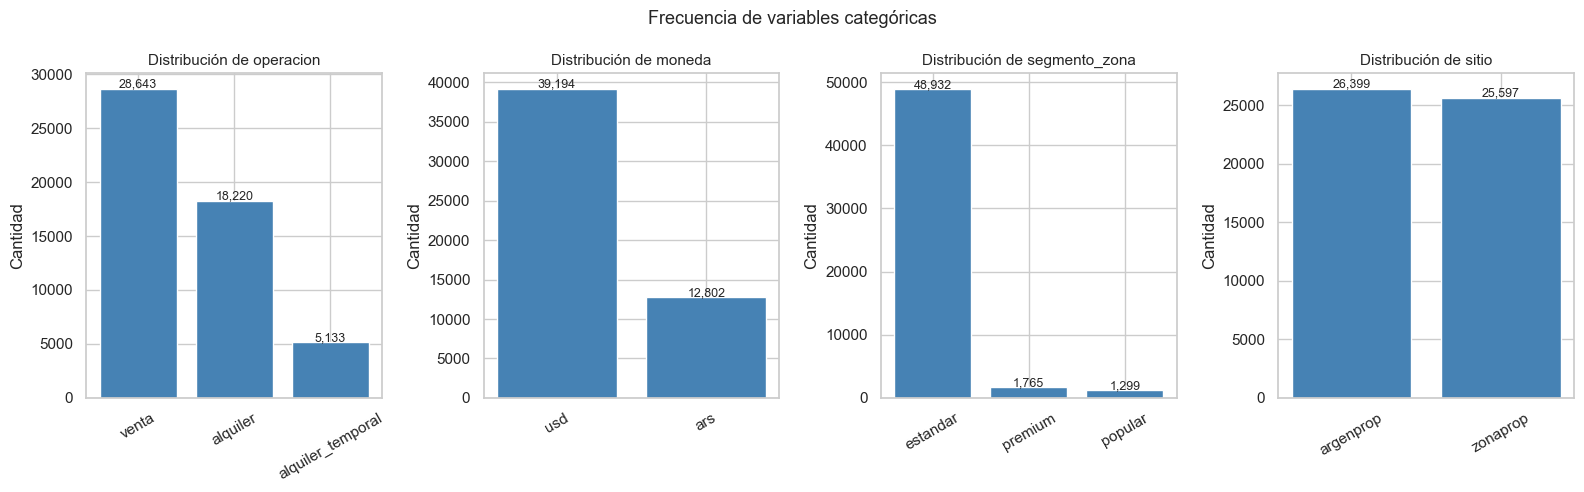

In [284]:
# Gráfico de frecuencias para las variables con pocas categorías
cols_grafico = ['operacion', 'moneda', 'segmento_zona', 'sitio']

fig, axes = plt.subplots(1, len(cols_grafico), figsize=(16, 5))

for ax, col in zip(axes, cols_grafico):
    if col not in df_final.columns:
        ax.set_visible(False)
        continue
    freq = df_final[col].value_counts()
    ax.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución de {col}', fontsize=11)
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(freq.values):
        ax.text(i, v + len(df_final)*0.003, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Frecuencia de variables categóricas', fontsize=13)
plt.tight_layout()
plt.show()

Podemos ver que hay diferencias en la frecuencia de cada categoria, habiendo en casi todas grupos claramente dominantes. La excepción es el sitio, ya que scrapeamos una cantidad similar de registros en cada uno.

# 10. EDA - Análisis Bivariado y Multivariado

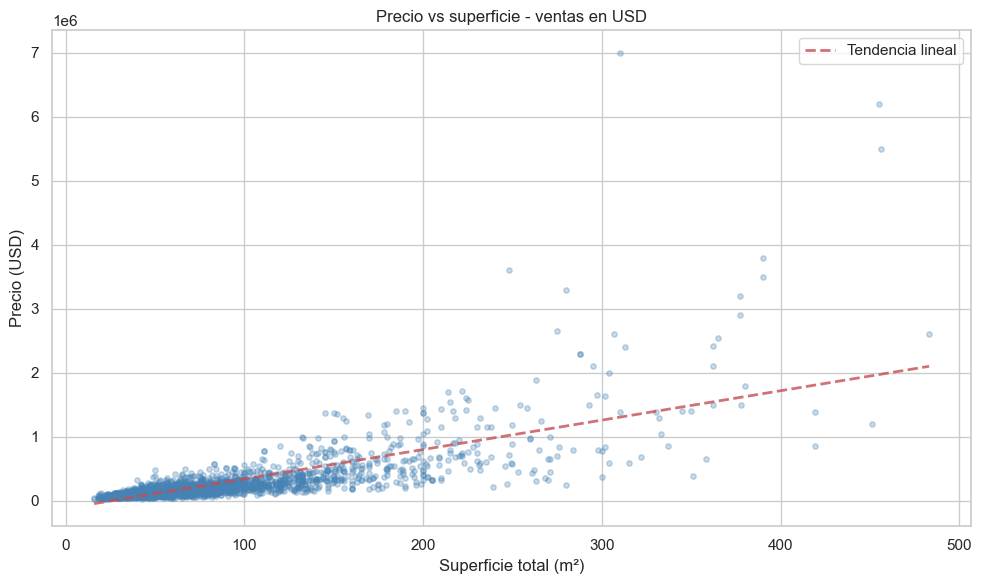

In [285]:
# Scatter de precio vs m2_total para ventas en USD
# Usamos una muestra aleatoria para evitar sobrecarga visual
subset_scatter = df_final[
    (df_final['moneda'] == 'usd') & 
    (df_final['operacion'] == 'venta') &
    df_final['precio'].notna() &
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 5) &
    (df_final['m2_total'] < 500)  # filtramos propiedades con m2 absurdo
].sample(min(3000, len(df_final)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    subset_scatter['m2_total'], 
    subset_scatter['precio'],
    alpha=0.3, s=15, color='steelblue'
)

# Línea de tendencia con regresión simple para orientación visual
z = np.polyfit(subset_scatter['m2_total'].dropna(), 
               subset_scatter['precio'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(subset_scatter['m2_total'].min(), subset_scatter['m2_total'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label='Tendencia lineal')

ax.set_xlabel('Superficie total (m²)')
ax.set_ylabel('Precio (USD)')
ax.set_title('Precio vs superficie - ventas en USD')
ax.legend()
plt.tight_layout()
plt.show()

Vemos una relación que parece lineal entre el precio y la superficie total del inmueble, más marcada en superficies menores a 100 m². En propiedades más grandes, el precio responde más a factores de lujo y ubicación que a los metros cuadrados por sí solos.

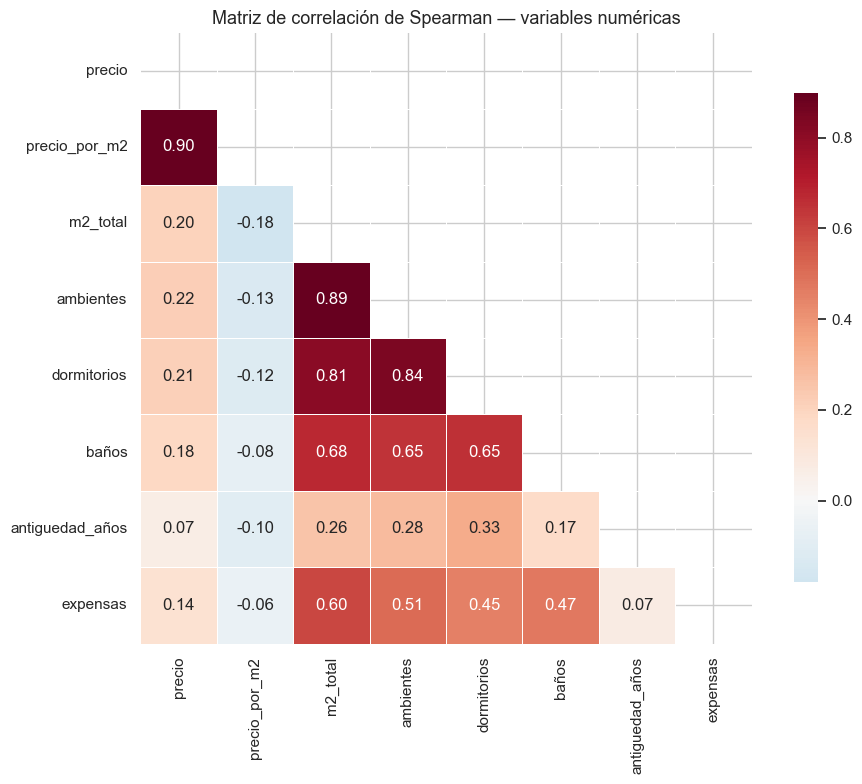

In [286]:
# Heatmap de correlación entre variables numéricas clave
# Usamos Spearman porque las distribuciones de precio no son normales
vars_correlacion = [v for v in ['precio', 'precio_por_m2', 'm2_total', 
                                 'ambientes', 'dormitorios', 'baños', 
                                 'antiguedad_años', 'expensas'] 
                    if v in df_final.columns]

corr_matrix = df_final[vars_correlacion].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación de Spearman — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

Las variables 'ambientes' y 'm2_total' presentan una correlación muy alta, al igual que 'ambientes' y 'dormitorios'. Tiene sentido: cuantos más ambientes, mayor la propiedad; y cuantos más dormitorios, más ambientes.

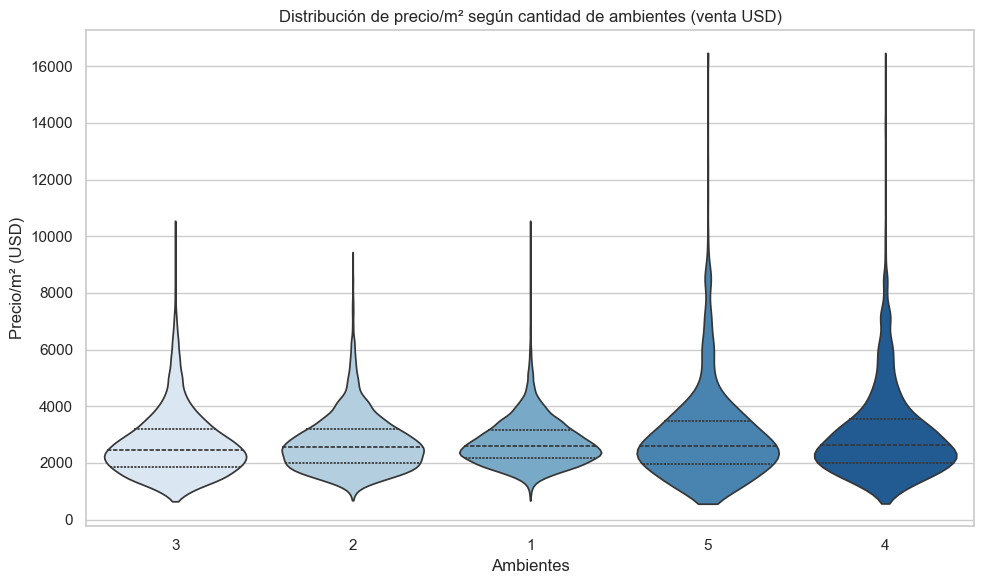

In [287]:
# Precio/m² por cantidad de ambientes (ventas USD)
# Muestra si el precio por m² cambia según el tamaño del departamento
subset_amb = df_final[
    (df_final['operacion'] == 'venta') &
    (df_final['moneda'] == 'usd') &
    df_final['ambientes'].notna() &
    df_final['precio_por_m2'].notna() &
    df_final['ambientes'].between(1, 5)  # excluimos outliers de ambientes
].copy()
subset_amb['ambientes'] = subset_amb['ambientes'].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=subset_amb, x='ambientes', y='precio_por_m2',
               palette='Blues', inner='quartile', cut=0, ax=ax)
ax.set_title('Distribución de precio/m² según cantidad de ambientes (venta USD)', fontsize=12)
ax.set_xlabel('Ambientes')
ax.set_ylabel('Precio/m² (USD)')
plt.tight_layout()
plt.show()

Vemos que las medianas tienden a mantenerse constantes, independientemente de la cantidad de ambientes que tenga el departamento. Sin embargo, los departamentos con mas ambientes (4 o 5) alcanzan valores de precio_por_m2 mucho mas altos que los demas.

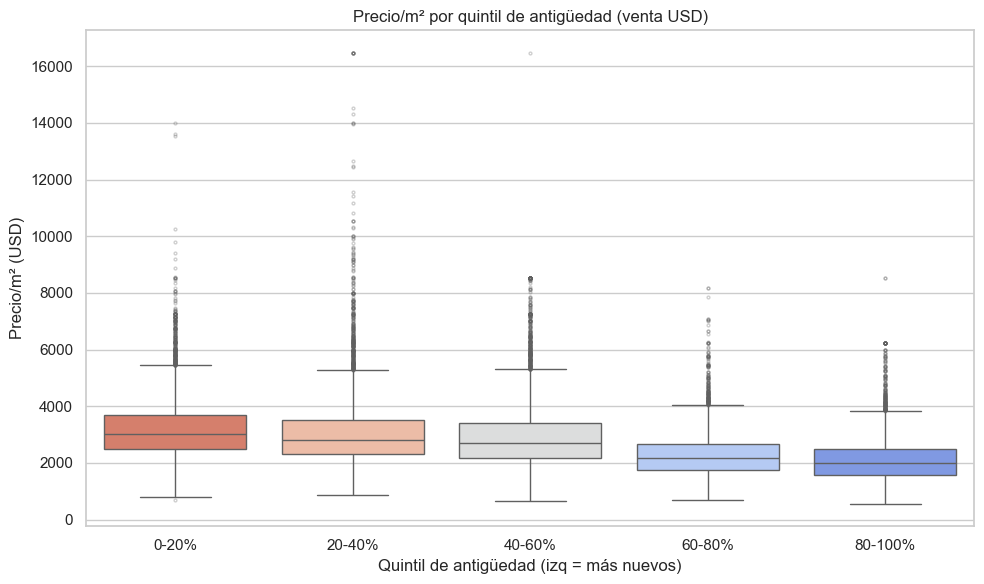

In [288]:
# Precio/m² por decil de antigüedad (ventas USD)
# Muestra si la antigüedad impacta en el precio por m²
subset_antig = df_final[
    (df_final['operacion'] == 'venta') &
    (df_final['moneda'] == 'usd') &
    df_final['antiguedad_años'].notna() &
    df_final['precio_por_m2'].notna()
].copy()

subset_antig['decil_antiguedad'] = pd.qcut(
    subset_antig['antiguedad_años'], q=5,
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=subset_antig, x='decil_antiguedad', y='precio_por_m2',
            palette='coolwarm_r', ax=ax,
            flierprops=dict(marker='.', markersize=4, alpha=0.3))
ax.set_title('Precio/m² por quintil de antigüedad (venta USD)', fontsize=12)
ax.set_xlabel('Quintil de antigüedad (izq = más nuevos)')
ax.set_ylabel('Precio/m² (USD)')
plt.tight_layout()
plt.show()

Nuevamente, no parece haber diferencias tan significativas segun la antigüedad del departamento. Lo que sí podemos ver, una leve baja en el precio_por_m2 en los departamentos más viejos. Pero esta categoría reune departamentos que tienen un componente historico que puede elevar el precio, y departamentos que pueden estar deteriorados.

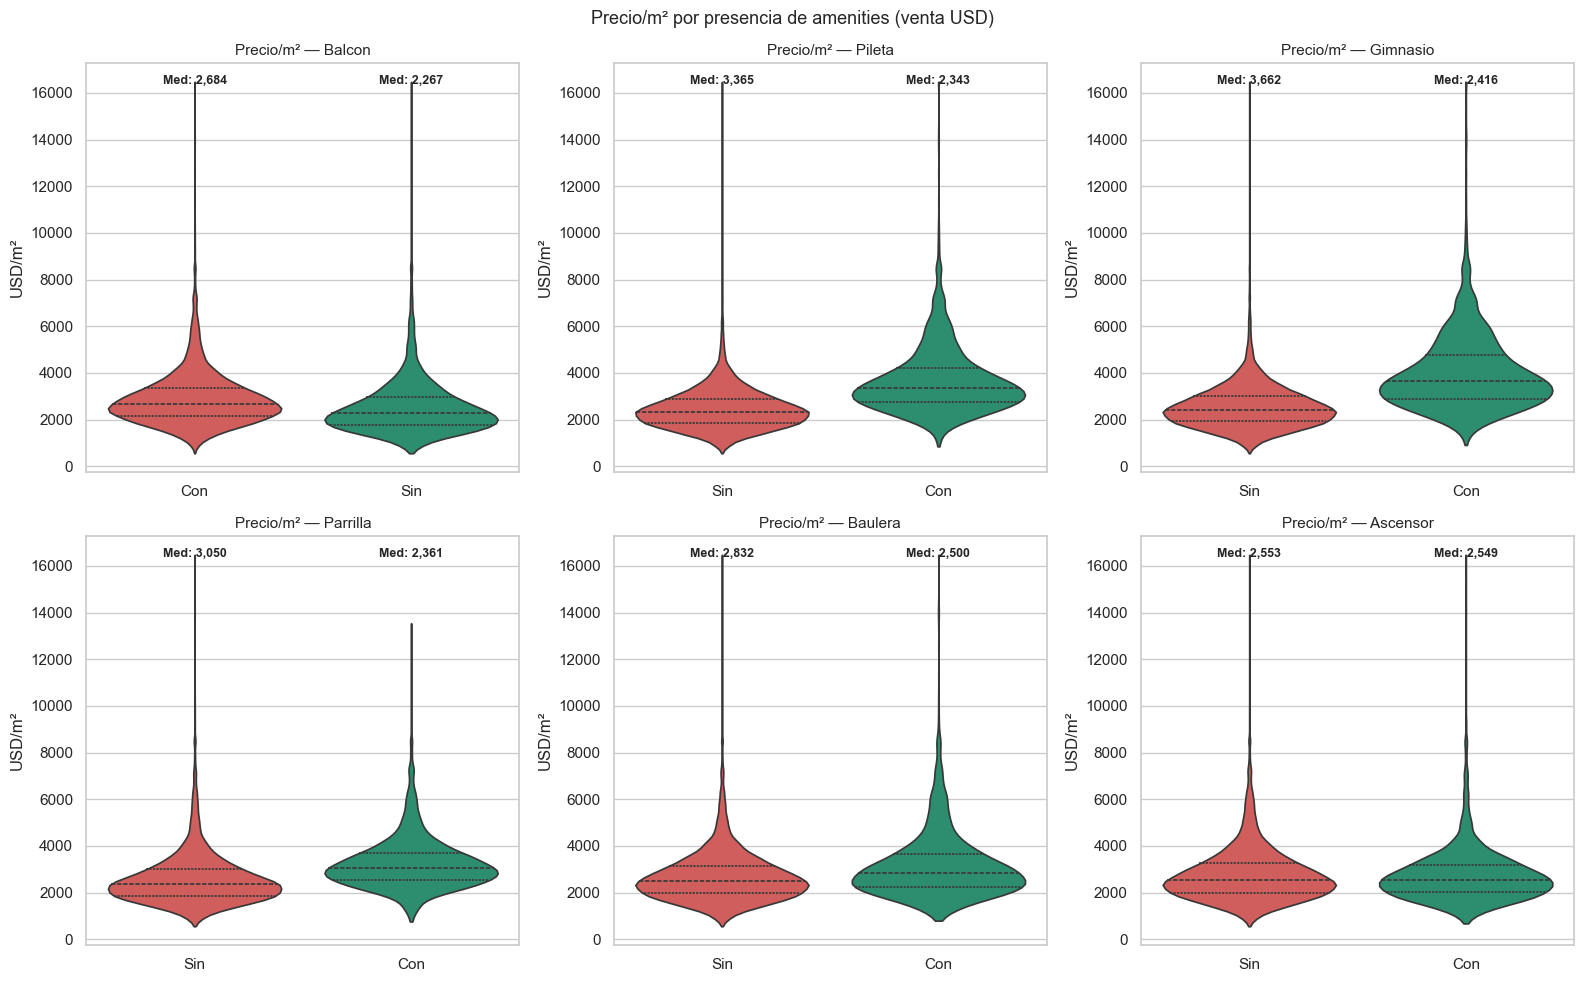

In [289]:
# Precio/m² con vs sin amenity clave: balcón, pileta, gimnasio, parrilla
# Análisis bivariado central para la Hipótesis 3
amenities_analisis = ['balcon', 'pileta', 'gimnasio', 'parrilla', 'baulera', 'ascensor']
amenities_presentes = [c for c in amenities_analisis if c in df_final.columns]

subset_venta = df_final[
    (df_final['operacion'] == 'venta') &
    (df_final['moneda'] == 'usd') &
    df_final['precio_por_m2'].notna()
].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, amenity in zip(axes, amenities_presentes):
    data_plot = subset_venta[[amenity, 'precio_por_m2']].copy()
    data_plot[amenity] = data_plot[amenity].map({1: 'Con', 0: 'Sin'})
    sns.violinplot(data=data_plot, x=amenity, y='precio_por_m2',
                   palette=['#E24B4A', '#1D9E75'], inner='quartile', cut=0, ax=ax)
    
    # Medianas sobre el gráfico
    for val, label in [(1, 'Con'), (0, 'Sin')]:
        med = subset_venta[subset_venta[amenity] == val]['precio_por_m2'].median()
        ax.text([0, 1][val == 0], ax.get_ylim()[1] * 0.95,
                f'Med: {med:,.0f}', ha='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f'Precio/m² — {amenity.capitalize()}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('USD/m²')

# Ocultamos el subplot sobrante si hay menos de 6 amenities
for i in range(len(amenities_presentes), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Precio/m² por presencia de amenities (venta USD)', fontsize=13)
plt.tight_layout()
plt.show()

En este grafico, vemos que departamentos con amenities, tienen un nivel de precios algo superior a los que no tienen. Esta diferencia se ve especialmente en las variables pileta y gimnasio. Esto tiene sentido que le sume valor a una propiedad.

In [290]:
# Tabla de contingencia: tipo de operación × segmento de zona
# Muestra si la distribución de operaciones varía según la zona
tabla_op_zona = pd.crosstab(
    df_final['operacion'],
    df_final['segmento_zona'],
    margins=True,
    margins_name='Total'
)
tabla_op_zona_pct = pd.crosstab(
    df_final['operacion'],
    df_final['segmento_zona'],
    normalize='index'
).round(3) * 100

print("=== Tabla de contingencia: operación × segmento de zona ===")
print("\nCantidades absolutas:")
print(tabla_op_zona)
print("\nDistribución porcentual por operación (%):")
print(tabla_op_zona_pct.round(1))

=== Tabla de contingencia: operación × segmento de zona ===

Cantidades absolutas:
segmento_zona      estandar  popular  premium  Total
operacion                                           
alquiler              16950      330      940  18220
alquiler_temporal      4876        7      250   5133
venta                 27106      962      575  28643
Total                 48932     1299     1765  51996

Distribución porcentual por operación (%):
segmento_zona      estandar  popular  premium
operacion                                    
alquiler                 93        2        5
alquiler_temporal        95        0        5
venta                    95        3        2


Por la cantidad de datos que teniamos al construir la variable, podemos ver una clara diferencia en los porcentajes.

# 11. Análisis Geográfico

Ahora, analizaremos en particular una de las dimensiones que nos parece más importante: el barrio donde se ubica el departamento.

In [291]:
import requests
import geopandas as gpd

# Descargamos el GeoJSON oficial de barrios de la Ciudad de Buenos Aires desde datos abiertos
url_geojson = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"
geojson_barrios = requests.get(url_geojson).json()

nombres_geojson = {f["properties"]["nombre"] for f in geojson_barrios["features"]}

df_filtrado = df_final[df_final["barrio_oficial"].isin(nombres_geojson)]
conteo = df_filtrado.groupby("barrio_oficial").size().reset_index(name="cantidad")

nombres_df = set(conteo["barrio_oficial"])
print("Barrios sin coincidencia en el GeoJSON:", nombres_df - nombres_geojson)


Barrios sin coincidencia en el GeoJSON: set()


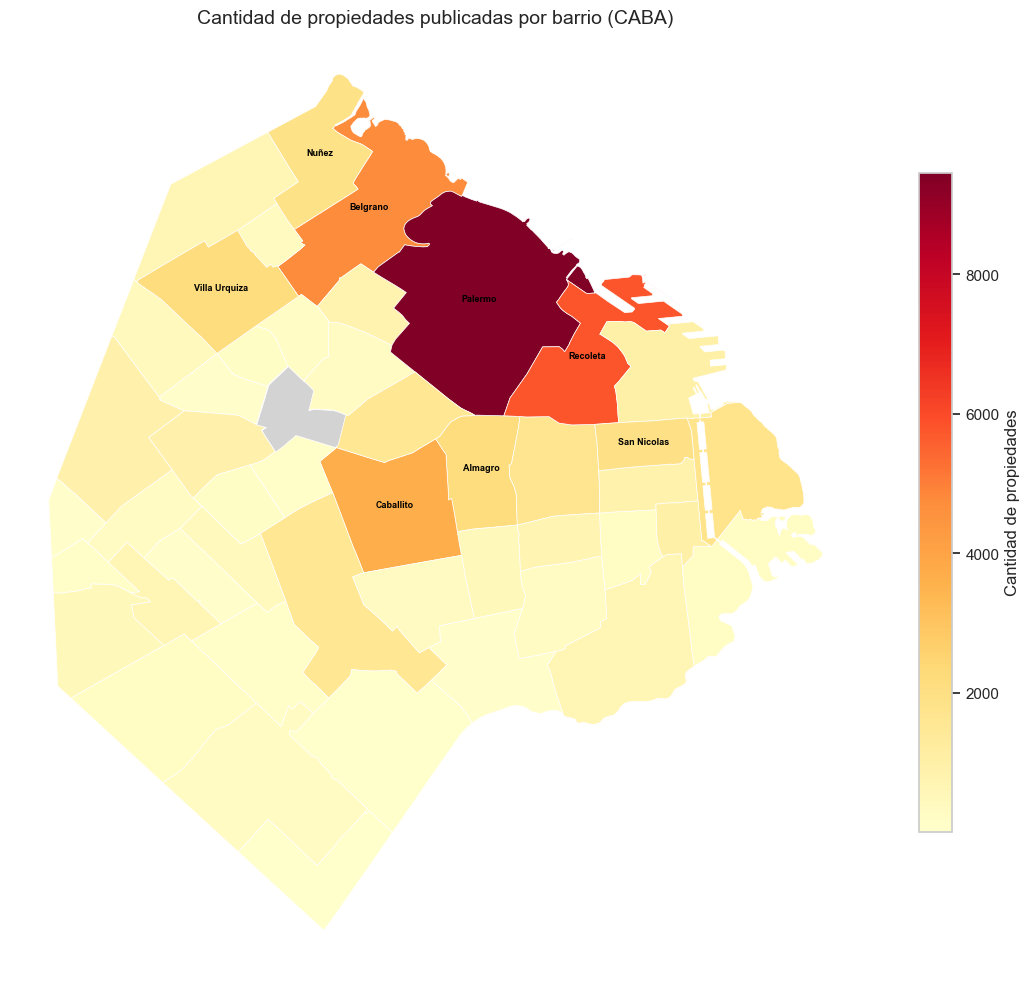

In [292]:
# Construimos el GeoDataFrame de barrios y lo mergeamos con el conteo de propiedades
gdf = gpd.GeoDataFrame.from_features(geojson_barrios["features"])
gdf = gdf.rename(columns={"nombre": "barrio_oficial"})
gdf = gdf.set_crs("EPSG:4326")

gdf_conteo = gdf.merge(conteo, on="barrio_oficial", how="left")

# --- Mapa: cantidad de propiedades por barrio ---
fig, ax = plt.subplots(figsize=(12, 10))

gdf_conteo.plot(
    column="cantidad",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Cantidad de propiedades", "shrink": 0.7},
    missing_kwds={"color": "lightgray", "label": "Sin datos"},
    ax=ax,
)

# Anotamos los top-8 barrios por cantidad
top_barrios = gdf_conteo.nlargest(8, "cantidad")
for _, row in top_barrios.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["barrio_oficial"],
        xy=(centroide.x, centroide.y),
        ha="center",
        fontsize=6.5,
        color="black",
        fontweight="bold",
    )

ax.set_title("Cantidad de propiedades publicadas por barrio (CABA)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


En el mapa vemos que Palermo, Belgrano, Recoleta y Caballito son los barrios con mayor representación en el dataset. Esto corresponde con la popularidad reciente general de estos barrios. 

A continuación presentamos mapas del precio mediano por barrio, separados por tipo de operación y moneda. Usamos la columna 'precio' (ya limpia) del DataFrame principal. Para venta calculamos también el precio mediano por m².

In [293]:
def graficar_mapa_precio(gdf_base, df_source, filtro_operacion, filtro_moneda,
                          columna_precio, titulo, etiqueta_leyenda,
                          cmap="Blues", top_n=8, fmt_precio="{:,.0f}"):
    """
    Genera un mapa coroplético de precio mediano por barrio usando geopandas + matplotlib.

    Parámetros
    ----------
    gdf_base           : GeoDataFrame con la geometría de los barrios (columna 'barrio_oficial')
    df_source          : DataFrame con columnas barrio_oficial, operacion, moneda y columna_precio
    filtro_operacion   : str, valor de la columna 'operacion' a filtrar
    filtro_moneda      : str, valor de la columna 'moneda' a filtrar
    columna_precio     : str, columna numérica a agregar con la mediana
    titulo             : str, título del mapa
    etiqueta_leyenda   : str, etiqueta de la barra de colores
    cmap               : str, colormap de matplotlib
    top_n              : int, cantidad de barrios a anotar
    fmt_precio         : str, formato para el texto de anotación
    """
    # Filtrado y cálculo de mediana por barrio
    mask = (
        (df_source["operacion"] == filtro_operacion)
        & (df_source["moneda"] == filtro_moneda)
        & df_source[columna_precio].notna()
        & (df_source[columna_precio] > 0)
        & df_source["barrio_oficial"].notna()
    )
    estadisticas = (
        df_source[mask]
        .groupby("barrio_oficial")[columna_precio]
        .median()
        .reset_index()
        .rename(columns={columna_precio: "precio_mediano"})
    )

    gdf_merge = gdf_base.merge(estadisticas, on="barrio_oficial", how="left")

    fig, ax = plt.subplots(figsize=(12, 10))

    gdf_merge.plot(
        column="precio_mediano",
        cmap=cmap,
        linewidth=0.5,
        edgecolor="white",
        legend=True,
        legend_kwds={"label": etiqueta_leyenda, "shrink": 0.7},
        missing_kwds={"color": "lightgray", "label": "Sin datos"},
        ax=ax,
    )

    # Anotamos los top-N barrios con mayor precio mediano
    top = gdf_merge.dropna(subset=["precio_mediano"]).nlargest(top_n, "precio_mediano")
    for _, row in top.iterrows():
        centroide = row.geometry.centroid
        ax.annotate(
            row["barrio_oficial"],
            xy=(centroide.x, centroide.y),
            ha="center",
            fontsize=6,
            color="black",
            fontweight="bold",
        )

    ax.set_title(titulo, fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


In [294]:
# df_geo contiene solo los registros con barrio_oficial válido para el análisis geoespacial
# m2_total y precio_por_m2 requieren que el parseo de detalles y descripción ya esté ejecutado
df_geo = df_filtrado.copy()

if "m2_total" in df_final.columns:
    df_geo["m2_total"] = df_final.loc[df_geo.index, "m2_total"]
    mask_m2 = df_geo["m2_total"].notna() & (df_geo["m2_total"] > 5) & df_geo["precio"].notna() & (df_geo["precio"] > 0)
    df_geo.loc[mask_m2, "precio_por_m2"] = df_geo.loc[mask_m2, "precio"] / df_geo.loc[mask_m2, "m2_total"]
    print(f"Registros con precio_por_m2 calculado: {mask_m2.sum():,}")
else:
    print("m2_total aún no disponible (ejecutar sección de parseo de detalles primero).")

print(f"Registros en df_geo: {len(df_geo):,}")
print(df_geo[["operacion", "moneda"]].value_counts())


Registros con precio_por_m2 calculado: 51,777
Registros en df_geo: 51,777
operacion          moneda
venta              usd       28506
alquiler           ars       12258
                   usd        5877
alquiler_temporal  usd        4674
                   ars         458
venta              ars           4
Name: count, dtype: int64


### Precio mediano de venta (USD) por barrio

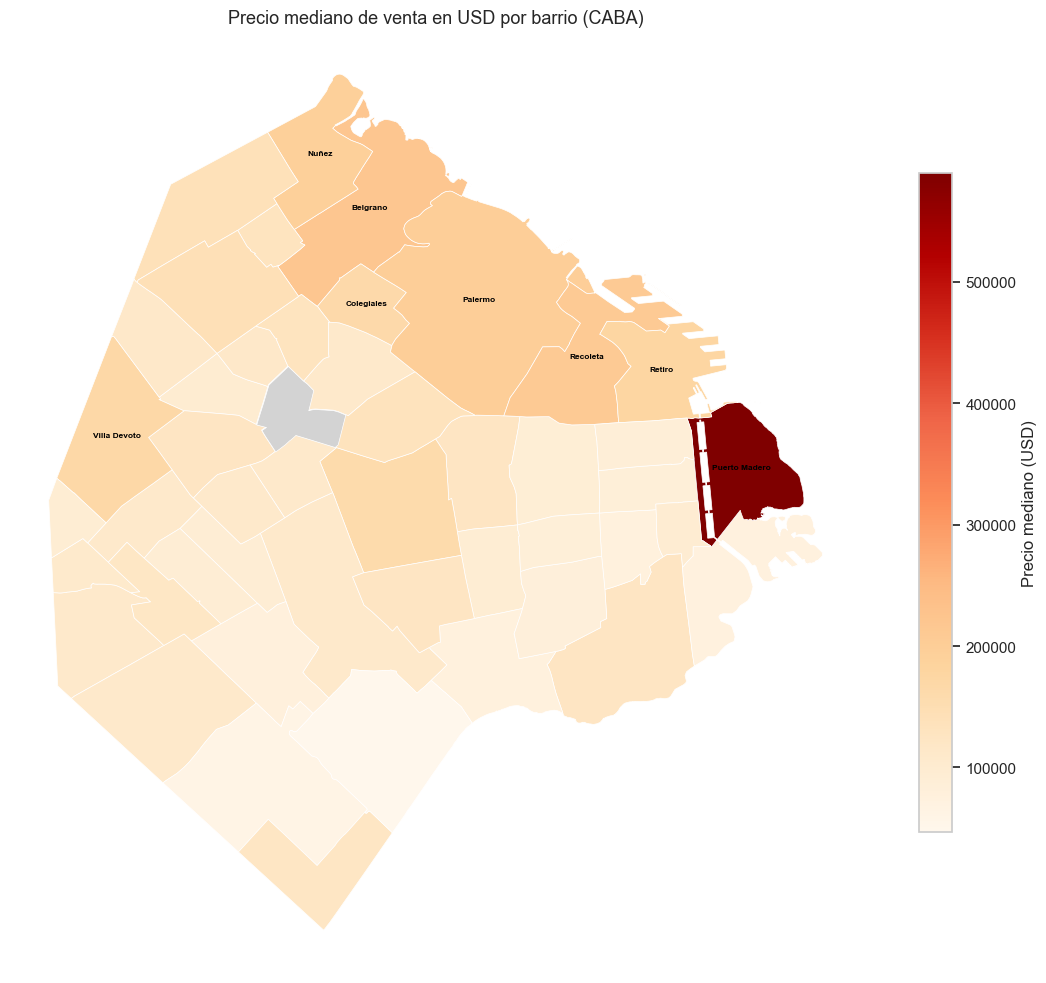

In [295]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="venta",
    filtro_moneda="usd",
    columna_precio="precio",
    titulo="Precio mediano de venta en USD por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (USD)",
    cmap="OrRd",
    top_n=8,
)


Esto corresponde con suposiciones de conocimiento general: Puerto Madero es un barrio de lujo cuyos precios tienen una diferencia importante con respecto a los demás barrios. Barrios muy demandados (Recoleta, Palermo, Belgrano, Núñez) le siguen. 

### Precio mediano de alquiler (ARS) por barrio

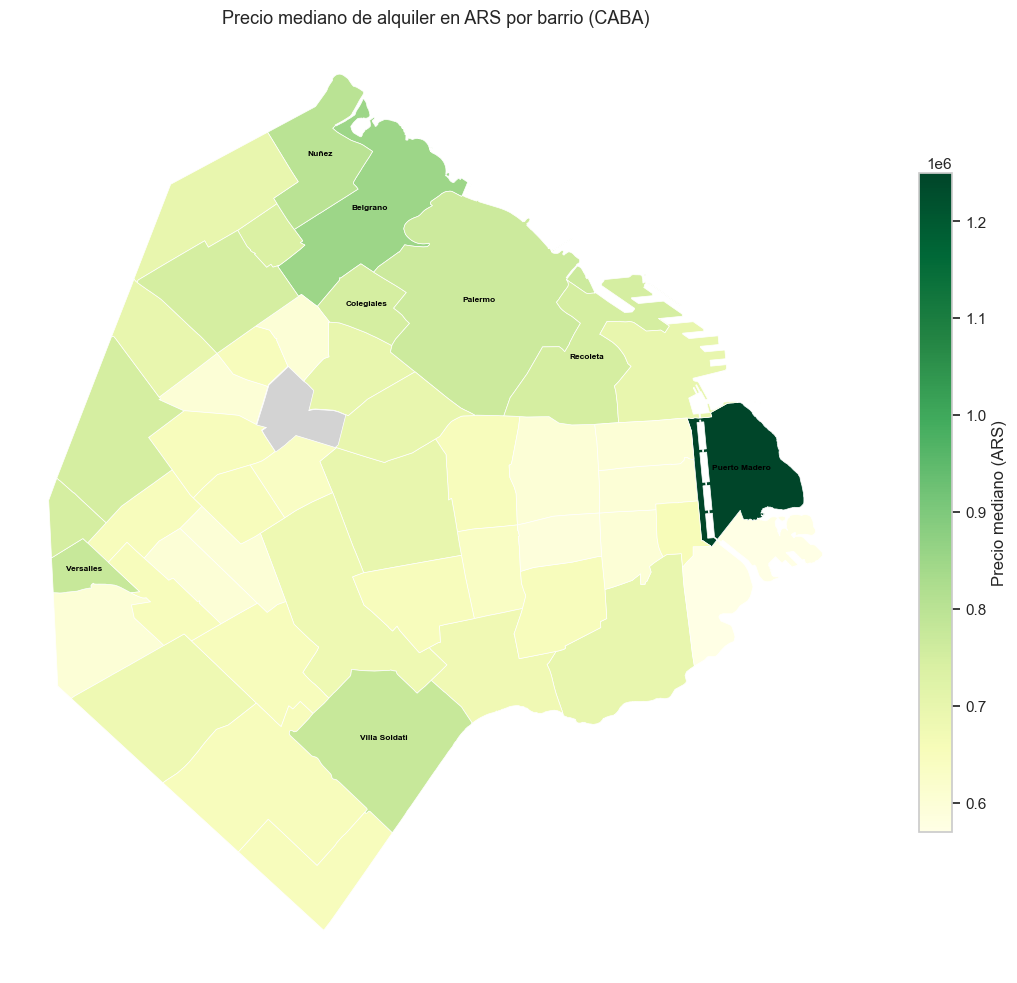

In [296]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="alquiler",
    filtro_moneda="ars",
    columna_precio="precio",
    titulo="Precio mediano de alquiler en ARS por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (ARS)",
    cmap="YlGn",
    top_n=8,
)


### Precio mediano por m² en venta (USD) por barrio

Este mapa muestra el precio mediano por metro cuadrado para propiedades en venta con precio en dólares. La columna 'm2_total' proviene del parseo de la columna 'detalles' (superficie total o cubierta). Solo incluimos propiedades con 'm2_total > 5 m²'.

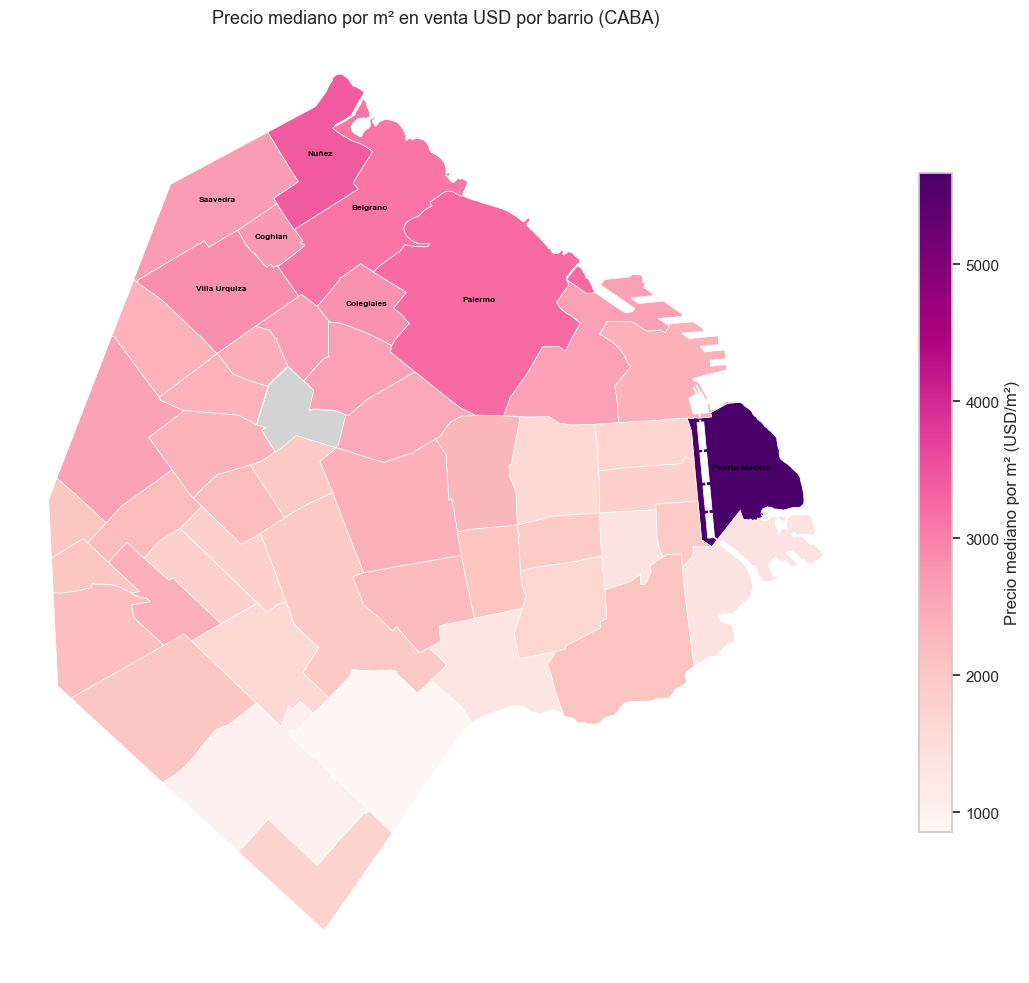

In [297]:
if "precio_por_m2" in df_geo.columns:
    graficar_mapa_precio(
        gdf_base=gdf,
        df_source=df_geo,
        filtro_operacion="venta",
        filtro_moneda="usd",
        columna_precio="precio_por_m2",
        titulo="Precio mediano por m² en venta USD por barrio (CABA)",
        etiqueta_leyenda="Precio mediano por m² (USD/m²)",
        cmap="RdPu",
        top_n=8,
    )
else:
    print("No se pudo generar el mapa: la columna 'precio_por_m2' no está disponible.")
    print("Asegurate de ejecutar la celda de parseo de 'detalles' antes de esta.")


En todos los mercados, barrios como Puerto Madero, Palermo, Recoleta y Belgrano mantienen los precios más altos. En este último gráfico destaca Núñez, el cual presenta una popularidad creciente recientemente. Cada vez hay más proyectos en este barrio (incluyendo el campus del ITBA mimso)ñ

In [298]:
tabla_barrio_operacion = (
    df_final.groupby(["barrio_oficial", "operacion"])
      .size()
      .unstack(fill_value=0)
)

tabla_barrio_operacion["Total_barrio"] = tabla_barrio_operacion.sum(axis=1)
tabla_barrio_operacion.loc["Total_operacion"] = tabla_barrio_operacion.sum(axis=0)

tabla_barrio_operacion

operacion,alquiler,alquiler_temporal,venta,Total_barrio
barrio_oficial,,,,
Agronomia,26,1,43,70
Almagro,709,211,1263,2183
Balvanera,566,83,1006,1655
Barracas,187,11,437,635
Belgrano,1508,416,2813,4737
Boedo,143,8,299,450
Caballito,1287,154,2221,3662
Chacarita,90,27,175,292
Coghlan,75,15,279,369


El barrio con menor cantidad de propiedades es Villa Riachuelo, con 5 registros. La operación con menor volumen es 'alquiler_temporal'. Esperamos que las conclusiones más robustas sean sobre los barrios con mayor presencia en el dataset, aunque 'alquiler_temporal', con más de 8.000 filas, permite obtener resultados sólidos para los tres tipos de operación.

## Segmentación territorial del mercado

Todo este análisis evidencia una fuerte heterogeneidad territorial dentro del mercado inmobiliario.

Determinados barrios concentran valores significativamente superiores, tanto en precio absoluto como en precio por metro cuadrado, lo que refleja dinámicas diferenciadas de demanda, accesibilidad, amenities urbanas y perfil socioeconómico.

Esta segmentación territorial refuerza la necesidad de analizar el mercado desde una lógica de micro-zonas y no únicamente a nivel agregado.

# 12. Inferencia Estadística - Validación de Hipótesis

Pasamos de la exploración visual a la confirmación formal.

- **H₀** (hipótesis nula)
- **Estadístico y p-valor**
- **Decisión** (rechazar o no rechazar H₀ con α = 0.05)

## TEST 1: Chi-Cuadrado
H₀: el tipo de operación y tener cochera son variables independientes

H₁: existe asociación entre el tipo de operación y la presencia de cochera

In [299]:
from scipy.stats import chi2_contingency, f_oneway, spearmanr

tabla_contingencia = pd.crosstab(df_final['operacion'], df_final['cochera'])
chi2, p_chi2, dof, expected = chi2_contingency(tabla_contingencia)

print("=== TEST 1: Chi-cuadrado — operación vs cochera ===")
print(f"\nTabla de contingencia:")
print(tabla_contingencia)
print(f"\nEstadístico χ² = {chi2:.2f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p_chi2:.4e}")
print(f"\n→ {'Rechazamos H₀' if p_chi2 < 0.05 else 'No rechazamos H₀'} (α = 0.05)")
if p_chi2 < 0.05:
    print("  Conclusión: existe asociación estadísticamente significativa entre el")
    print("  tipo de operación y la presencia de cochera.")

=== TEST 1: Chi-cuadrado — operación vs cochera ===

Tabla de contingencia:
cochera                0      1
operacion                      
alquiler           14063   4157
alquiler_temporal   4418    715
venta              18388  10255

Estadístico χ² = 1545.30
Grados de libertad = 2
p-valor = 0.0000e+00

→ Rechazamos H₀ (α = 0.05)
  Conclusión: existe asociación estadísticamente significativa entre el
  tipo de operación y la presencia de cochera.


Este resultado tiene sentido. Es muy común que las operaciones de venta incluyan una cochera para utilización de los dueños del inmueble. Por otro lado, los alquileres temporales (que en muchas sino en la mayoría de las ocasiones) son ofrecidos a turistas que no disponen de un auto en la ciudad y por ende no requieren de espacio de cochera.

## TEST 2: ANOVA de un factor y Kruskal-Wallis (validación no paramétrica)
H₀: el precio_por_m2 promedio es igual en los top-5 barrios (ventas USD)

H₁: al menos un barrio tiene media diferente

Comenzamos con un pre-test de Jarque-Bera por grupo para evaluar el supuesto de normalidad intra-grupos que requiere ANOVA.

Si se rechaza normalidad, el TCL sigue haciendo F robusto con n grande, y Kruskal-Wallis actúa como validación no paramétrica adicional.

In [300]:
from scipy.stats import kruskal
from scipy.stats import jarque_bera

top5_barrios = (
    df_final[
        (df_final['operacion'] == 'venta') &
        (df_final['moneda'] == 'usd') &
        df_final['precio_por_m2'].notna()
    ]
    .groupby('barrio_oficial')['precio_por_m2']
    .count()
    .nlargest(5)
    .index.tolist()
)

grupos = [
    df_final[
        (df_final['barrio_oficial'] == b) &
        (df_final['operacion'] == 'venta') &
        (df_final['moneda'] == 'usd')
    ]['precio_por_m2'].dropna().values
    for b in top5_barrios
]

f_stat, p_anova = f_oneway(*grupos)
kw_stat, p_kruskal = kruskal(*grupos)

print('=== PRE-TEST: Jarque-Bera por barrio (normalidad intra-grupos) ===')
print('\nH₀ de Jarque-Bera: la distribución es normal')
print(f'\n{"Barrio":<25} {"n":>6}  {"JB stat":>10}  {"p-valor":>12}  {"Normal α=0.05?":>15}')
print('-' * 75)

for barrio, grupo in zip(top5_barrios, grupos):
    jb_stat, p_jb = jarque_bera(grupo)
    es_normal = '✓ Sí' if p_jb >= 0.05 else '✗ No'
    print(f'{barrio:<25} {len(grupo):>6,}  {jb_stat:>10.2f}  {p_jb:>12.4e}  {es_normal:>15}')

print()


=== PRE-TEST: Jarque-Bera por barrio (normalidad intra-grupos) ===

H₀ de Jarque-Bera: la distribución es normal

Barrio                         n     JB stat       p-valor   Normal α=0.05?
---------------------------------------------------------------------------
Palermo                    4,268     3538.93    0.0000e+00             ✗ No
Belgrano                   2,811     1097.45   4.9078e-239             ✗ No
Recoleta                   2,719     1556.82    0.0000e+00             ✗ No
Caballito                  2,221      196.36    2.2954e-43             ✗ No
Villa Urquiza              1,289      116.33    5.4745e-26             ✗ No



Todos los grupos rechazan la H0, por lo que ninguno es normal. Sin embargo, como ya mencionamos, con muestras grandes, el Teorema Central del Límite hace que el estadístico F sea robusto a la no-normalidad. Igualmente, complementamos con Kruskal-Wallis, el equivalente no paramétrico de ANOVA, como validación.

In [301]:
print('=== TEST 2: ANOVA + Kruskal-Wallis — precio/m² entre top-5 barrios (venta USD) ===')
print(f'\nBarrios analizados: {top5_barrios}')
for barrio, grupo in zip(top5_barrios, grupos):
    print(f'  {barrio:25s}: n={len(grupo):,}, mediana={np.median(grupo):,.0f} USD/m²')

print(f'\n--- ANOVA (paramétrico, asume normalidad intra-grupos) ---')
print(f'Estadístico F = {f_stat:.2f}')
print(f'p-valor       = {p_anova:.4e}')
print(f"→ {'Rechazamos H₀' if p_anova < 0.05 else 'No rechazamos H₀'} (α = 0.05)")

print(f'\n--- Kruskal-Wallis (no paramétrico, no asume normalidad) ---')
print(f'Estadístico H = {kw_stat:.2f}')
print(f'p-valor       = {p_kruskal:.4e}')
print(f"→ {'Rechazamos H₀' if p_kruskal < 0.05 else 'No rechazamos H₀'} (α = 0.05)")

if p_anova < 0.05 and p_kruskal < 0.05:
    print('\nAmbos tests coinciden: al menos en uno de los barrios, el precio por m² difiere significativamente.')
    print('La ubicación geográfica es un factor con impacto estadístico robusto en el precio.')
elif p_anova < 0.05 and p_kruskal >= 0.05:
    print('\nDiscrepancia: ANOVA rechaza H₀ pero Kruskal-Wallis no.')
    print('El resultado del ANOVA puede estar influenciado por la no-normalidad.')
else:
    print('\nAmbos tests no rechazan H₀: no hay diferencia significativa entre barrios.')

=== TEST 2: ANOVA + Kruskal-Wallis — precio/m² entre top-5 barrios (venta USD) ===

Barrios analizados: ['Palermo', 'Belgrano', 'Recoleta', 'Caballito', 'Villa Urquiza']
  Palermo                  : n=4,268, mediana=3,241 USD/m²
  Belgrano                 : n=2,811, mediana=3,113 USD/m²
  Recoleta                 : n=2,719, mediana=2,635 USD/m²
  Caballito                : n=2,221, mediana=2,388 USD/m²
  Villa Urquiza            : n=1,289, mediana=2,838 USD/m²

--- ANOVA (paramétrico, asume normalidad intra-grupos) ---
Estadístico F = 427.00
p-valor       = 0.0000e+00
→ Rechazamos H₀ (α = 0.05)

--- Kruskal-Wallis (no paramétrico, no asume normalidad) ---
Estadístico H = 1683.27
p-valor       = 0.0000e+00
→ Rechazamos H₀ (α = 0.05)

Ambos tests coinciden: al menos en uno de los barrios, el precio por m² difiere significativamente.
La ubicación geográfica es un factor con impacto estadístico robusto en el precio.


Confirmamos que el barrio del inmueble puede hacer que el precio del metro cuadrado difiera significativamente. Por ende, la variable de barrio es relevante en nuestro análisis. 

### TEST 2b: T de Welch sobre la media de log(precio) entre monedas, por tipo de operación
H₀: la media de log(1 + precio) es igual para propiedades en USD y en ARS
    dentro de cada tipo de operación (alquiler, alquiler_temporal, venta)
    
H₁: las medias son distintas

Usamos la variante de Welch (equal_var=False) porque los precios en USD y ARS
presentan dispersiones muy distintas incluso en escala logarítmica.

La transformación log(1+precio) hace la comparación en términos relativos:
contrastamos si las propiedades en USD están en un nivel de precio
estadísticamente distinto al de las propiedades en ARS, operación por operación.

In [302]:
from scipy.stats import ttest_ind

print('=== TEST 2b: T de Welch — log(precio) por moneda dentro de cada operación ===')
print('H₀: media de log(1+precio) igual entre USD y ARS  |  H₁: distintas  |  α = 0.05')
print()
header = f"{'Operación':20s}  {'n_USD':>7s}  {'n_ARS':>7s}  "\
         f"{'media_USD':>10s}  {'media_ARS':>10s}  {'t':>8s}  {'p-valor':>12s}  Decisión"
print(header)
print('-' * len(header))

for op in ['alquiler', 'alquiler_temporal', 'venta']:
    usd_vals = df_final[
        (df_final['operacion'] == op) & (df_final['moneda'] == 'usd')
    ]['precio'].dropna()
    ars_vals = df_final[
        (df_final['operacion'] == op) & (df_final['moneda'] == 'ars')
    ]['precio'].dropna()

    if len(usd_vals) < 2 or len(ars_vals) < 2:
        print(f'{op:20s}  datos insuficientes')
        continue

    log_usd = np.log1p(usd_vals.values)
    log_ars = np.log1p(ars_vals.values)

    t_stat, p_val = ttest_ind(log_usd, log_ars, equal_var=False)
    decision = 'Rechazar H₀' if p_val < 0.05 else 'No rechazar H₀'
    print(
        f"{op:20s}  {len(usd_vals):>7,}  {len(ars_vals):>7,}  "
        f"{log_usd.mean():>10.3f}  {log_ars.mean():>10.3f}  "
        f"{t_stat:>8.2f}  {p_val:>12.4e}  {decision}"
    )

print()
print('Nota: media_USD y media_ARS son medias de log(1+precio), no precios absolutos.')
print('Una diferencia positiva (USD > ARS en log-escala) implica que los USD tienen')
print('mayor precio relativo, consistente con operar en distintas monedas y mercados.')


=== TEST 2b: T de Welch — log(precio) por moneda dentro de cada operación ===
H₀: media de log(1+precio) igual entre USD y ARS  |  H₁: distintas  |  α = 0.05

Operación               n_USD    n_ARS   media_USD   media_ARS         t       p-valor  Decisión
------------------------------------------------------------------------------------------------
alquiler                5,881   12,339       7.196      13.523   -673.11    0.0000e+00  Rechazar H₀
alquiler_temporal       4,674      459       6.817      13.525   -409.05    0.0000e+00  Rechazar H₀
venta                  28,639        4      12.008      14.619     -4.59    1.9473e-02  Rechazar H₀

Nota: media_USD y media_ARS son medias de log(1+precio), no precios absolutos.
Una diferencia positiva (USD > ARS en log-escala) implica que los USD tienen
mayor precio relativo, consistente con operar en distintas monedas y mercados.


Esta diferencia entre los precios en USD y ARS confirma que ambas monedas representan mercados distintos. Por ejemplo, como mencionamos anteriormente, las pocas propiedades en venta en ARS presentan precios bajos ya que (en general) son propiedades en mal estado que están siendo rematadas. 

## TEST 3: Correlación de Spearman y Pearson
Spearman (ρ): correlación de rango, robusta a no-normalidad y outliers.

Pearson (r): correlación lineal. La incluimos como referencia para evaluar
  si las relaciones monótonas detectadas por Spearman también son lineales.

H₀ en ambos tests: no existe correlación (ρ = 0 / r = 0)

In [303]:
from scipy.stats import pearsonr

variables_test = ['ambientes', 'dormitorios', 'baños', 'antiguedad_años']

print('=== TEST 3: Correlación de Spearman y Pearson — precio/m² vs atributos ===')
print('H₀: no existe correlación (ρ = 0 / r = 0)  |  α = 0.05')
print()
header = (f"{'Variable':20s}  {'ρ Spearman':>12s}  {'p Spearman':>12s}  "
          f"{'r Pearson':>12s}  {'p Pearson':>12s}  Decisión (Spearman)")
print(header)
print('-' * len(header))

for var in variables_test:
    if var not in df_final.columns:
        continue
    mask_valid = df_final['precio_por_m2'].notna() & df_final[var].notna()
    if mask_valid.sum() < 30:
        continue
    rho, p_spear = spearmanr(
        df_final.loc[mask_valid, 'precio_por_m2'],
        df_final.loc[mask_valid, var]
    )
    r, p_pear = pearsonr(
        df_final.loc[mask_valid, 'precio_por_m2'],
        df_final.loc[mask_valid, var]
    )
    decision = 'Rechazar H₀' if p_spear < 0.05 else 'No rechazar H₀'
    print(
        f"{var:20s}  {rho:>12.4f}  {p_spear:>12.4e}  "
        f"{r:>12.4f}  {p_pear:>12.4e}  {decision}"
    )

print()
print('Nota: Spearman y Pearson similares → la relación es aproximadamente lineal.')
print('Spearman >> Pearson → relación monótona pero no lineal (probable en precios).')


=== TEST 3: Correlación de Spearman y Pearson — precio/m² vs atributos ===
H₀: no existe correlación (ρ = 0 / r = 0)  |  α = 0.05

Variable                ρ Spearman    p Spearman     r Pearson     p Pearson  Decisión (Spearman)
-------------------------------------------------------------------------------------------------
ambientes                  -0.1337   6.5654e-206       -0.1952    0.0000e+00  Rechazar H₀
dormitorios                -0.1186   4.0870e-162       -0.1856    0.0000e+00  Rechazar H₀
baños                      -0.0775    4.5248e-70       -0.1534   3.4026e-271  Rechazar H₀
antiguedad_años            -0.1005   6.8387e-117       -0.0430    1.1156e-22  Rechazar H₀

Nota: Spearman y Pearson similares → la relación es aproximadamente lineal.
Spearman >> Pearson → relación monótona pero no lineal (probable en precios).


La cantidad de ambientes, dormitorios, baños y la antiguedad presentan correlación con el precio por metro cuadrado de los inmuebles. La cantidad de ambientes, dormitorios, y baños lógicamente tienen una relación con la superficie total de la propiedad. Por otro lado, se podría asumir que departamentos más nuevos tienen una demanda mayor (a excepción de inmuebles antiguos bien mantenidos, aunque estos son raros).

# 13. Selección de Variables

Empezamos eliminando las variables que claramente no son útiles para el análisis futuro.

In [304]:
df_final.columns

Index(['fecha_scraping', 'posting_id', 'sitio', 'operacion', 'precio', 'calle',
       'altura', 'barrio', 'detalles', 'descripción', 'link', 'amenities',
       'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
       'luminoso', 'balcon_aterrazado', 'barrio_norm', 'barrio_oficial',
       'moneda', 'm2_total', 'ambientes', 'dormitorios', 'baños',
       'antiguedad_años', 'balcon', 'terraza', 'lavadero', 'permite_mascotas',
       'parrilla', 'acepta_caucion', 'pileta', 'gimnasio', 'apto_profesional',
       'agua_caliente_central', 'dependencia_servicio', 'sum',
       'ofrece_financiacion', 'baulera', 'ascensor',
       'accesible_movilidad_reducida', 'acepta_finaer', 'tiene_expensas',
       'expensas_incluidas_en_precio', 'vista_rio', 'vista_verde', 'portero',
       'expensas', 'sobre_avenida', 'precio_por_m2', 'precio_por_m2_original',
       'segmento_zona', 'segmento_zona_modelo', 'log_precio', 'log_m2',
       'log_precio_m2'],
      dtype='str')

In [305]:
df_final = df_final.drop(columns=[
    'fecha_scraping', 'detalles', 'descripción', 'link', 'amenities'
])

df_final = df_final.drop(columns=['precio_por_m2_original'])
# barrio_oficial es la versión final normalizada
df_final = df_final.drop(columns=['barrio', 'barrio_norm'])

print(f"Columnas restantes ({len(df_final.columns)}):")
print(df_final.columns.tolist())

Columnas restantes (50):
['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura', 'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda', 'm2_total', 'ambientes', 'dormitorios', 'baños', 'antiguedad_años', 'balcon', 'terraza', 'lavadero', 'permite_mascotas', 'parrilla', 'acepta_caucion', 'pileta', 'gimnasio', 'apto_profesional', 'agua_caliente_central', 'dependencia_servicio', 'sum', 'ofrece_financiacion', 'baulera', 'ascensor', 'accesible_movilidad_reducida', 'acepta_finaer', 'tiene_expensas', 'expensas_incluidas_en_precio', 'vista_rio', 'vista_verde', 'portero', 'expensas', 'sobre_avenida', 'precio_por_m2', 'segmento_zona', 'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2']


Mantenemos el sitio y el ID de la publicación ya que pueden ser útiles posteriormente al momento de crear un tablero en Power BI. 

Analizamos las variables binarias y eliminamos aquellas que están presentes en menos del 2% o más del 95% de los registros.

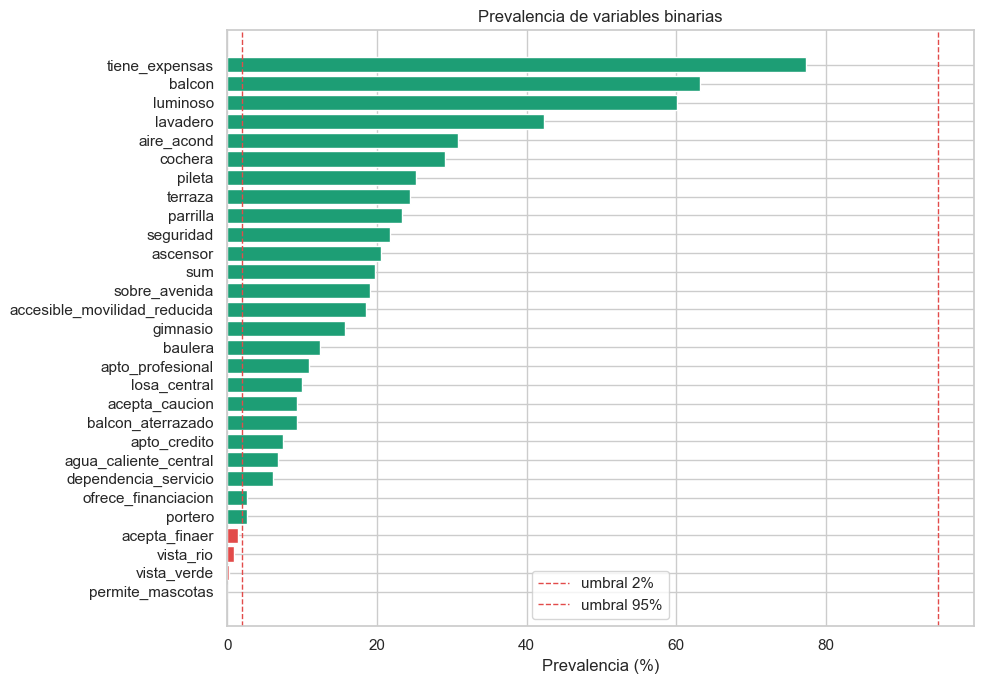


Variables a eliminar por baja variación: ['permite_mascotas', 'vista_verde', 'vista_rio', 'acepta_finaer']


In [306]:
cols_binarias = [
    'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
    'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida',
    'acepta_caucion', 'acepta_finaer', 'agua_caliente_central', 'apto_profesional',
    'ascensor', 'balcon', 'baulera', 'dependencia_servicio', 'gimnasio',
    'lavadero', 'ofrece_financiacion', 'parrilla', 'permite_mascotas',
    'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas',
    'vista_rio', 'vista_verde', 'sobre_avenida'
]
cols_binarias = [c for c in cols_binarias if c in df_final.columns]

prevalencia = df_final[cols_binarias].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#E24B4A' if v < 0.02 or v > 0.95 else '#1D9E75' for v in prevalencia]
ax.barh(prevalencia.index, prevalencia.values * 100, color=colores)
ax.axvline(2,  color='#E24B4A', linestyle='--', linewidth=1, label='umbral 2%')
ax.axvline(95, color='#E24B4A', linestyle='--', linewidth=1, label='umbral 95%')
ax.set_xlabel('Prevalencia (%)')
ax.set_title('Prevalencia de variables binarias')
ax.legend()
plt.tight_layout()
plt.show()

# Variables a eliminar por baja variación
eliminar_prevalencia = prevalencia[(prevalencia < 0.02) | (prevalencia > 0.95)].index.tolist()
print(f"\nVariables a eliminar por baja variación: {eliminar_prevalencia}")
df_final = df_final.drop(columns=eliminar_prevalencia)
cols_binarias = [c for c in cols_binarias if c not in eliminar_prevalencia]

Creamos una variable que cuenta la cantidad de amenities por propiedad.

In [307]:
df_final['amenities_count'] = df_final[cols_binarias].sum(axis=1)

print("Distribución de amenities_count:")
print(df_final['amenities_count'].describe())

Distribución de amenities_count:
count   51,996
mean         5
std          3
min          0
25%          3
50%          5
75%          7
max         18
Name: amenities_count, dtype: float64


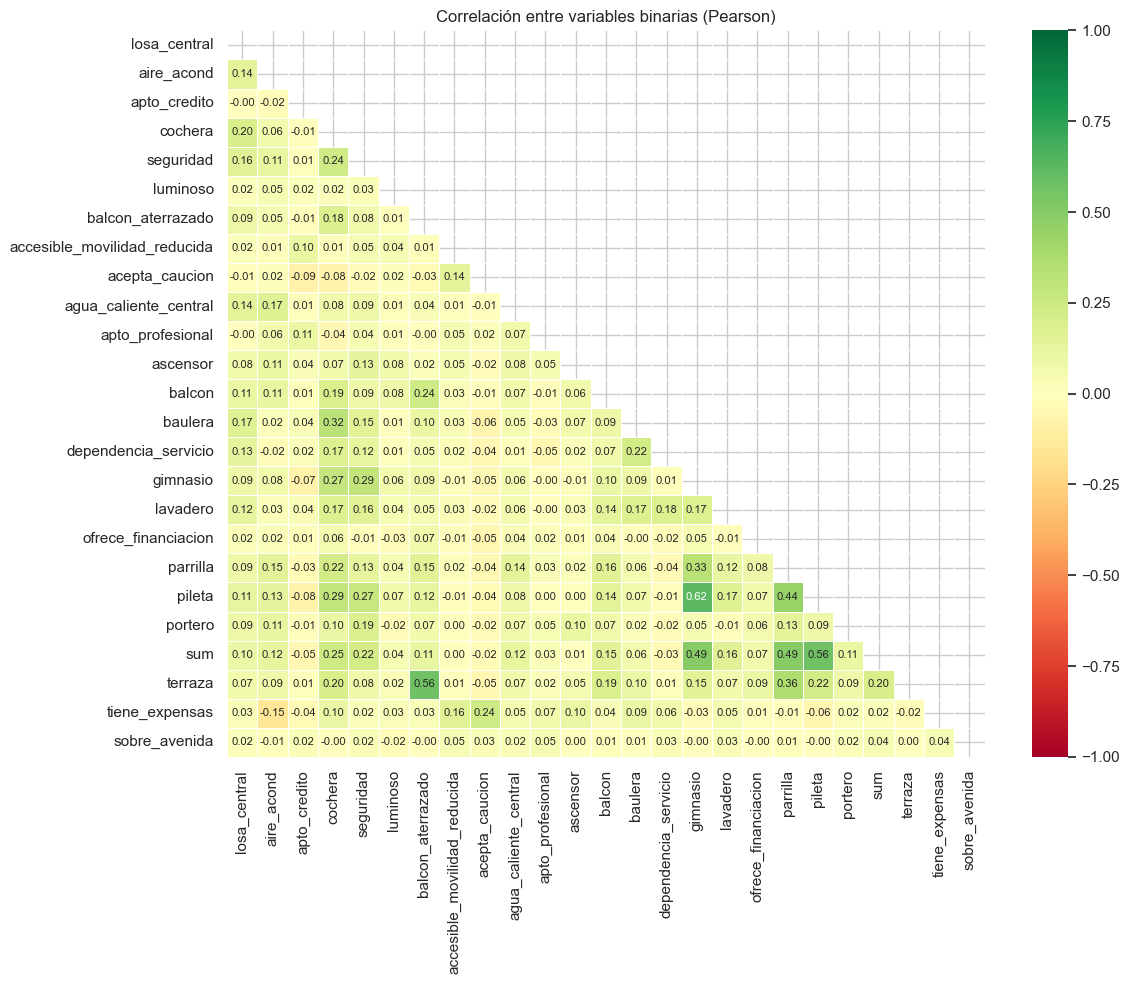


Pares con |r| > 0.85:
Empty DataFrame
Columns: [var_1, var_2, correlacion, correlacion_abs]
Index: []


In [308]:
corr_bin = df_final[cols_binarias].corr(method='pearson')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_bin, dtype=bool))
sns.heatmap(
    corr_bin, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlación entre variables binarias (Pearson)')
plt.tight_layout()
plt.show()

# Tabla de pares con |r| > 0.85
upper = corr_bin.where(np.triu(np.ones(corr_bin.shape), k=1).astype(bool))
pares = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var_1', 'level_1': 'var_2', 0: 'correlacion'})
    .assign(correlacion_abs=lambda x: x['correlacion'].abs())
    .sort_values('correlacion_abs', ascending=False)
)
print("\nPares con |r| > 0.85:")
print(pares[pares['correlacion_abs'] > 0.85].to_string(index=False))

No encontramos ninguna correlación fuerte entre las distintas variables binarias. La correlación más fuerte (0.62) está presente entre pileta y gimnasio. Tiene sentido que si un edificio presenta espacio para pileta, también cuente con un gimnasio (y vice-versa), pero la asociación no es tan fuerte para que sea representativo en la mayoría de los casos.

# 14. KPIs

Definimos los KPIs planteados en la entrega anterior. Los calculamos por barrio y unificamos la moneda a dólares para construir indicadores que engloben toda la base de datos.

In [309]:
from datetime import date
import requests

def obtener_dolar_oficial():
    hoy = date.today().strftime("%Y-%m-%d")

    try:
        url = f"https://estadisticascambiarias.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD?fecha={hoy}"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['results']['detalle'][0]['tipoCotizacion']
        print(f"✓ [BCRA oficial] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ BCRA oficial falló: {e}")

    try:
        url = "https://apis.datos.gob.ar/series/api/series/?ids=168.1_T_CAMBIOR_D_0_0_26&limit=1&sort=desc"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['data'][0][1]
        print(f"✓ [datos.gob.ar] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ datos.gob.ar falló: {e}")

    try:
        url = "https://dolarapi.com/v1/dolares/oficial"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['venta']
        print(f"✓ [dolarapi.com] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ dolarapi.com falló: {e}")

    print("\n⚠ No se pudo obtener el tipo de cambio de ninguna fuente.")
    print("  Ingresalo manualmente en la siguiente línea:")
    return None

TIPO_DE_CAMBIO_USD = obtener_dolar_oficial()

# 2. Convertimos precio y expensas a USD en una copia del DataFrame
df_usd = df_final.copy()
mask_ars = df_usd['moneda'] == 'ars'
df_usd.loc[mask_ars, 'precio']    = df_usd.loc[mask_ars, 'precio']    / TIPO_DE_CAMBIO_USD
df_usd.loc[mask_ars, 'expensas']  = df_usd.loc[mask_ars, 'expensas']  / TIPO_DE_CAMBIO_USD
df_usd['precio_por_m2'] = df_usd['precio'] / df_usd['m2_total']

# 3. DataFrames por tipo de operación (todo en USD)
ventas      = df_usd[df_usd['operacion'] == 'venta'].copy()
alquileres  = df_usd[df_usd['operacion'] == 'alquiler'].copy()
temporarios = df_usd[df_usd['operacion'] == 'alquiler_temporal'].copy()

# 4. Tabla resumen por barrio con la mediana de alquiler y venta (base de los KPIs de rentabilidad)
resumen_barrio = pd.DataFrame({
    'alquiler_mediano': alquileres.groupby('barrio_oficial')['precio'].median(),
    'venta_mediana':    ventas.groupby('barrio_oficial')['precio'].median(),
    'expensas_medianas': alquileres.groupby('barrio_oficial')['expensas'].median(),
}).dropna(subset=['alquiler_mediano', 'venta_mediana'])

# 5. Tabla resumen de alquiler temporario por barrio
segmento_por_barrio = {
    'Palermo': 'premium', 'Recoleta': 'premium',
    'Puerto Madero': 'premium', 'Belgrano': 'premium',
    'Villa Crespo': 'medio', 'Almagro': 'medio',
    'Caballito': 'medio', 'Nuñez': 'medio',
}
ocupacion_por_segmento = {'premium': 0.72, 'medio': 0.62, 'bajo': 0.48}

resumen_temp = pd.DataFrame({
    'tarifa_diaria_mediana': temporarios.groupby('barrio_oficial')['precio'].median(),
    'venta_mediana':         ventas.groupby('barrio_oficial')['precio'].median(),
    'expensas_medianas':     temporarios.groupby('barrio_oficial')['expensas'].median(),
}).dropna(subset=['tarifa_diaria_mediana', 'venta_mediana'])

resumen_temp['segmento'] = resumen_temp.index.map(
    lambda b: segmento_por_barrio.get(b, 'bajo')
)
resumen_temp['ocupacion'] = resumen_temp['segmento'].map(ocupacion_por_segmento)


✗ BCRA oficial falló: HTTPSConnectionPool(host='estadisticascambiarias.bcra.gob.ar', port=443): Max retries exceeded with url: /estadisticascambiarias/v1.0/Cotizaciones/USD?fecha=2026-05-13 (Caused by NameResolutionError("HTTPSConnection(host='estadisticascambiarias.bcra.gob.ar', port=443): Failed to resolve 'estadisticascambiarias.bcra.gob.ar' ([Errno 11001] getaddrinfo failed)"))
✓ [datos.gob.ar] Dólar oficial al 2026-05-13: $ 1,415.00 ARS/USD


Usamos las tasas de ocupación por segmento (premium, medio y básico) según AirDNA para el caso de alquiler temporario.

### KPI 1 - Rentabilidad Bruta Alquiler Largo Plazo


In [310]:
# Fórmula: (Alquiler Mensual × 12) / Precio Venta

kpi1 = resumen_barrio.copy()
kpi1['rentabilidad_bruta_pct'] = (
    (kpi1['alquiler_mediano'] * 12) / kpi1['venta_mediana'] * 100
).round(2)
kpi1 = kpi1.sort_values('rentabilidad_bruta_pct', ascending=False)

print("=== KPI 1: Rentabilidad Bruta Largo Plazo (%) — USD ===")
print(kpi1[['alquiler_mediano', 'venta_mediana', 'rentabilidad_bruta_pct']])


=== KPI 1: Rentabilidad Bruta Largo Plazo (%) — USD ===
                   alquiler_mediano  venta_mediana  rentabilidad_bruta_pct
barrio_oficial                                                            
Villa Soldati                   548         47,000                      14
Villa Lugano                    459         60,000                       9
Nueva Pompeya                   495         75,000                       8
Constitucion                    459         75,000                       7
Parque Avellaneda               459         78,000                       7
Monserrat                       500         87,000                       7
La Boca                         417         73,640                       7
Villa Real                      530         95,000                       7
Parque Patricios                459         83,000                       7
San Telmo                       530         97,500                       7
Versalles                       565        1

### KPI 2 - Recupero de Inversión Largo Plazo


In [311]:
# Fórmula: Precio Venta / (Alquiler Mensual × 12)
# Resultado: años necesarios para recuperar la inversión
# Es el inverso del KPI 1, por lo que reutilizamos el mismo DataFrame.

kpi2 = kpi1.copy()
kpi2['años_recupero'] = (100 / kpi2['rentabilidad_bruta_pct']).round(1)
kpi2 = kpi2.sort_values('años_recupero', ascending=True)

print("=== KPI 2: Recupero de Inversión (años) — USD ===")
print(kpi2[['alquiler_mediano', 'venta_mediana', 'años_recupero']])


=== KPI 2: Recupero de Inversión (años) — USD ===
                   alquiler_mediano  venta_mediana  años_recupero
barrio_oficial                                                   
Villa Soldati                   548         47,000              7
Villa Lugano                    459         60,000             11
Nueva Pompeya                   495         75,000             13
Constitucion                    459         75,000             14
Parque Avellaneda               459         78,000             14
Monserrat                       500         87,000             14
La Boca                         417         73,640             15
Villa Real                      530         95,000             15
Parque Patricios                459         83,000             15
San Telmo                       530         97,500             15
Versalles                       565        107,000             16
San Nicolas                     466         88,800             16
Chacarita                 

### KPI 3 - Precio por metro cuadrado

In [312]:
# Fórmula: Precio / m² (columna precio_por_m2 recalculada en df_usd)

kpi3 = (
    df_usd[df_usd['precio_por_m2'].notna()]
    .groupby(['barrio_oficial', 'operacion'])['precio_por_m2']
    .agg(
        propiedades='count',
        precio_m2_mediano='median',
        precio_m2_promedio='mean'
    )
    .round(0)
    .sort_values(['operacion', 'precio_m2_mediano'], ascending=[True, False])
)

print("=== KPI 3: Precio por m² — USD ===")
print(kpi3)


=== KPI 3: Precio por m² — USD ===
                          propiedades  precio_m2_mediano  precio_m2_promedio
barrio_oficial operacion                                                    
Puerto Madero  alquiler           940                 26                  28
Palermo        alquiler          3434                 16                  17
Nuñez          alquiler           578                 15                  17
Belgrano       alquiler          1508                 14                  16
Colegiales     alquiler           267                 14                  17
...                               ...                ...                 ...
La Boca        venta              153              1,393               1,543
Constitucion   venta              162              1,391               1,450
Nueva Pompeya  venta               41              1,333               1,327
Villa Lugano   venta              199              1,040               1,323
Villa Soldati  venta               18    

### KPI 4 — Rentabilidad Neta Largo Plazo 


In [313]:
# Rentabilidad Neta Largo Plazo: ingreso anual menos expensas del propietario, por barrio.
# Si tiene_expensas == 0, el propietario paga → se descuentan del retorno.
# En alquiler largo plazo la mayoría tiene tiene_expensas == 1, por lo que el resultado
# queda muy similar a la rentabilidad bruta, excepto en los casos donde las paga el propietario.
alquileres_neto = alquileres.copy()
alquileres_neto['ingreso_anual'] = alquileres_neto['precio'] * 12
alquileres_neto['costo_propietario'] = np.where(
    alquileres_neto['tiene_expensas'] == 0,
    alquileres_neto['expensas'] * 12, 0
)
alquileres_neto['retorno_neto'] = alquileres_neto['ingreso_anual'] - alquileres_neto['costo_propietario']

kpi4 = alquileres_neto.groupby('barrio_oficial').agg(
    retorno_neto_mediano=('retorno_neto', 'median'),
    propiedades=('retorno_neto', 'count')
)
kpi4 = kpi4.join(resumen_barrio[['venta_mediana']])
kpi4['segmento'] = kpi4.index.map(lambda b: segmento_por_barrio.get(b, 'bajo'))
kpi4['rent_neta_lp_pct'] = (kpi4['retorno_neto_mediano'] / kpi4['venta_mediana'] * 100).round(0).astype('Int64')
kpi4 = kpi4.dropna(subset=['rent_neta_lp_pct']).sort_values('rent_neta_lp_pct', ascending=False)

print("=== KPI 4: Rentabilidad Neta Largo Plazo — USD ===")
print(kpi4[['segmento', 'rent_neta_lp_pct', 'propiedades']].to_string())


=== KPI 4: Rentabilidad Neta Largo Plazo — USD ===
                  segmento  rent_neta_lp_pct  propiedades
barrio_oficial                                           
Villa Soldati         bajo                14            2
Villa Lugano          bajo                 9           77
La Boca               bajo                 7           70
Constitucion          bajo                 7           90
Nueva Pompeya         bajo                 7           17
Monserrat             bajo                 7          329
San Telmo             bajo                 7          349
Parque Avellaneda     bajo                 7           40
Parque Patricios      bajo                 7           79
San Nicolas           bajo                 6          694
Balvanera             bajo                 6          566
Boedo                 bajo                 6          143
La Paternal           bajo                 6           85
Floresta              bajo                 6          134
Chacarita            

Para entender verdaderamente cuál es el barrio con mayor renta neta, hay que considerar que no tenemos valores de expensas de todos los barrios. 

### KPI 5 — Precio/m² relativo por barrio


Realizamos el precio del metro cuadrado relativo solo con las propiedades en dolares, debido a que las propiedades en venta en pesos son muy pocas (40)

In [314]:
# Fórmula: Precio/m² de la propiedad / Mediana Precio/m² de su barrio

df_ventas_m2 = ventas[ventas['precio_por_m2'].notna() & (ventas['precio_por_m2'] > 0)].copy()

mediana_por_barrio = df_ventas_m2.groupby('barrio_oficial')['precio_por_m2'].median()
df_ventas_m2['precio_m2_mediano_barrio'] = df_ventas_m2['barrio_oficial'].map(mediana_por_barrio)
df_ventas_m2['precio_m2_relativo'] = (
    df_ventas_m2['precio_por_m2'] / df_ventas_m2['precio_m2_mediano_barrio']
).round(3)

kpi5_barrios = (
    mediana_por_barrio.rename('precio_m2_mediano').reset_index()
    .merge(
        df_ventas_m2.groupby('barrio_oficial').size().rename('propiedades').reset_index(),
        on='barrio_oficial'
    )
    .sort_values('precio_m2_mediano', ascending=False)
    .set_index('barrio_oficial')
)

oportunidades = df_ventas_m2[
    df_ventas_m2['precio_m2_relativo'] < 1
][['barrio_oficial', 'precio', 'm2_total', 'precio_por_m2', 'precio_m2_mediano_barrio', 'precio_m2_relativo']]\
.sort_values('precio_m2_relativo')

print("=== KPI 5: Mediana Precio/m² por Barrio — Ventas USD ===")
print(kpi5_barrios)
print(f"\n=== Propiedades con precio_m2_relativo < 1 (más baratas que su barrio): {len(oportunidades):,} ===")
print(oportunidades.head(20))


=== KPI 5: Mediana Precio/m² por Barrio — Ventas USD ===
                   precio_m2_mediano  propiedades
barrio_oficial                                   
Puerto Madero                  5,667          575
Nuñez                          3,431         1179
Palermo                        3,241         4268
Belgrano                       3,112         2813
Villa Urquiza                  2,838         1289
Colegiales                     2,805          463
Coghlan                        2,730          279
Saavedra                       2,683          417
Villa Ortuzar                  2,667          147
Recoleta                       2,635         2719
Chacarita                      2,634          175
Villa Devoto                   2,602          592
Villa Crespo                   2,509          936
Parque Chas                    2,432           87
Villa Luro                     2,414          488
Caballito                      2,388         2221
Retiro                         2,388       

### KPI 6 — Rentabilidad Bruta Temporario


In [315]:
# Rentabilidad Bruta Temporario: (tarifa mensual × 12) / precio de venta
kpi6 = resumen_temp.copy()
kpi6['rent_bruta_temp_pct'] = (kpi6['tarifa_diaria_mediana'] * 12 / kpi6['venta_mediana'] * 100).round(2)
kpi6 = kpi6.sort_values('rent_bruta_temp_pct', ascending=False)

print("=== KPI 6: Rentabilidad Bruta Temporario — USD ===")
print(kpi6[['segmento', 'rent_bruta_temp_pct']].to_string())


=== KPI 6: Rentabilidad Bruta Temporario — USD ===
                  segmento  rent_bruta_temp_pct
barrio_oficial                                 
Parque Avellaneda     bajo                   15
Nueva Pompeya         bajo                   15
Villa Luro            bajo                   13
La Boca               bajo                   10
Chacarita             bajo                    9
Constitucion          bajo                    9
Monserrat             bajo                    8
Boedo                 bajo                    8
San Nicolas           bajo                    8
San Telmo             bajo                    8
Flores                bajo                    8
Coghlan               bajo                    8
Balvanera             bajo                    8
Villa Pueyrredon      bajo                    8
Agronomia             bajo                    7
Parque Patricios      bajo                    7
San Cristobal         bajo                    7
Colegiales            bajo           

### KPI 7 — Índice bruto modalidad óptima

In [316]:
kpi7 = kpi6[['segmento', 'rent_bruta_temp_pct']].join(
    kpi1[['rentabilidad_bruta_pct']].rename(columns={'rentabilidad_bruta_pct': 'rent_bruta_lp_pct'}),
    how='inner')
# Guard: evitar división por cero
kpi7 = kpi7[kpi7['rent_bruta_lp_pct'].notna() & (kpi7['rent_bruta_lp_pct'] != 0)].copy()
kpi7['indice_bruto'] = (kpi7['rent_bruta_temp_pct'] / kpi7['rent_bruta_lp_pct']).round(2)
kpi7['modalidad_optima'] = kpi7.apply(
    lambda r: 'Temporario' if r['rent_bruta_temp_pct'] > r['rent_bruta_lp_pct'] else 'Largo plazo', axis=1)
kpi7 = kpi7.sort_values('indice_bruto', ascending=False)
print("=== KPI 7: Índice Bruto Modalidad Óptima — USD ===")
print(kpi7[['segmento', 'rent_bruta_temp_pct', 'rent_bruta_lp_pct', 'indice_bruto', 'modalidad_optima']].head(20).to_string())


=== KPI 7: Índice Bruto Modalidad Óptima — USD ===
                  segmento  rent_bruta_temp_pct  rent_bruta_lp_pct  indice_bruto modalidad_optima
barrio_oficial                                                                                   
Villa Luro            bajo                   13                  5             3       Temporario
Parque Avellaneda     bajo                   15                  7             2       Temporario
Nueva Pompeya         bajo                   15                  8             2       Temporario
Villa Ortuzar         bajo                    6                  4             2       Temporario
Chacarita             bajo                    9                  6             2       Temporario
Coghlan               bajo                    8                  5             2       Temporario
Colegiales            bajo                    7                  5             1       Temporario
Flores                bajo                    8                  5 

### KPI 8 — Rentabilidad Neta Temporario

In [317]:
# Rentabilidad Neta Temporario: ingreso anual (precio mensual × 12) menos expensas del propietario.
# En alquiler temporal la mayoría tiene tiene_expensas == 0 (propietario paga por convencion),
# por lo que las expensas sí se descuentan en casi todos los casos.
temporarios_neto = temporarios.copy()

# En df_usd las expensas se convierten a USD solo para propiedades con moneda=='ars'.
# Los temporarios listados en USD tienen el precio ya en USD pero las expensas aún en ARS.
# Las convertimos aquí para que ambas columnas sean comparables.
mask_usd_price = temporarios_neto['moneda'] == 'usd'
if TIPO_DE_CAMBIO_USD and mask_usd_price.any():
    temporarios_neto.loc[mask_usd_price, 'expensas'] = (
        temporarios_neto.loc[mask_usd_price, 'expensas'] / TIPO_DE_CAMBIO_USD
    )

temporarios_neto['ingreso_anual'] = temporarios_neto['precio'] * 12
temporarios_neto['costo_propietario'] = np.where(
    temporarios_neto['tiene_expensas'] == 0,
    temporarios_neto['expensas'] * 12, 0
)
temporarios_neto['retorno_neto'] = temporarios_neto['ingreso_anual'] - temporarios_neto['costo_propietario']

kpi8 = temporarios_neto.groupby('barrio_oficial').agg(
    ingreso_anual_mediano=('ingreso_anual', 'median'),
    costo_propietario_mediano=('costo_propietario', 'median'),
    retorno_neto_mediano=('retorno_neto', 'median'),
    propiedades=('retorno_neto', 'count')
)
kpi8 = kpi8.join(resumen_temp[['venta_mediana', 'segmento']])
kpi8['rent_bruta_temp_pct'] = (kpi8['ingreso_anual_mediano'] / kpi8['venta_mediana'] * 100).round(0).astype('Int64')
kpi8['costo_expensas_pct'] = (kpi8['costo_propietario_mediano'] / kpi8['venta_mediana'] * 100).round(0).astype('Int64')
kpi8['rent_neta_temp_pct'] = (kpi8['retorno_neto_mediano'] / kpi8['venta_mediana'] * 100).round(0).astype('Int64')
kpi8 = kpi8.dropna(subset=['rent_neta_temp_pct']).sort_values('rent_neta_temp_pct', ascending=False)

print("=== KPI 8: Rentabilidad Neta Temporario — USD ===")
print(kpi8[['segmento', 'rent_bruta_temp_pct', 'costo_expensas_pct', 'rent_neta_temp_pct']].head(20).to_string())


=== KPI 8: Rentabilidad Neta Temporario — USD ===
                  segmento  rent_bruta_temp_pct  costo_expensas_pct  rent_neta_temp_pct
barrio_oficial                                                                         
Nueva Pompeya         bajo                   15                   2                  13
Parque Avellaneda     bajo                   15                   4                  12
Villa Luro            bajo                   13                   1                  12
La Boca               bajo                   10                   1                   9
Chacarita             bajo                    9                   1                   8
Boedo                 bajo                    8                   1                   7
San Telmo             bajo                    8                   1                   7
Flores                bajo                    8                   1                   7
Monserrat             bajo                    8                   2   

### KPI 9: Índice Neto Modalidad Óptima 


In [318]:
kpi9 = kpi8[['segmento', 'rent_neta_temp_pct']].join(
    kpi4[['rent_neta_lp_pct']], how='inner')
kpi9 = kpi9[kpi9['rent_neta_lp_pct'].notna() & (kpi9['rent_neta_lp_pct'] != 0)].copy()
kpi9['indice_neto'] = (kpi9['rent_neta_temp_pct'] / kpi9['rent_neta_lp_pct']).round(2)
kpi9['modalidad_optima'] = kpi9.apply(
    lambda r: 'Temporario' if r['rent_neta_temp_pct'] > r['rent_neta_lp_pct'] else 'Largo plazo', axis=1)
kpi9 = kpi9.sort_values('indice_neto', ascending=False)
print("=== KPI 9: Índice Neto Modalidad Óptima — USD ===")
print(kpi9[['segmento', 'rent_neta_temp_pct', 'rent_neta_lp_pct', 'indice_neto', 'modalidad_optima']].head(20).to_string())


=== KPI 9: Índice Neto Modalidad Óptima — USD ===
                  segmento  rent_neta_temp_pct  rent_neta_lp_pct  indice_neto modalidad_optima
barrio_oficial                                                                                
Villa Luro            bajo                  12                 5            2       Temporario
Nueva Pompeya         bajo                  13                 7            2       Temporario
Parque Avellaneda     bajo                  12                 7            2       Temporario
Villa Del Parque      bajo                   6                 4            2       Temporario
Flores                bajo                   7                 5            1       Temporario
Chacarita             bajo                   8                 6            1       Temporario
La Boca               bajo                   9                 7            1       Temporario
Villa Ortuzar         bajo                   5                 4            1       Temporario


### Algunas conclusiones a partir de los KPI:

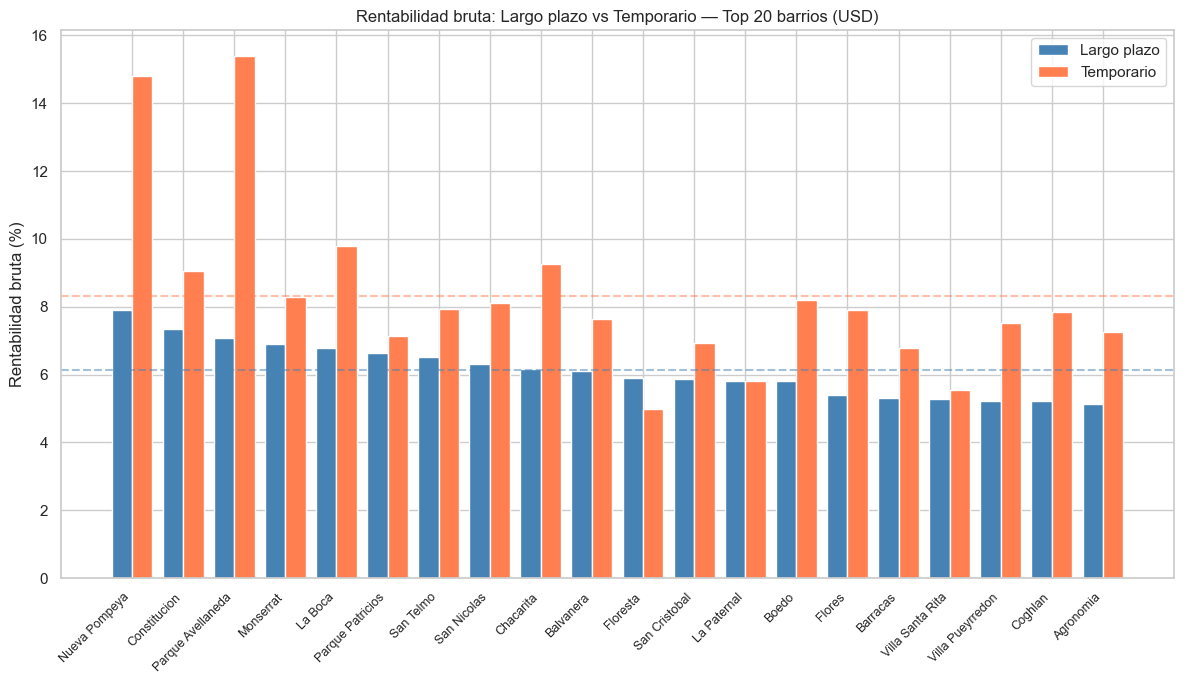

In [319]:
# KPI 1 vs KPI 6: Rentabilidad Bruta LP vs Temporario por barrio
kpi_comparado = kpi1[['rentabilidad_bruta_pct']].join(
    kpi6[['rent_bruta_temp_pct']], how='inner'
).dropna().sort_values('rentabilidad_bruta_pct', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(kpi_comparado))
width = 0.4
ax.bar([i - width/2 for i in x], kpi_comparado['rentabilidad_bruta_pct'],
       width=width, label='Largo plazo', color='steelblue')
ax.bar([i + width/2 for i in x], kpi_comparado['rent_bruta_temp_pct'],
       width=width, label='Temporario', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(kpi_comparado.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Rentabilidad bruta (%)')
ax.set_title('Rentabilidad bruta: Largo plazo vs Temporario — Top 20 barrios (USD)', fontsize=12)
ax.legend()
ax.axhline(y=kpi_comparado['rentabilidad_bruta_pct'].mean(),
           color='steelblue', linestyle='--', alpha=0.5, label='Media LP')
ax.axhline(y=kpi_comparado['rent_bruta_temp_pct'].mean(),
           color='coral', linestyle='--', alpha=0.5, label='Media Temp')
plt.tight_layout()
plt.show()

Vemos una clara diferencia entre la rentabilidad bruta a largo vs a corto plazo: el temporario se ve bastante más rentable, destacandose ciertos barrios como Parque Avellaneda y Nueva Pompeya.

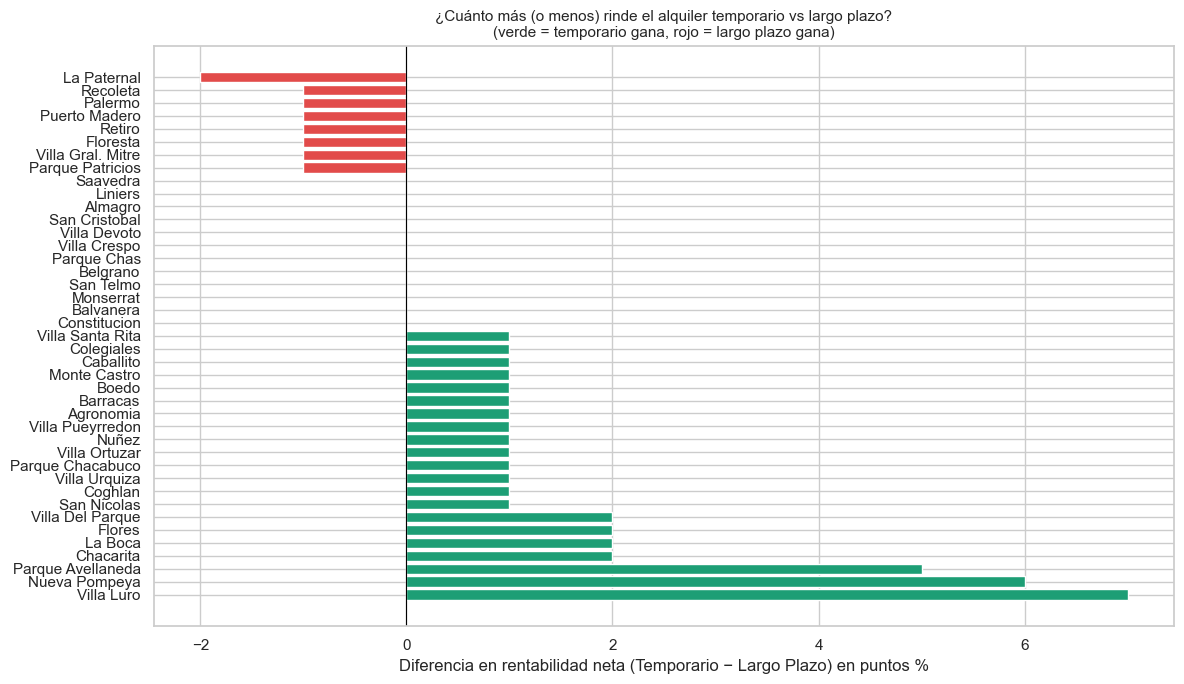

In [320]:
# KPI 4 vs KPI 8: Rentabilidad Neta LP vs Temporario
kpi_neto = kpi4[['rent_neta_lp_pct']].join(
    kpi8[['rent_neta_temp_pct']], how='inner'
).dropna()
kpi_neto['diferencia'] = kpi_neto['rent_neta_temp_pct'] - kpi_neto['rent_neta_lp_pct']
kpi_neto = kpi_neto.sort_values('diferencia', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colores = ['#1D9E75' if d > 0 else '#E24B4A' for d in kpi_neto['diferencia']]
ax.barh(kpi_neto.index, kpi_neto['diferencia'], color=colores, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Diferencia en rentabilidad neta (Temporario − Largo Plazo) en puntos %')
ax.set_title('¿Cuánto más (o menos) rinde el alquiler temporario vs largo plazo?\n(verde = temporario gana, rojo = largo plazo gana)', fontsize=11)
plt.tight_layout()
plt.show()

Ahora, podemos ver la diferencia neta: en este caso dependiendo el barrio, cambia la modalidad más beneficiosa.

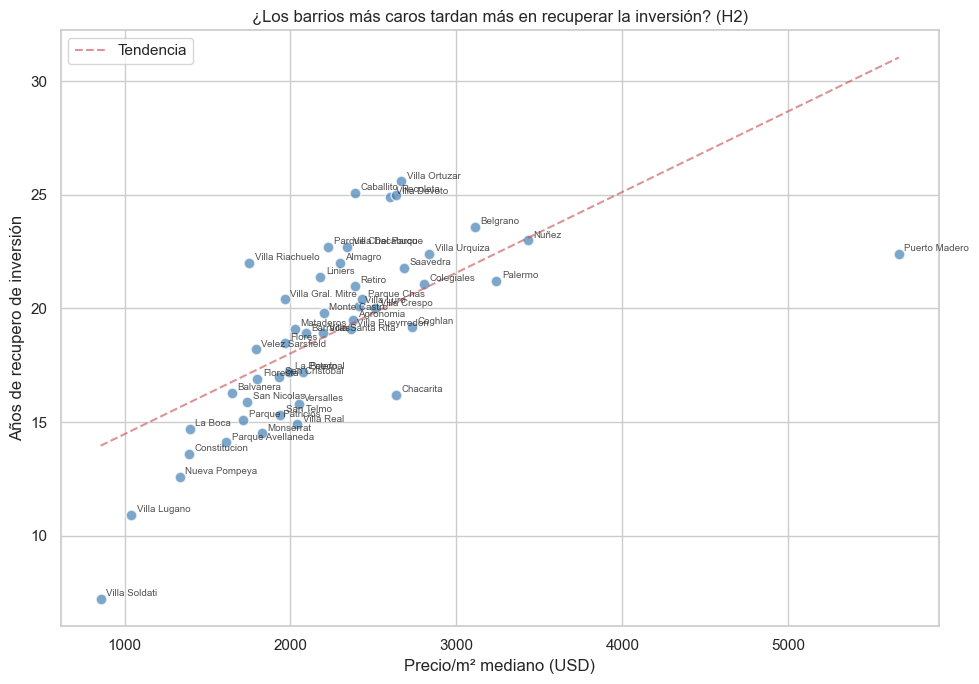

In [321]:
# KPI 2 vs KPI 5: Años de recupero vs precio/m² por barrio
kpi_h2 = kpi2[['años_recupero']].join(
    kpi5_barrios[['precio_m2_mediano']], how='inner'
).dropna()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(kpi_h2['precio_m2_mediano'], kpi_h2['años_recupero'],
           alpha=0.7, s=60, color='steelblue', edgecolors='white')

for barrio, row in kpi_h2.iterrows():
    ax.annotate(barrio, (row['precio_m2_mediano'], row['años_recupero']),
                fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')

# Línea de tendencia
z = np.polyfit(kpi_h2['precio_m2_mediano'], kpi_h2['años_recupero'], 1)
p = np.poly1d(z)
x_line = np.linspace(kpi_h2['precio_m2_mediano'].min(), kpi_h2['precio_m2_mediano'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.6, linewidth=1.5, label='Tendencia')

ax.set_xlabel('Precio/m² mediano (USD)')
ax.set_ylabel('Años de recupero de inversión')
ax.set_title('¿Los barrios más caros tardan más en recuperar la inversión? (H2)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

Finalmente, podemos ver qué tanto se tarda en recuperar la inversión, segun el barrio. Muchos de los barrios, siguen la linea de tendencia. Pero nuevamente, Puero Madero se destaca por su rápido nivel de recupero, considerando su valor.

# Primeras Conclusiones

El análisis exploratorio permitió identificar patrones relevantes dentro del mercado inmobiliario analizado, evidenciando importantes diferencias territoriales, económicas y estructurales entre segmentos de propiedades.

Los resultados sugieren que variables como ubicación, superficie, amenities y modalidad de alquiler poseen una influencia significativa sobre la valuación y rentabilidad de los inmuebles.

Asimismo, la aplicación de técnicas estadísticas permitió validar ciertas hipótesis iniciales y descartar otras, fortaleciendo la confiabilidad del análisis realizado.

Esta etapa constituye la base para futuras instancias de modelado avanzado, segmentación y análisis espacial contempladas en las próximas entregas del proyecto.